<h1 style = "text-align : center;">Exploratory Data Analysis</h1>

This section will explore the WHO Life Expectancy dataset to understand its structure, data types, missing values, distributions, potential outliers, and relationships between features and the target variable.

The goal is to build a clear understanding of the data before making any preprocessing, feature engineering, or modelling decisions.

--- 
## Data import 

In [2]:
import pandas as pd
import numpy as np
pd.set_option("display.float_format", "{:.2f}".format)

In [3]:
df = pd.read_csv("../Data/Data.csv")

---
## Data inspection

In [4]:
df.shape

(2938, 22)

In [5]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.00,263.00,62,0.01,71.28,65.00,1154,...,6.00,8.16,65.00,0.10,584.26,33736494.00,17.20,17.30,0.48,10.10
1,Afghanistan,2014,Developing,59.90,271.00,64,0.01,73.52,62.00,492,...,58.00,8.18,62.00,0.10,612.70,327582.00,17.50,17.50,0.48,10.00
2,Afghanistan,2013,Developing,59.90,268.00,66,0.01,73.22,64.00,430,...,62.00,8.13,64.00,0.10,631.74,31731688.00,17.70,17.70,0.47,9.90
3,Afghanistan,2012,Developing,59.50,272.00,69,0.01,78.18,67.00,2787,...,67.00,8.52,67.00,0.10,669.96,3696958.00,17.90,18.00,0.46,9.80
4,Afghanistan,2011,Developing,59.20,275.00,71,0.01,7.10,68.00,3013,...,68.00,7.87,68.00,0.10,63.54,2978599.00,18.20,18.20,0.45,9.50


In [6]:
df.tail()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2933,Zimbabwe,2004,Developing,44.30,723.00,27,4.36,0.00,68.00,31,...,67.00,7.13,65.00,33.60,454.37,12777511.00,9.40,9.40,0.41,9.20
2934,Zimbabwe,2003,Developing,44.50,715.00,26,4.06,0.00,7.00,998,...,7.00,6.52,68.00,36.70,453.35,12633897.00,9.80,9.90,0.42,9.50
2935,Zimbabwe,2002,Developing,44.80,73.00,25,4.43,0.00,73.00,304,...,73.00,6.53,71.00,39.80,57.35,125525.00,1.20,1.30,0.43,10.00
2936,Zimbabwe,2001,Developing,45.30,686.00,25,1.72,0.00,76.00,529,...,76.00,6.16,75.00,42.10,548.59,12366165.00,1.60,1.70,0.43,9.80
2937,Zimbabwe,2000,Developing,46.00,665.00,24,1.68,0.00,79.00,1483,...,78.00,7.10,78.00,43.50,547.36,12222251.00,11.00,11.20,0.43,9.80


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2938.00,2007.52,4.61,2000.00,2004.00,2008.00,2012.00,2015.00
Life expectancy,2928.00,69.22,9.52,36.30,63.10,72.10,75.70,89.00
Adult Mortality,2928.00,164.80,124.29,1.00,74.00,144.00,228.00,723.00
infant deaths,2938.00,30.30,117.93,0.00,0.00,3.00,22.00,1800.00
Alcohol,2744.00,4.60,4.05,0.01,0.88,3.75,7.70,17.87
percentage expenditure,2938.00,738.25,1987.91,0.00,4.69,64.91,441.53,19479.91
Hepatitis B,2385.00,80.94,25.07,1.00,77.00,92.00,97.00,99.00
Measles,2938.00,2419.59,11467.27,0.00,0.00,17.00,360.25,212183.00
BMI,2904.00,38.32,20.04,1.00,19.30,43.50,56.20,87.30
under-five deaths,2938.00,42.04,160.45,0.00,0.00,4.00,28.00,2500.00


In [9]:
df.nunique()

Country                             193
Year                                 16
Status                                2
Life expectancy                     362
Adult Mortality                     425
infant deaths                       209
Alcohol                            1076
percentage expenditure             2328
Hepatitis B                          87
Measles                             958
 BMI                                608
under-five deaths                   252
Polio                                73
Total expenditure                   818
Diphtheria                           81
 HIV/AIDS                           200
GDP                                2490
Population                         2278
 thinness  1-19 years               200
 thinness 5-9 years                 207
Income composition of resources     625
Schooling                           173
dtype: int64

In [10]:
cat_col = ['Year', 'Status', 'Country']
for column in cat_col:
    print("*******************")
    print(df[column].value_counts())
    print("*******************")

*******************
Year
2013    193
2015    183
2014    183
2012    183
2011    183
2010    183
2009    183
2008    183
2007    183
2006    183
2005    183
2004    183
2003    183
2002    183
2001    183
2000    183
Name: count, dtype: int64
*******************
*******************
Status
Developing    2426
Developed      512
Name: count, dtype: int64
*******************
*******************
Country
Afghanistan              16
Albania                  16
Algeria                  16
Angola                   16
Antigua and Barbuda      16
                         ..
Niue                      1
Palau                     1
Saint Kitts and Nevis     1
San Marino                1
Tuvalu                    1
Name: count, Length: 193, dtype: int64
*******************


In [11]:
country_counts = df['Country'].value_counts()
print(country_counts[country_counts < 16])
print("**********************************")
print(country_counts[country_counts == 16])

Country
Cook Islands             1
Dominica                 1
Marshall Islands         1
Monaco                   1
Nauru                    1
Niue                     1
Palau                    1
Saint Kitts and Nevis    1
San Marino               1
Tuvalu                   1
Name: count, dtype: int64
**********************************
Country
Afghanistan                           16
Albania                               16
Algeria                               16
Angola                                16
Antigua and Barbuda                   16
                                      ..
Venezuela (Bolivarian Republic of)    16
Viet Nam                              16
Yemen                                 16
Zambia                                16
Zimbabwe                              16
Name: count, Length: 183, dtype: int64


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.duplicated(subset=["Country", "Year"]).sum()

np.int64(0)

In [14]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [15]:
# Check missing-value percentage in columns with known nulls
df.isnull().mean()*100

Country                            0.00
Year                               0.00
Status                             0.00
Life expectancy                    0.34
Adult Mortality                    0.34
infant deaths                      0.00
Alcohol                            6.60
percentage expenditure             0.00
Hepatitis B                       18.82
Measles                            0.00
 BMI                               1.16
under-five deaths                  0.00
Polio                              0.65
Total expenditure                  7.69
Diphtheria                         0.65
 HIV/AIDS                          0.00
GDP                               15.25
Population                        22.19
 thinness  1-19 years              1.16
 thinness 5-9 years                1.16
Income composition of resources    5.68
Schooling                          5.55
dtype: float64

### Initial EDA Summary

The dataset contains **2,938 observations and 22 columns**, with 20 numerical features and two string-based features: `Country` and `Status`. It covers **193 countries across 16 years**.

No exact duplicate rows or duplicate `Country-Year` combinations were found. Most countries have observations for all 16 years, while 10 countries contain only a single observation.

Several columns contain missing values, with the highest proportions found in `Population` (~22%), `Hepatitis B` (~19%), and `GDP` (~15%). Other features contain smaller amounts of missing data. The target, `Life expectancy`, contains only 10 missing observations.

The descriptive statistics also indicate several potentially extreme values and strongly varying feature ranges. These will be investigated further during visual EDA rather than being treated as errors at this stage.

Overall, the dataset appears suitable for further analysis, with missing values, country-year structure, and potential outliers requiring closer investigation.

---
### Column Name Cleaning

Leading or trailing whitespace in column names can cause errors when selecting features or creating visualizations. As a basic data-cleaning step, whitespace will be removed from all column names to ensure consistent and reliable column access throughout the project.

In [16]:
for column in df.columns:
    print(repr(column))

'Country'
'Year'
'Status'
'Life expectancy '
'Adult Mortality'
'infant deaths'
'Alcohol'
'percentage expenditure'
'Hepatitis B'
'Measles '
' BMI '
'under-five deaths '
'Polio'
'Total expenditure'
'Diphtheria '
' HIV/AIDS'
'GDP'
'Population'
' thinness  1-19 years'
' thinness 5-9 years'
'Income composition of resources'
'Schooling'


In [17]:
df.columns = df.columns.str.strip()

---
## Visual Exploratory Data Analysis

This section will use visualizations to better understand the distribution, spread, relationships, and patterns within the dataset. The focus will be on creating plots that provide useful information for later preprocessing, feature engineering, and modelling decisions.

### Target Variable Analysis — Life Expectancy

The target variable, `Life expectancy`, will first be examined using a histogram and box plot. These visualizations will help assess its overall distribution, spread, skewness, and any potential outliers before analysing how the predictor variables relate to it.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

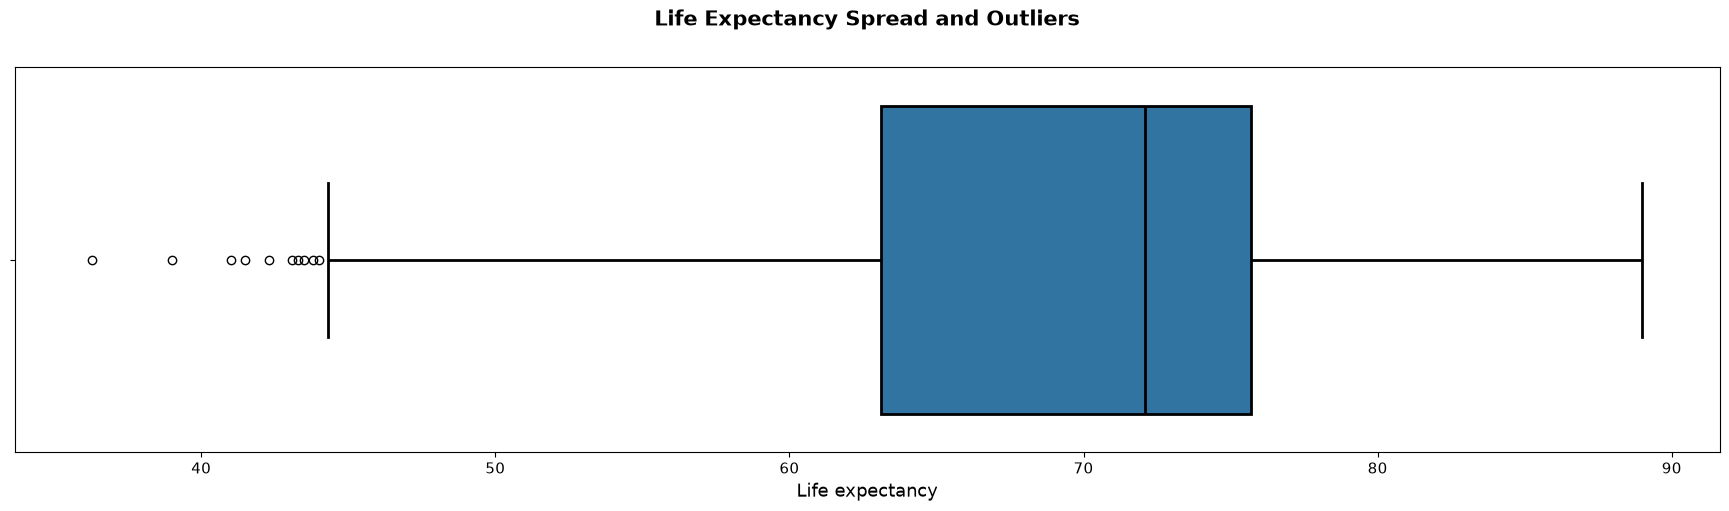

In [19]:
plt.figure(figsize=(22,5))
sns.boxplot(data=df, x='Life expectancy', linewidth=2, linecolor='black')
plt.title("Life Expectancy Spread and Outliers", fontsize=15, fontweight='bold', pad=30)
plt.tick_params(axis='x', labelsize=11, color='black')
plt.xlabel('Life expectancy', fontsize=13)
plt.show()

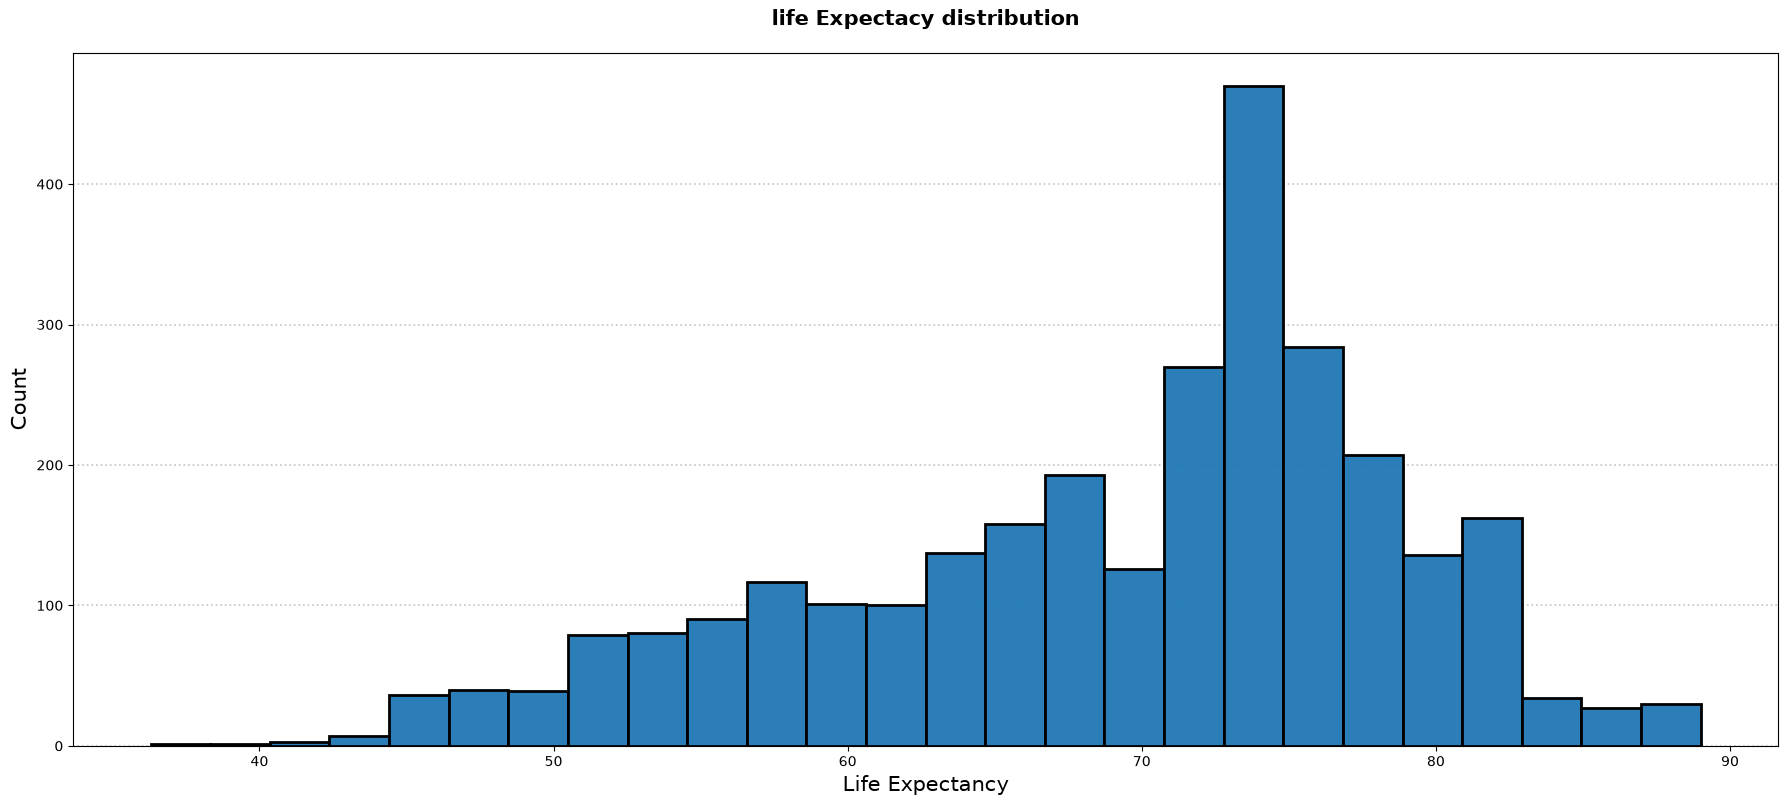

In [44]:
plt.figure(figsize=(22,9))
sns.histplot(data=df, x='Life expectancy', binwidth=2, linewidth=2, alpha=0.95)
plt.title('life Expectacy distribution', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Life Expectancy', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.rcParams['axes.axisbelow']=True
plt.grid(True, axis='y', linestyle=':', linewidth=1.25, alpha=0.7)
plt.show()

### Target Variable Evaluation

`Life expectancy` is concentrated mostly between the mid-60s and mid-70s, with a median around the low-70s. The lower whisker extends to roughly 44–45 years, while a few observations fall even lower and appear as outliers. The upper range reaches close to 89 years without obvious upper-end outliers.

The histogram also shows a mild left-skew, with most observations concentrated at higher life expectancy values and a smaller number of low-life-expectancy cases forming the left tail.

---
### Numerical Feature Analysis

Each numerical predictor will be examined using a histogram, box plot, and scatter plot against `Life expectancy`. This will help assess feature distributions, potential outliers, and relationships with the target variable in a consistent way across the dataset.

In [49]:
numerical_columns = df.select_dtypes(include="number").columns.to_list()
numerical_columns.remove('Life expectancy')
numerical_columns.remove('Year')

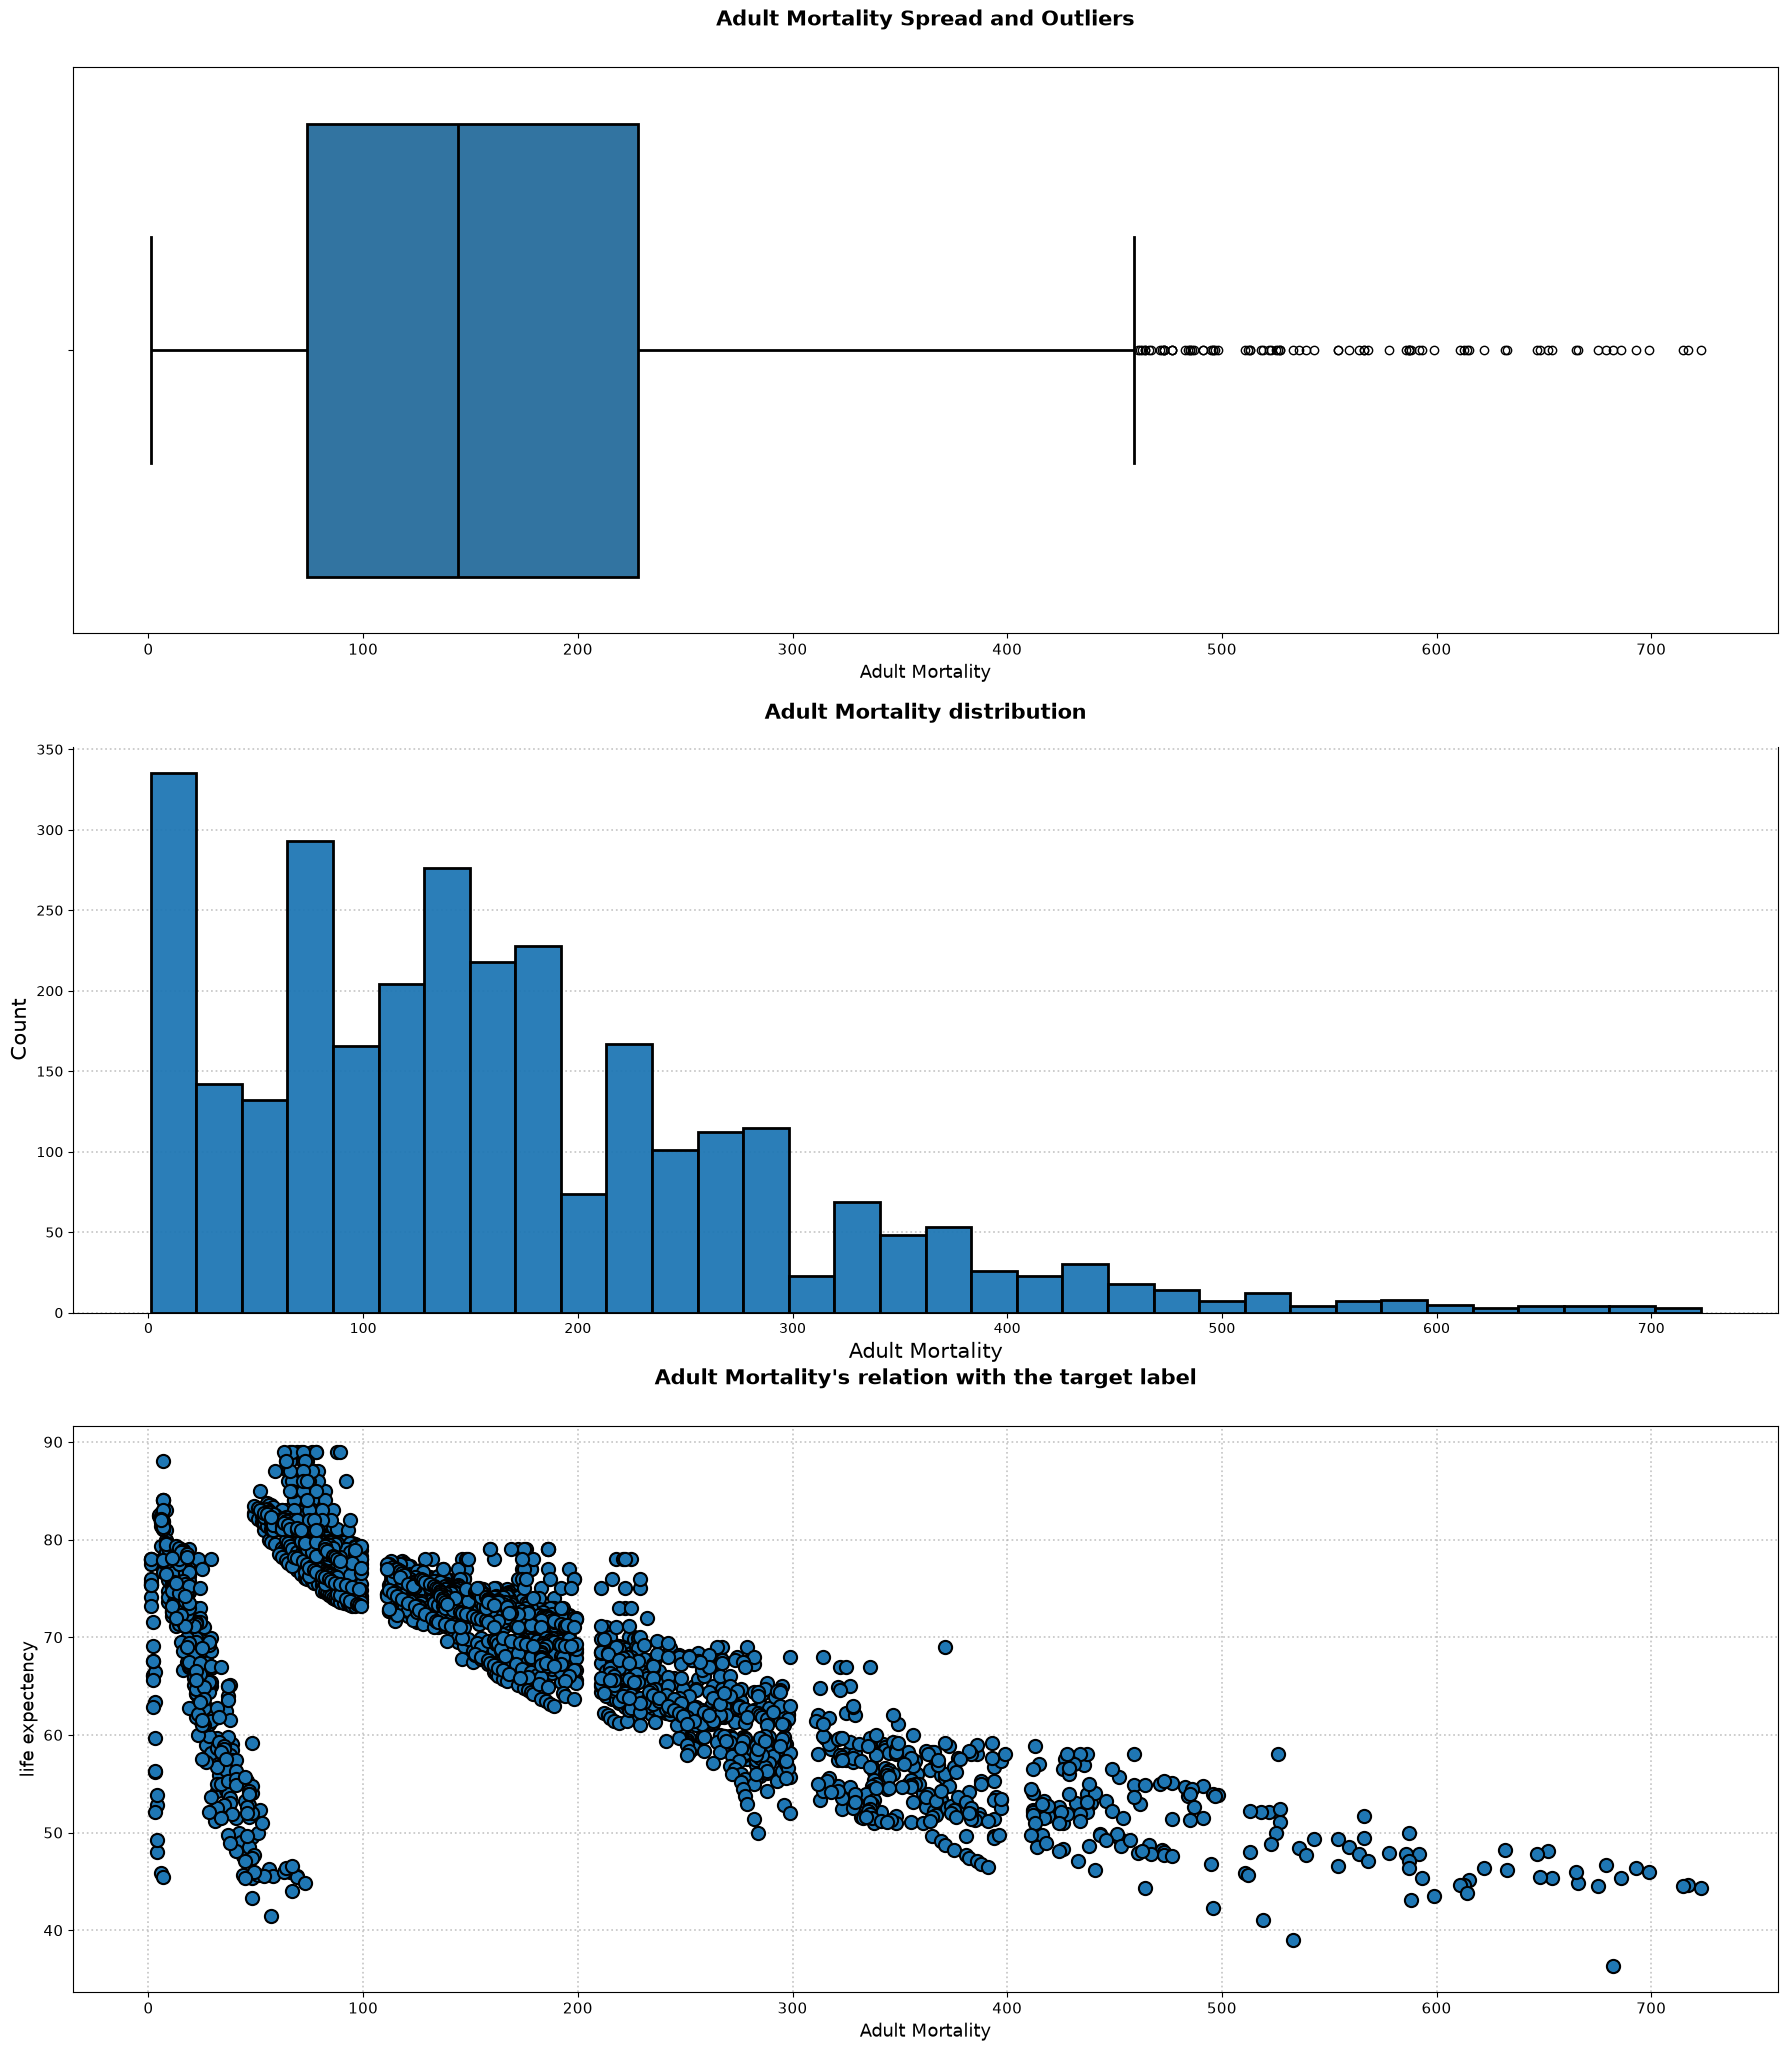


************************************************************************************************************************************



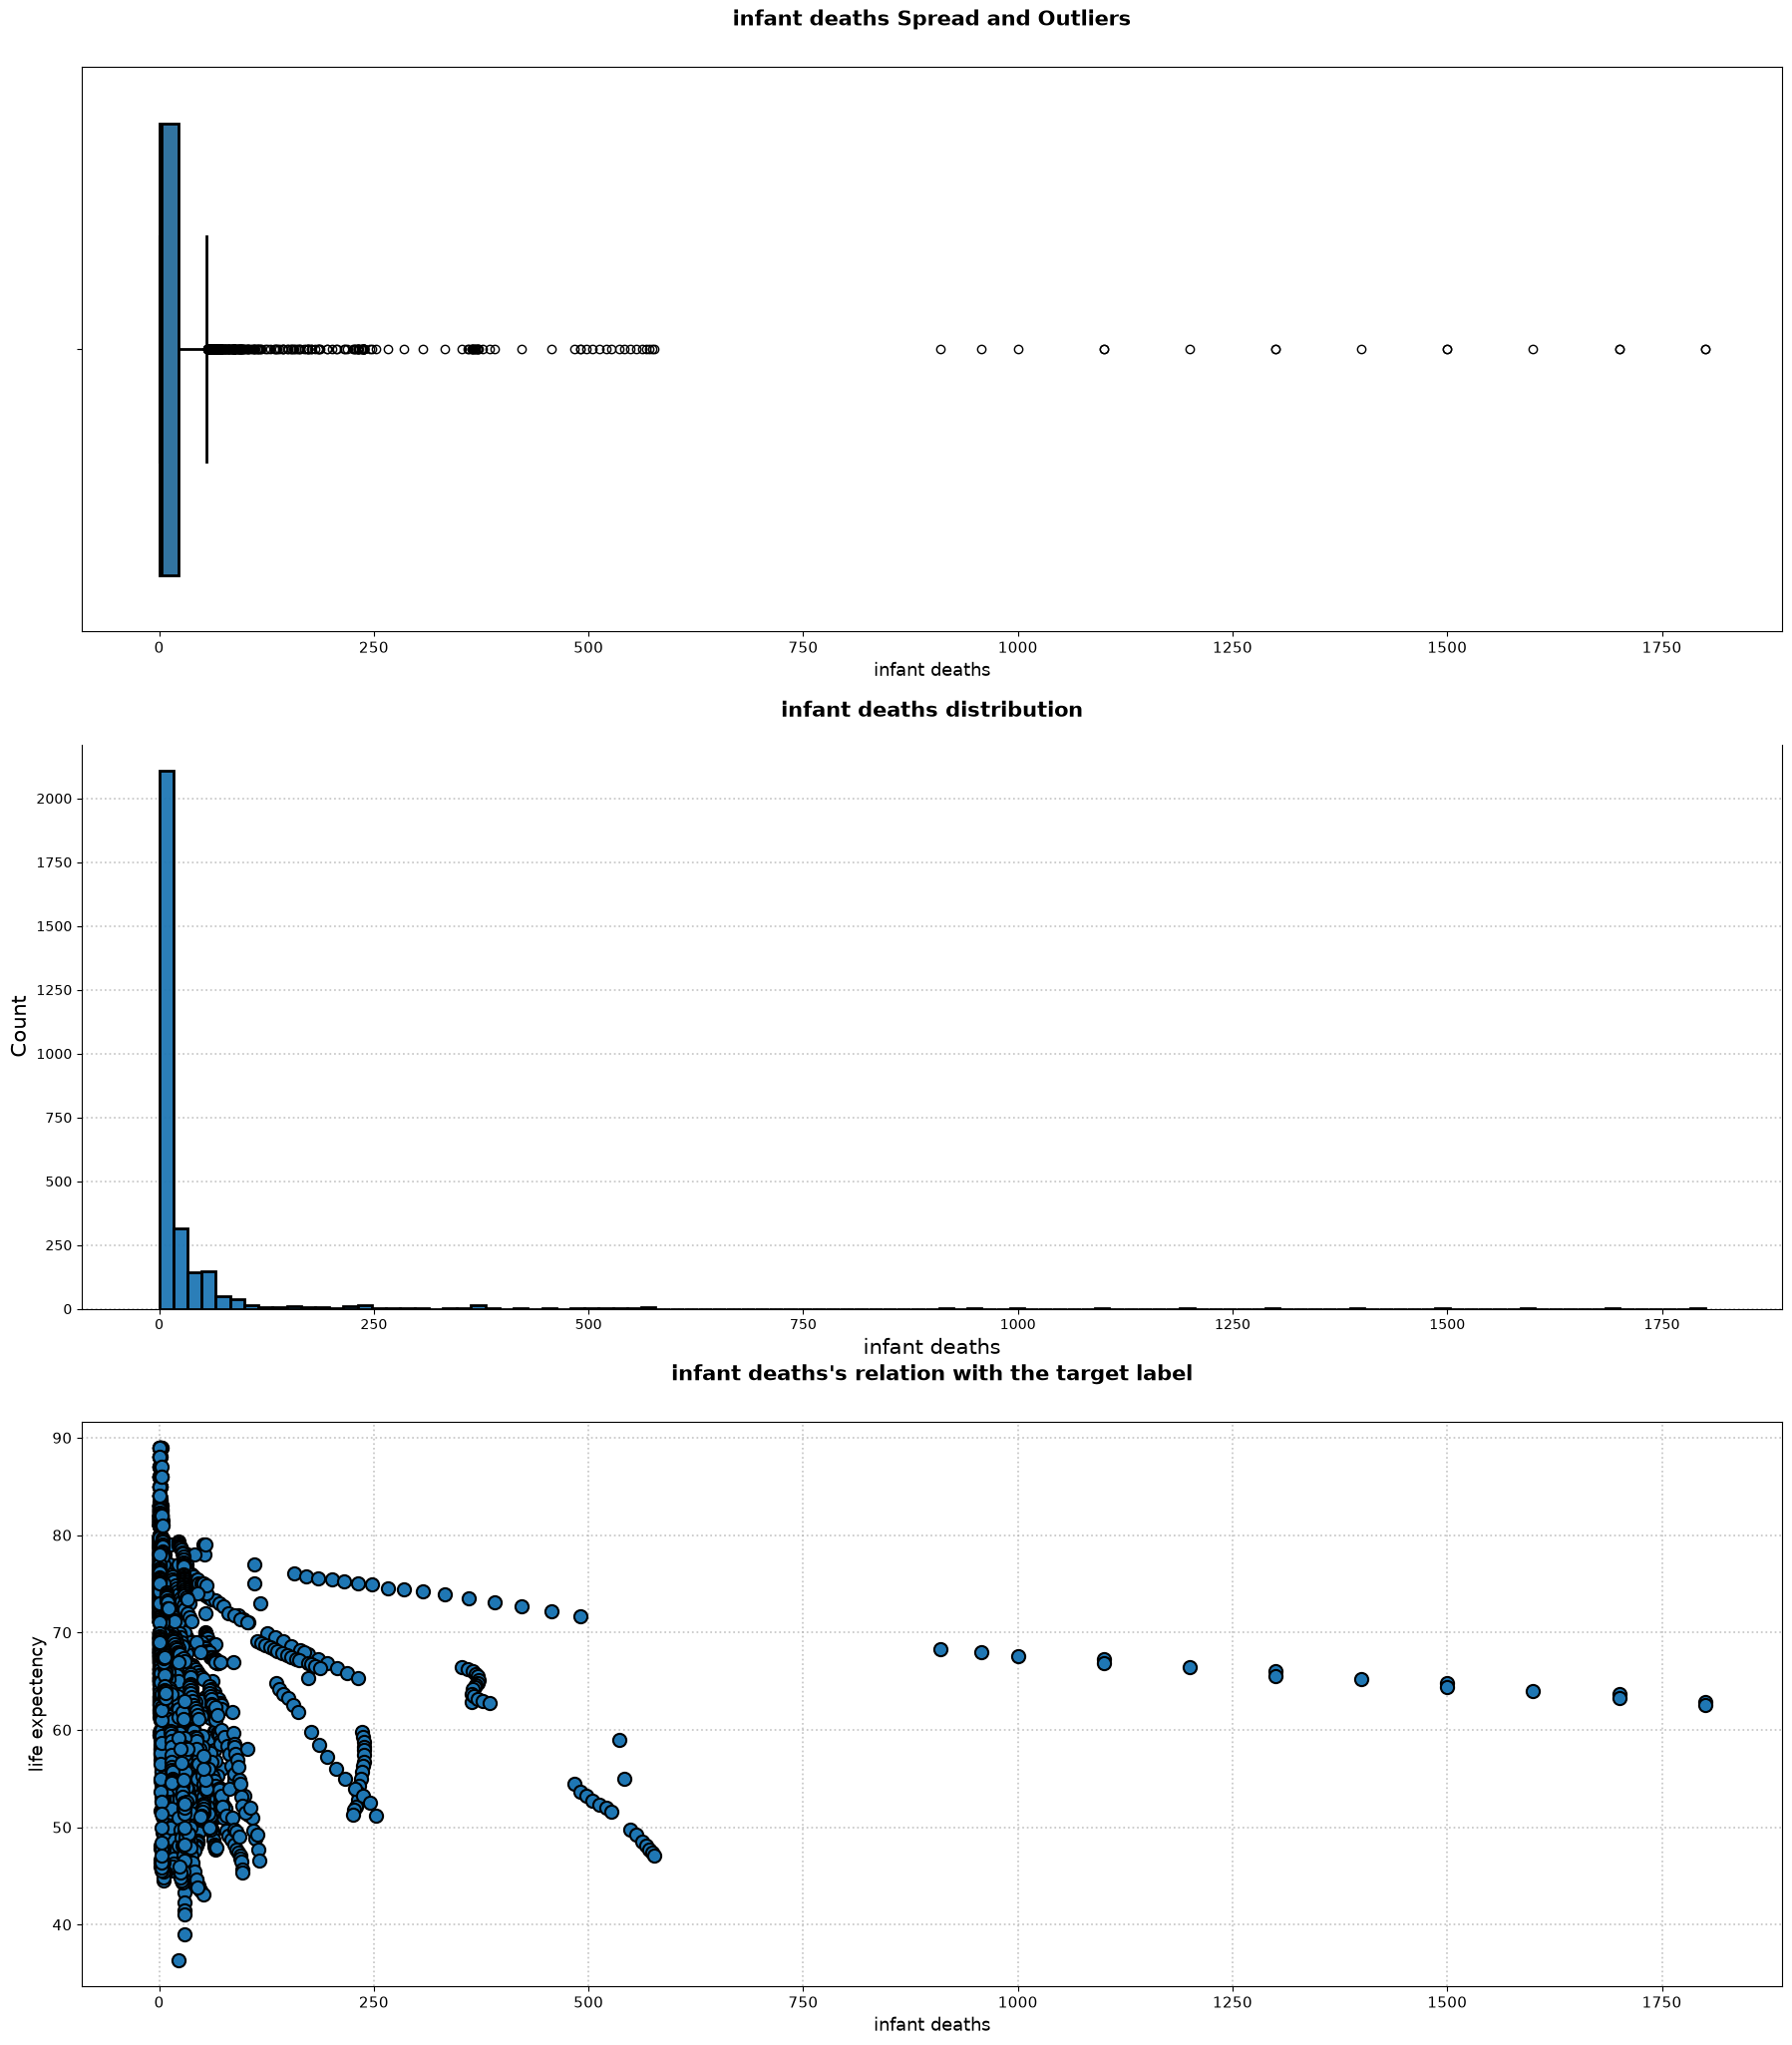


************************************************************************************************************************************



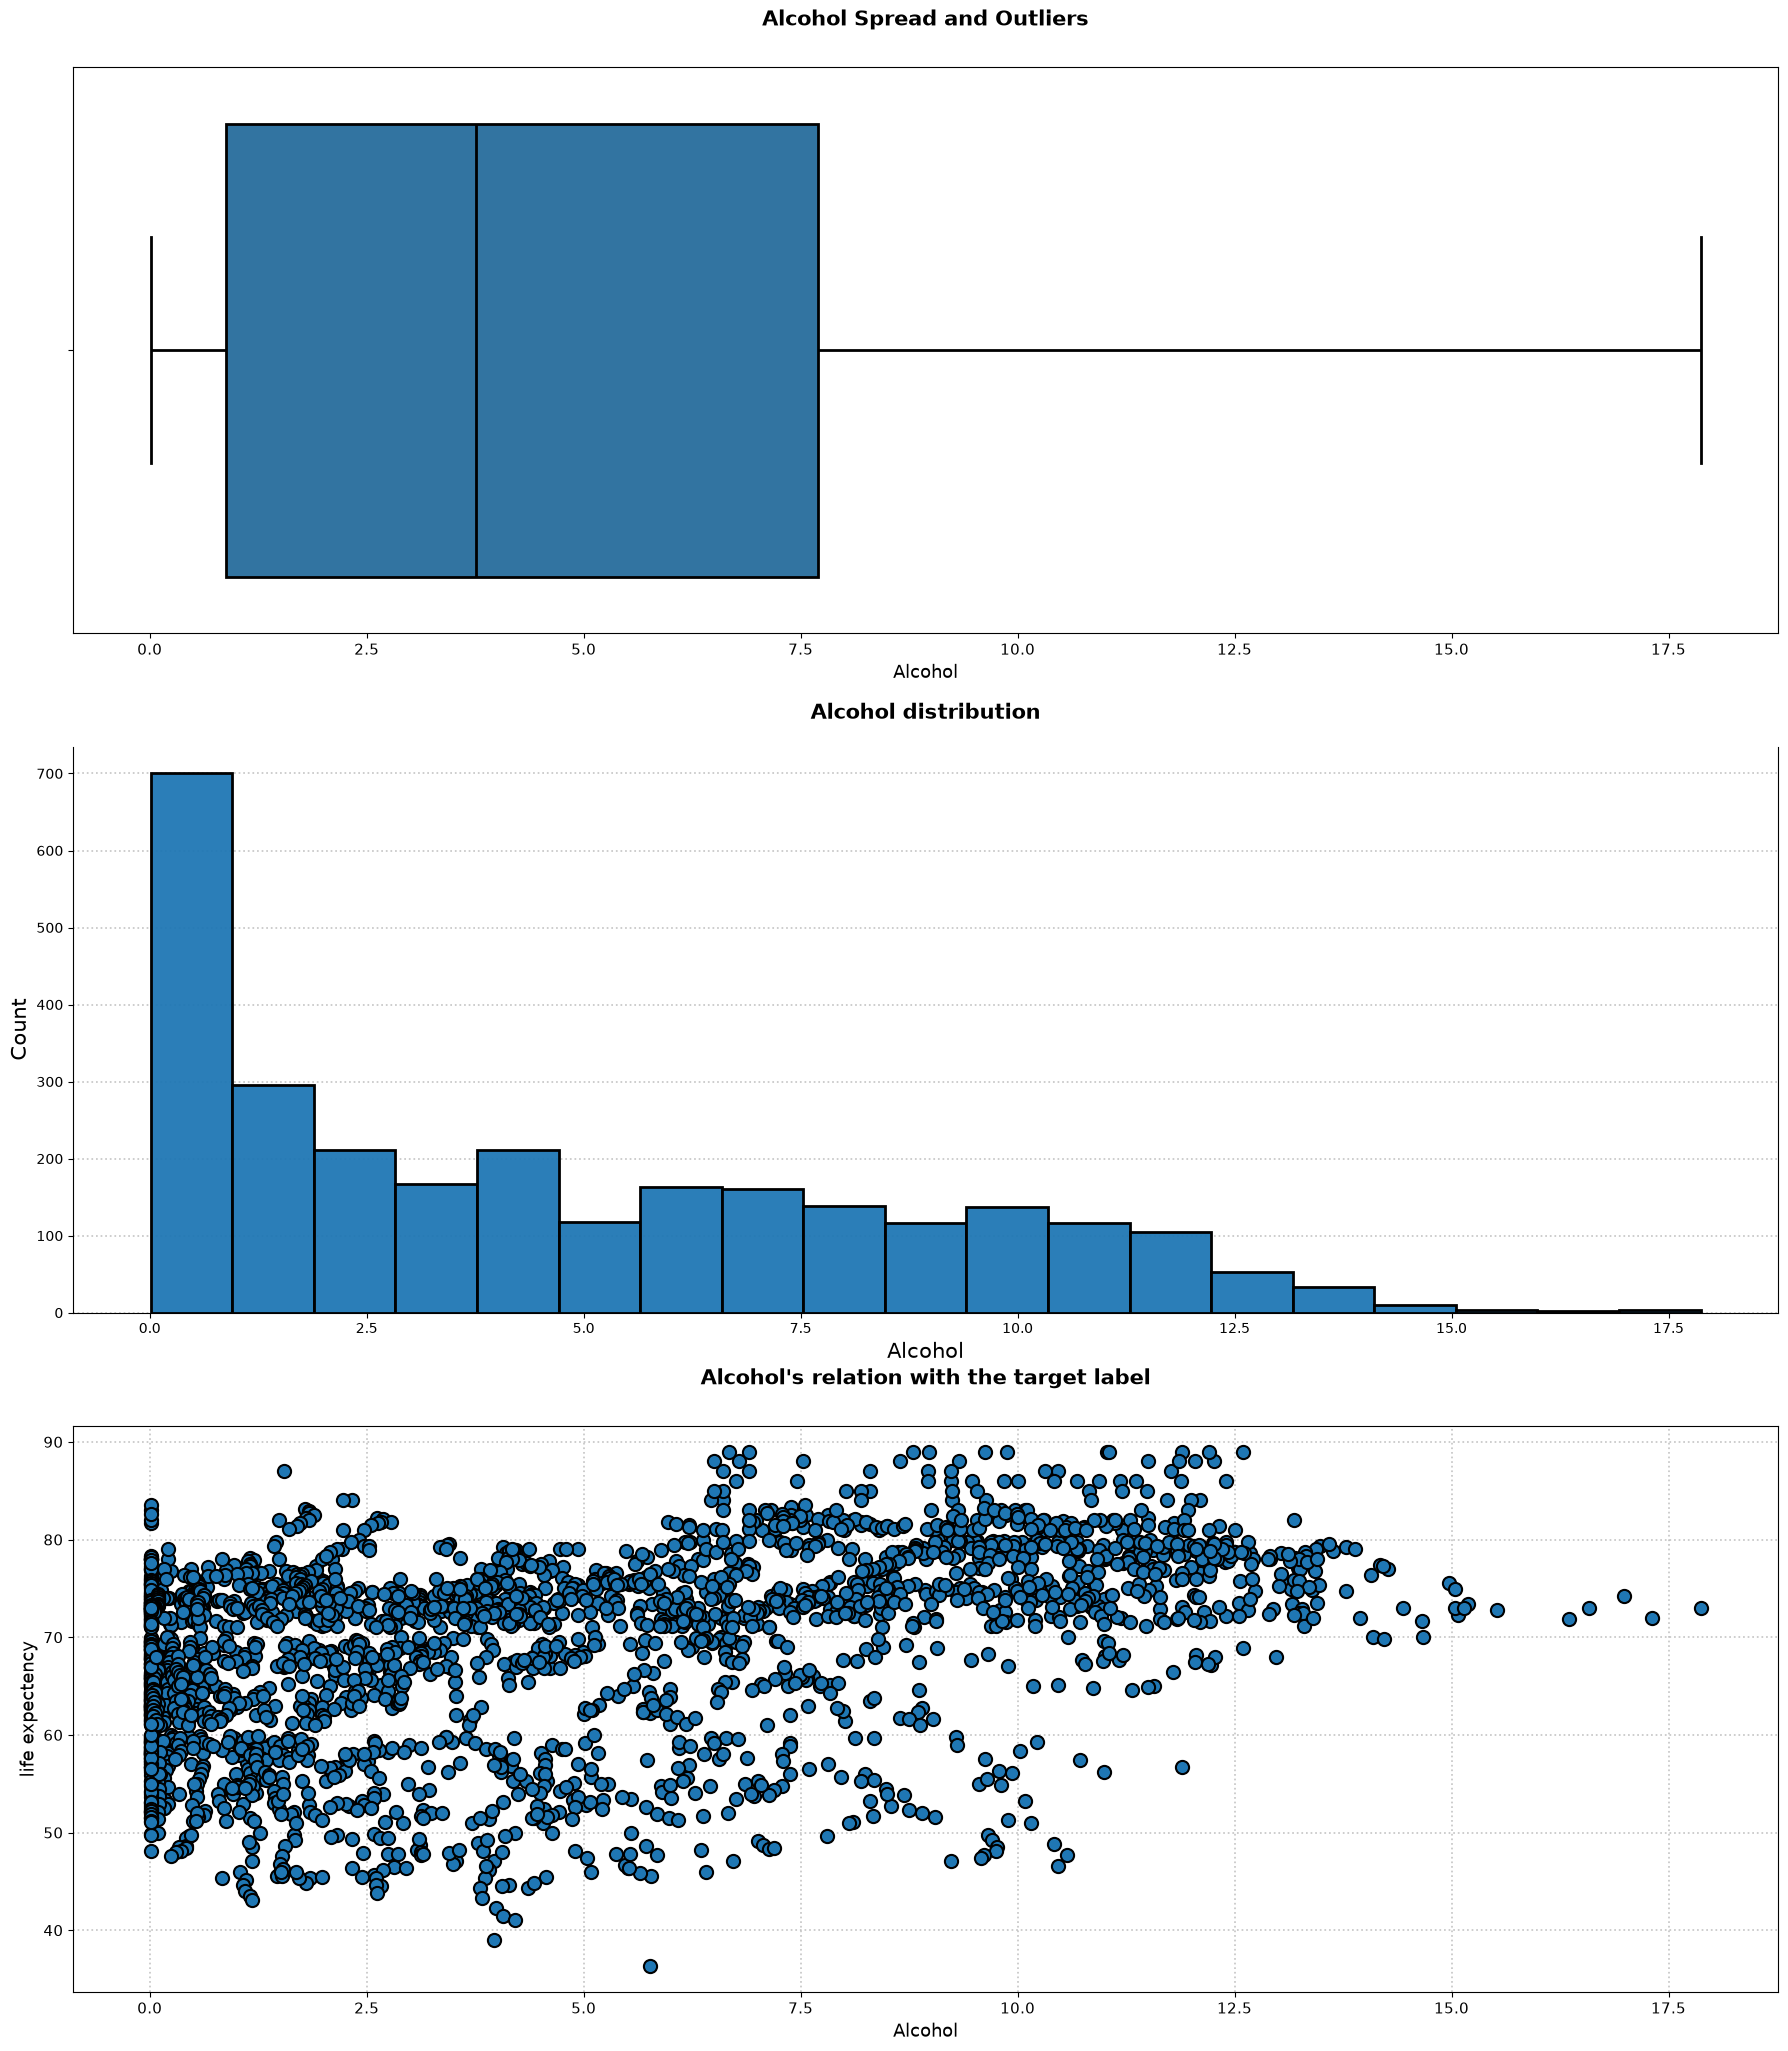


************************************************************************************************************************************



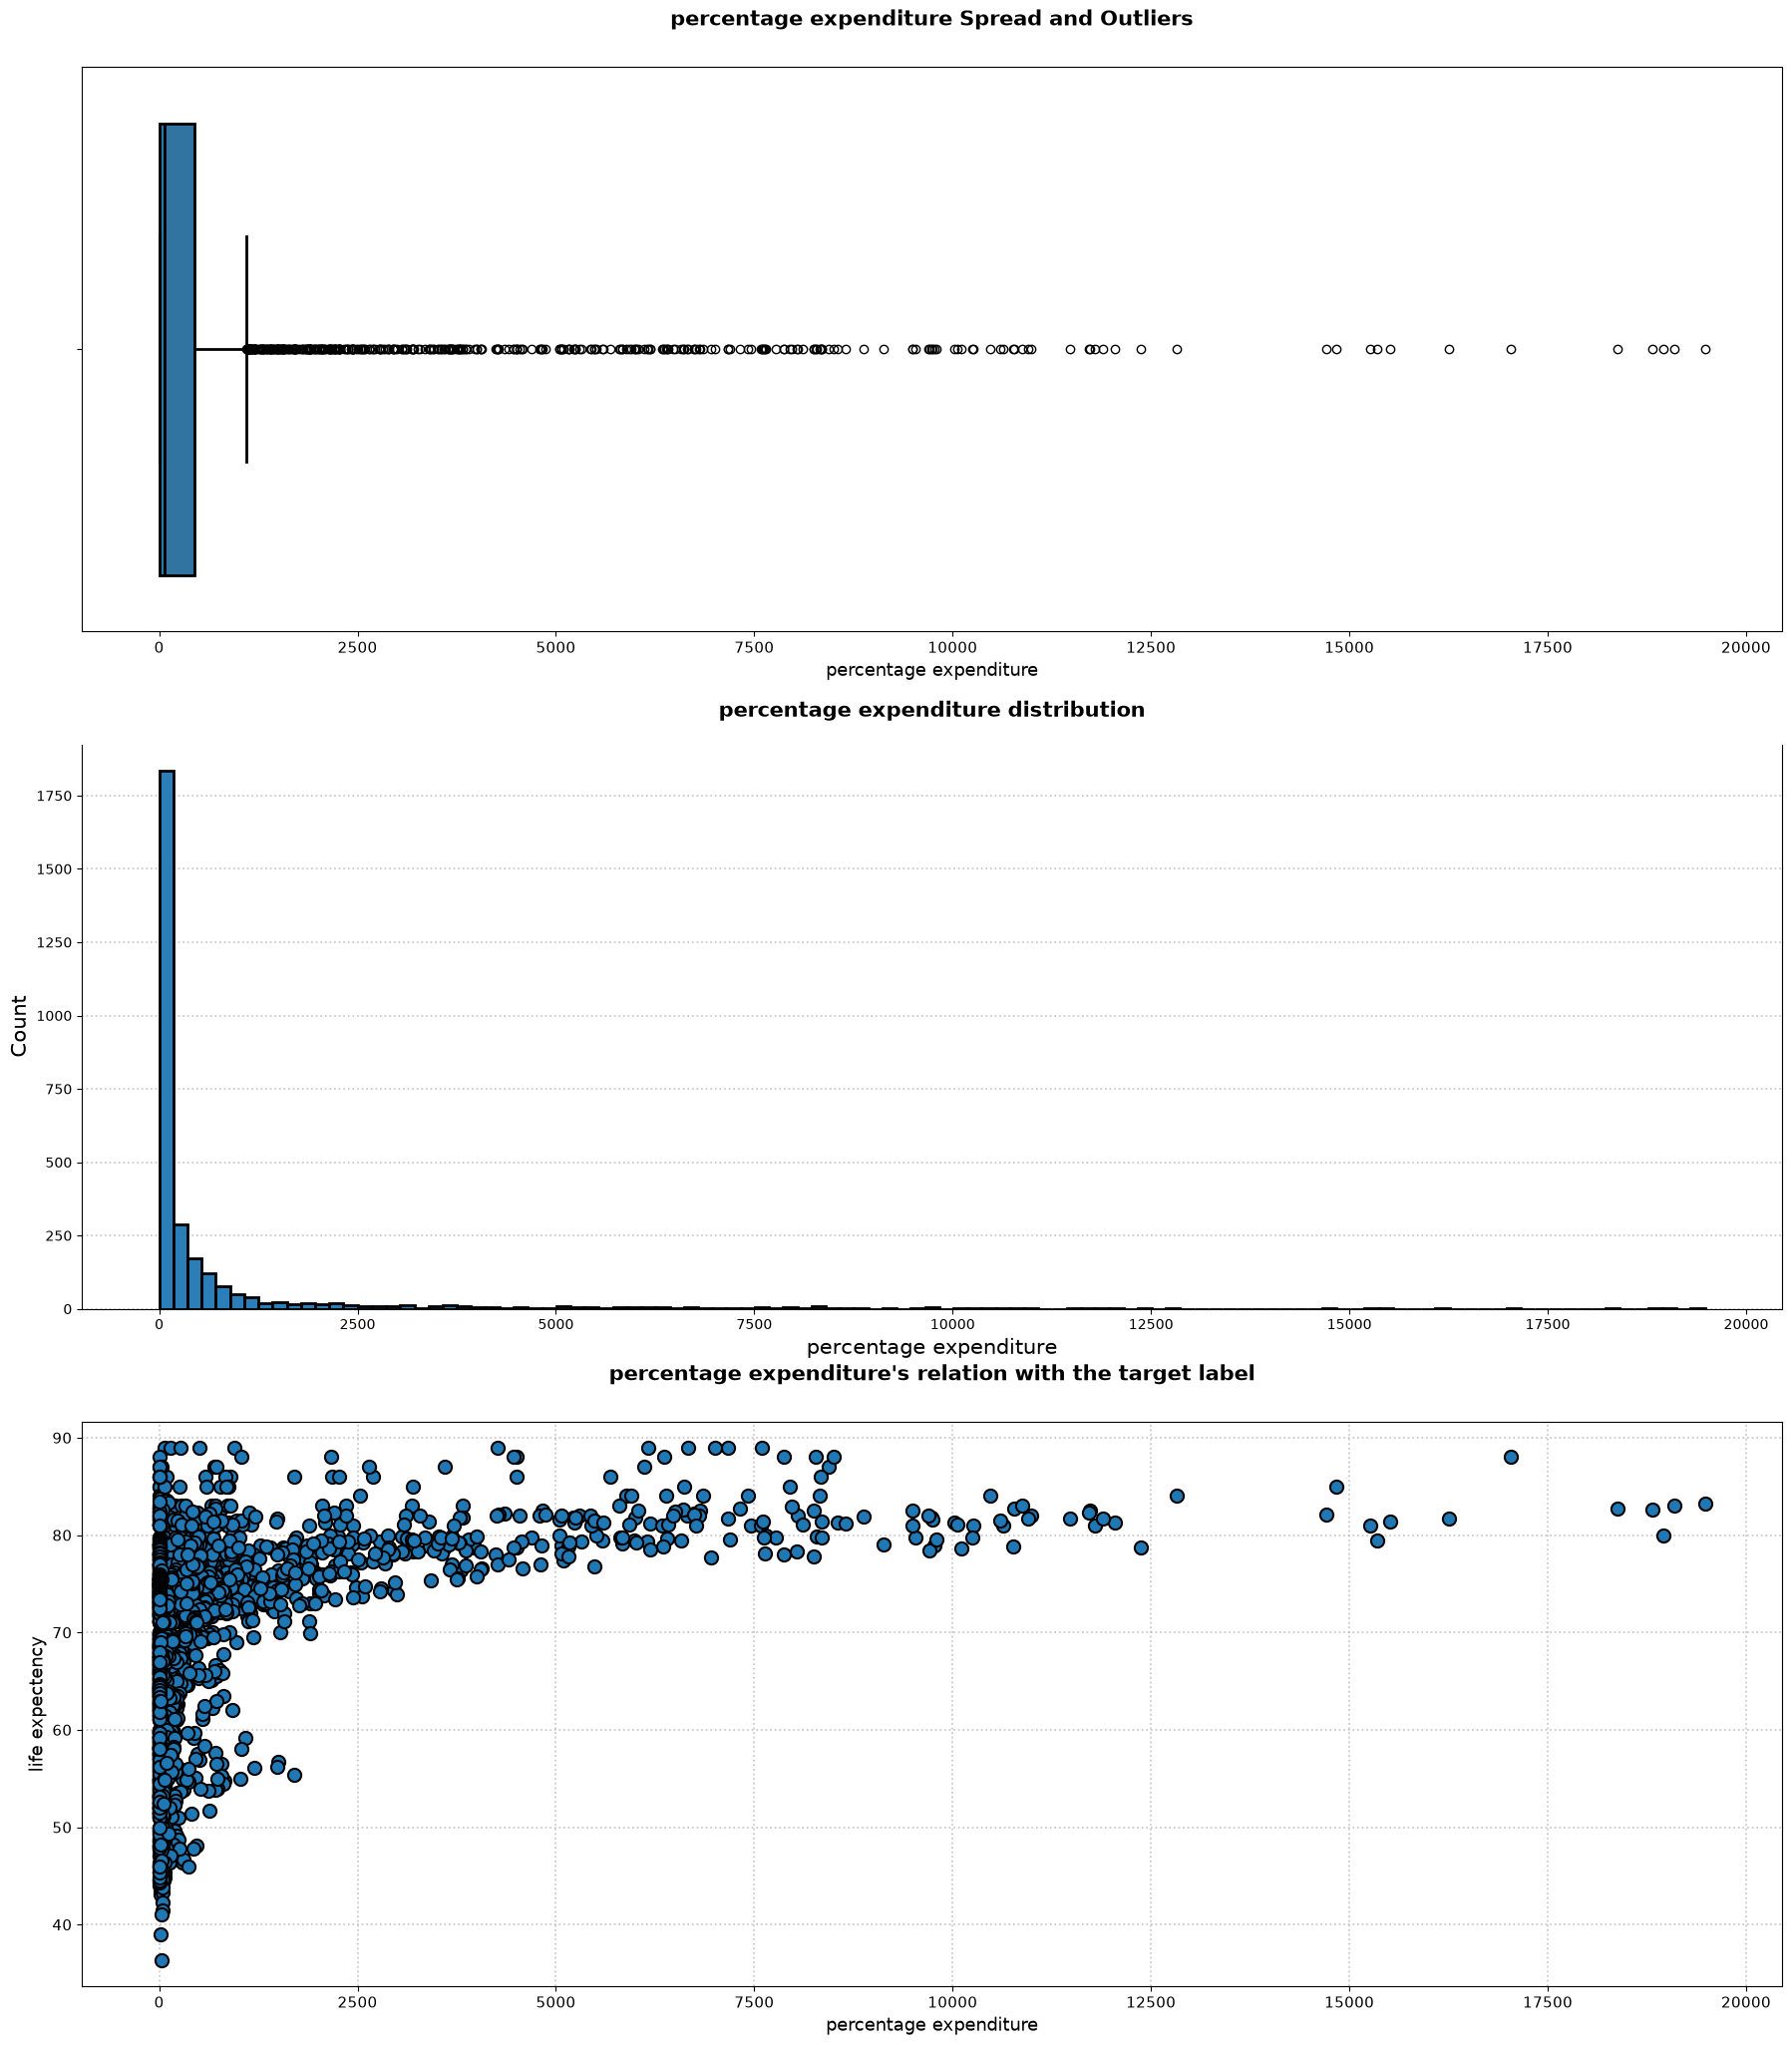


************************************************************************************************************************************



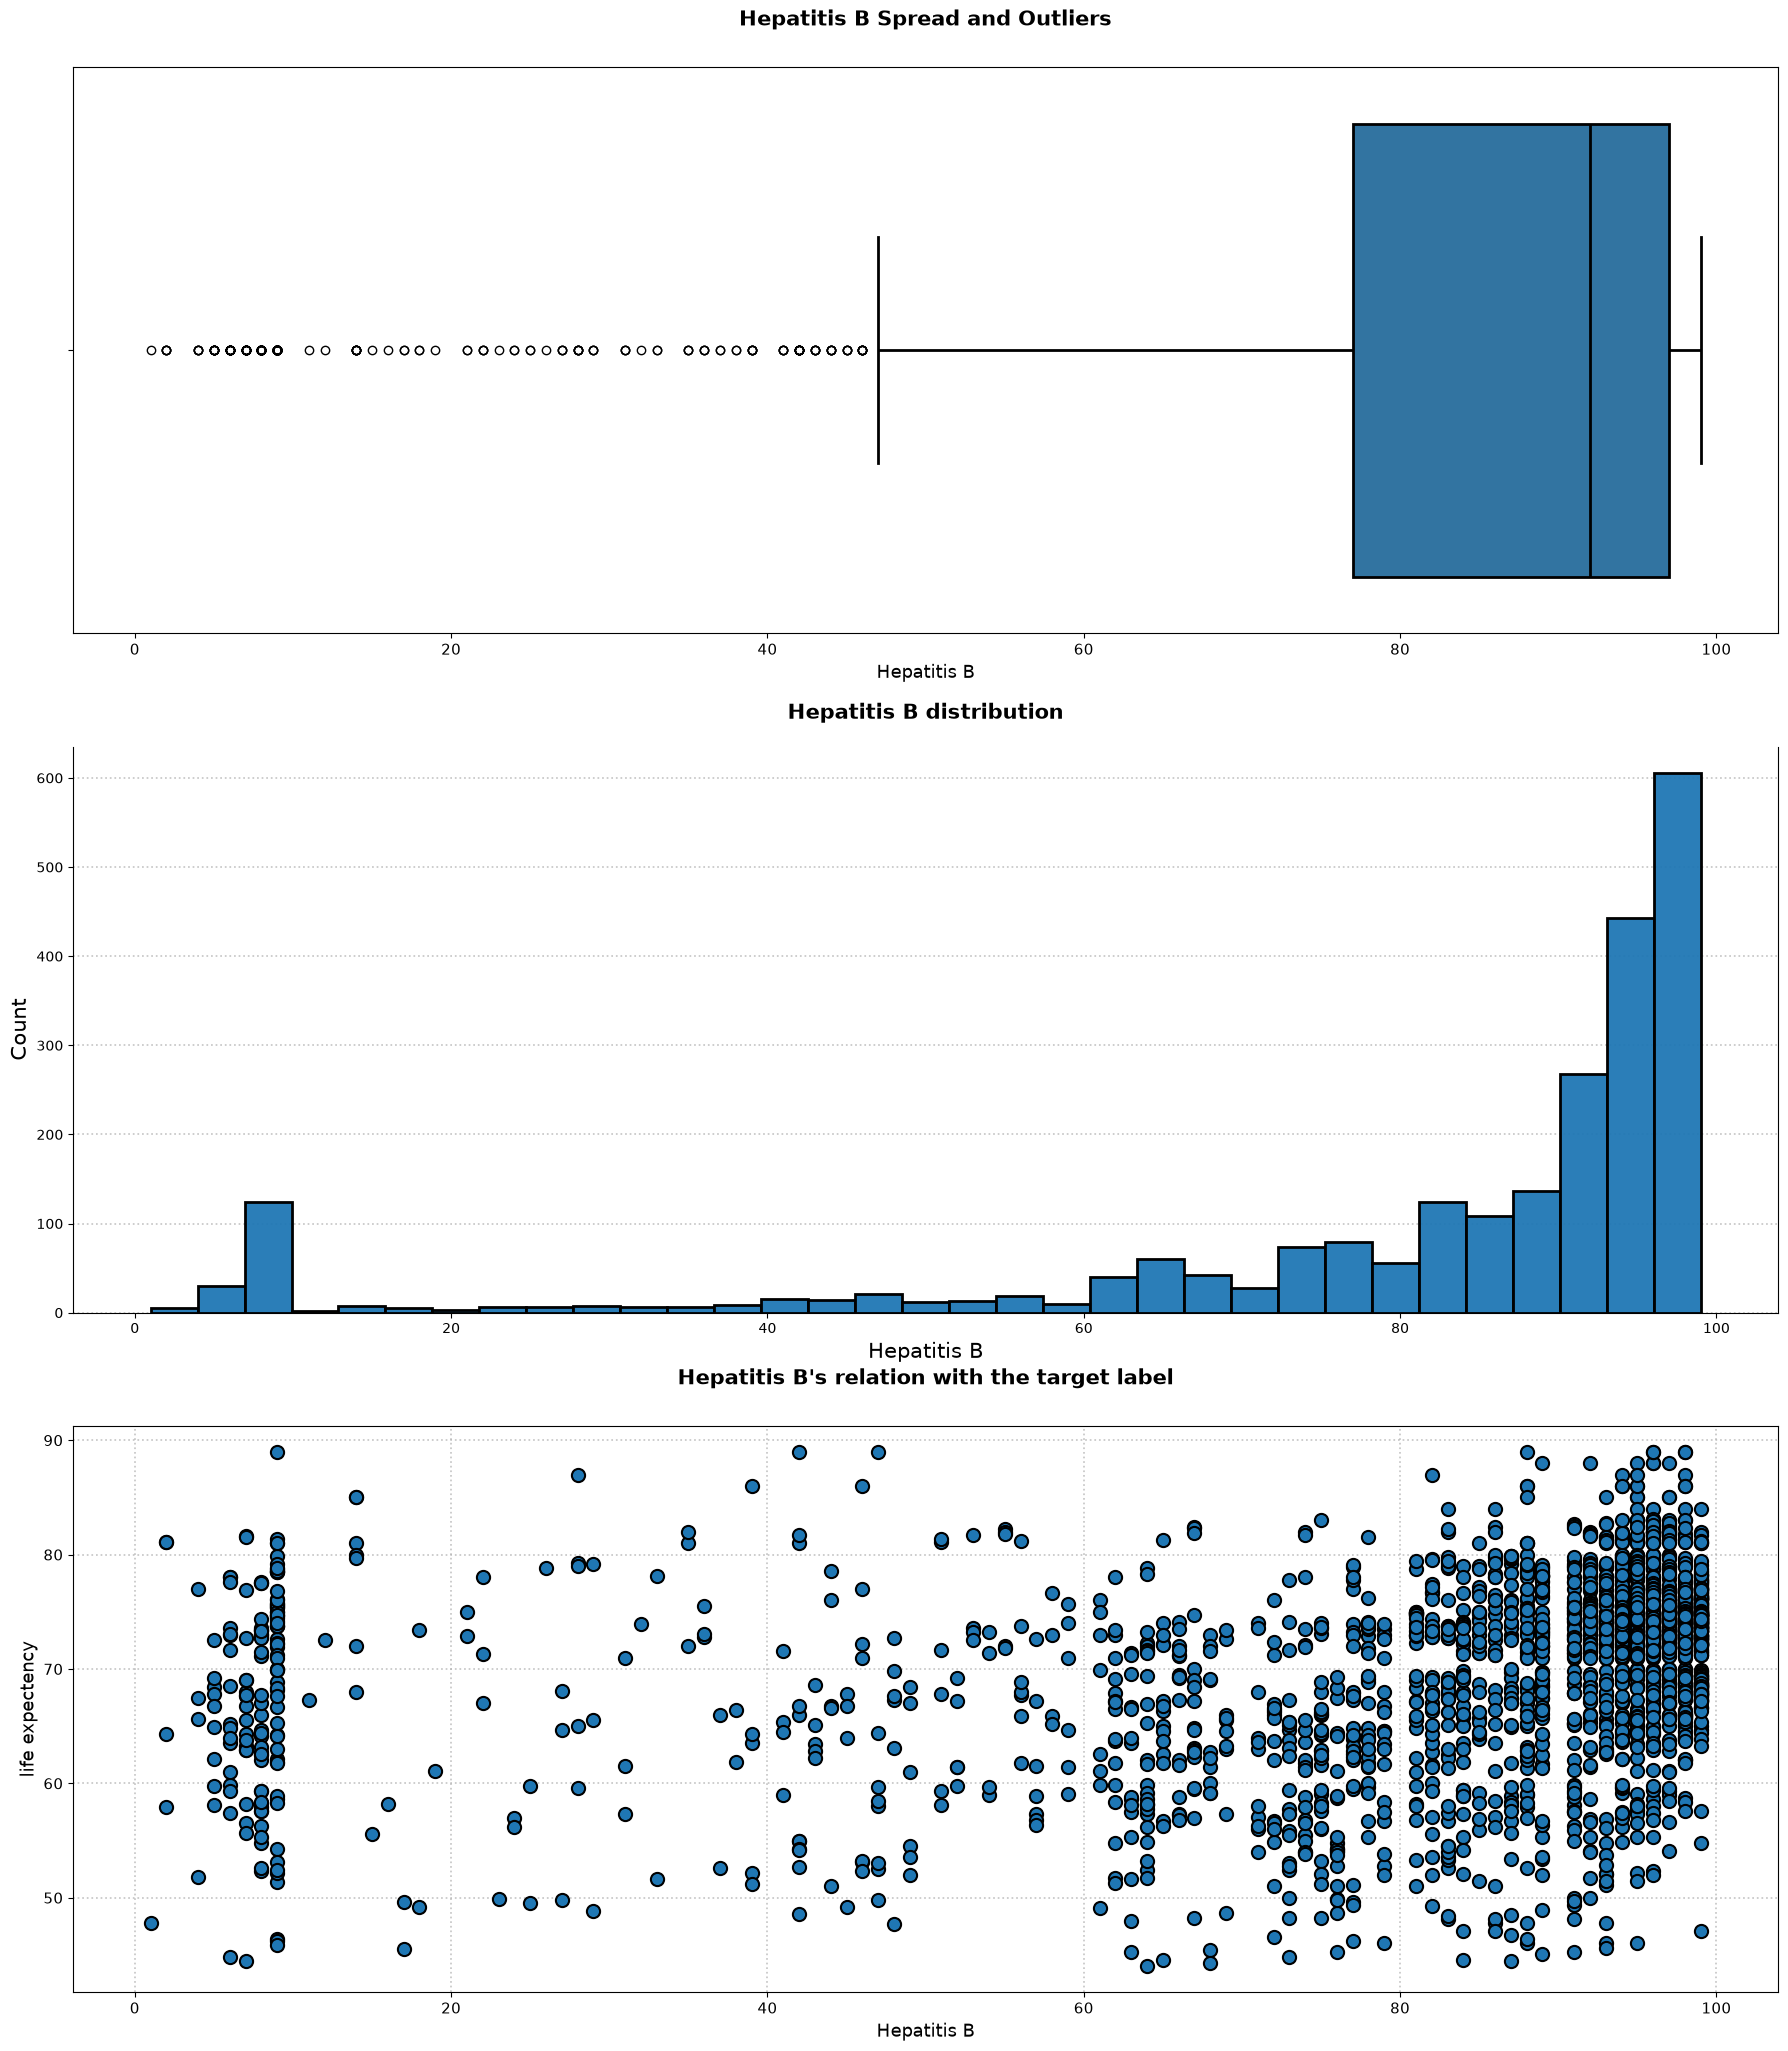


************************************************************************************************************************************



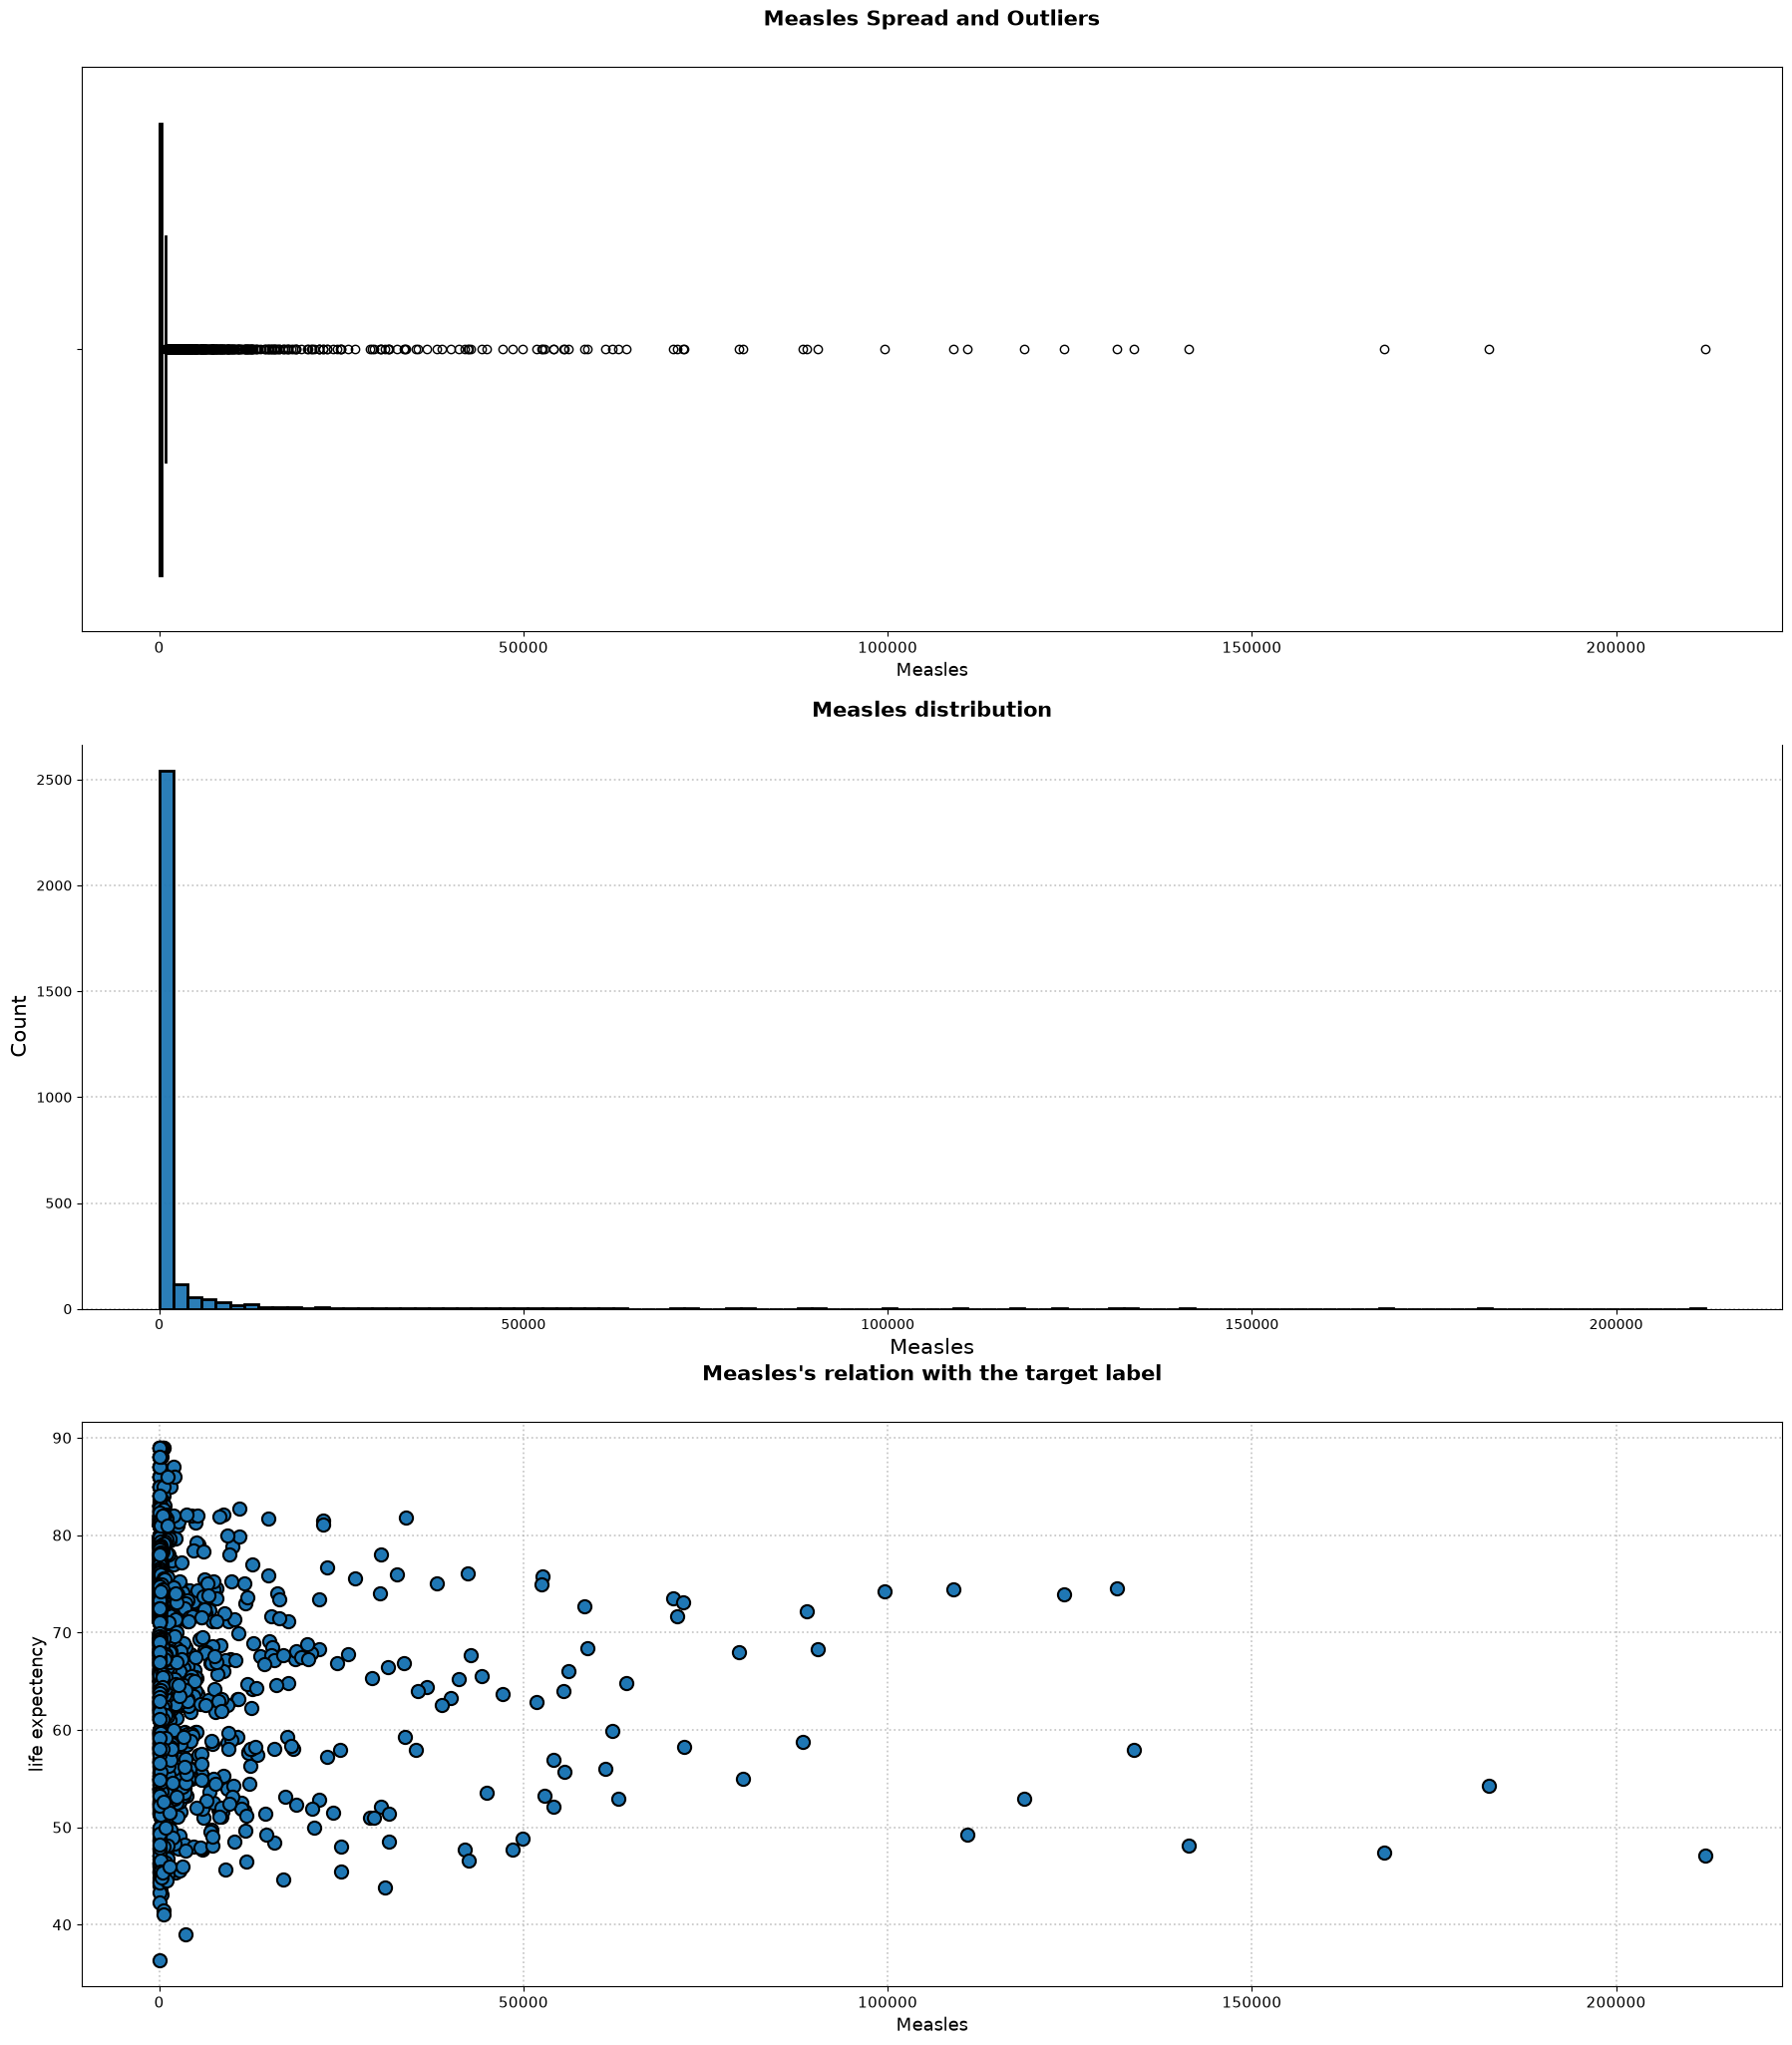


************************************************************************************************************************************



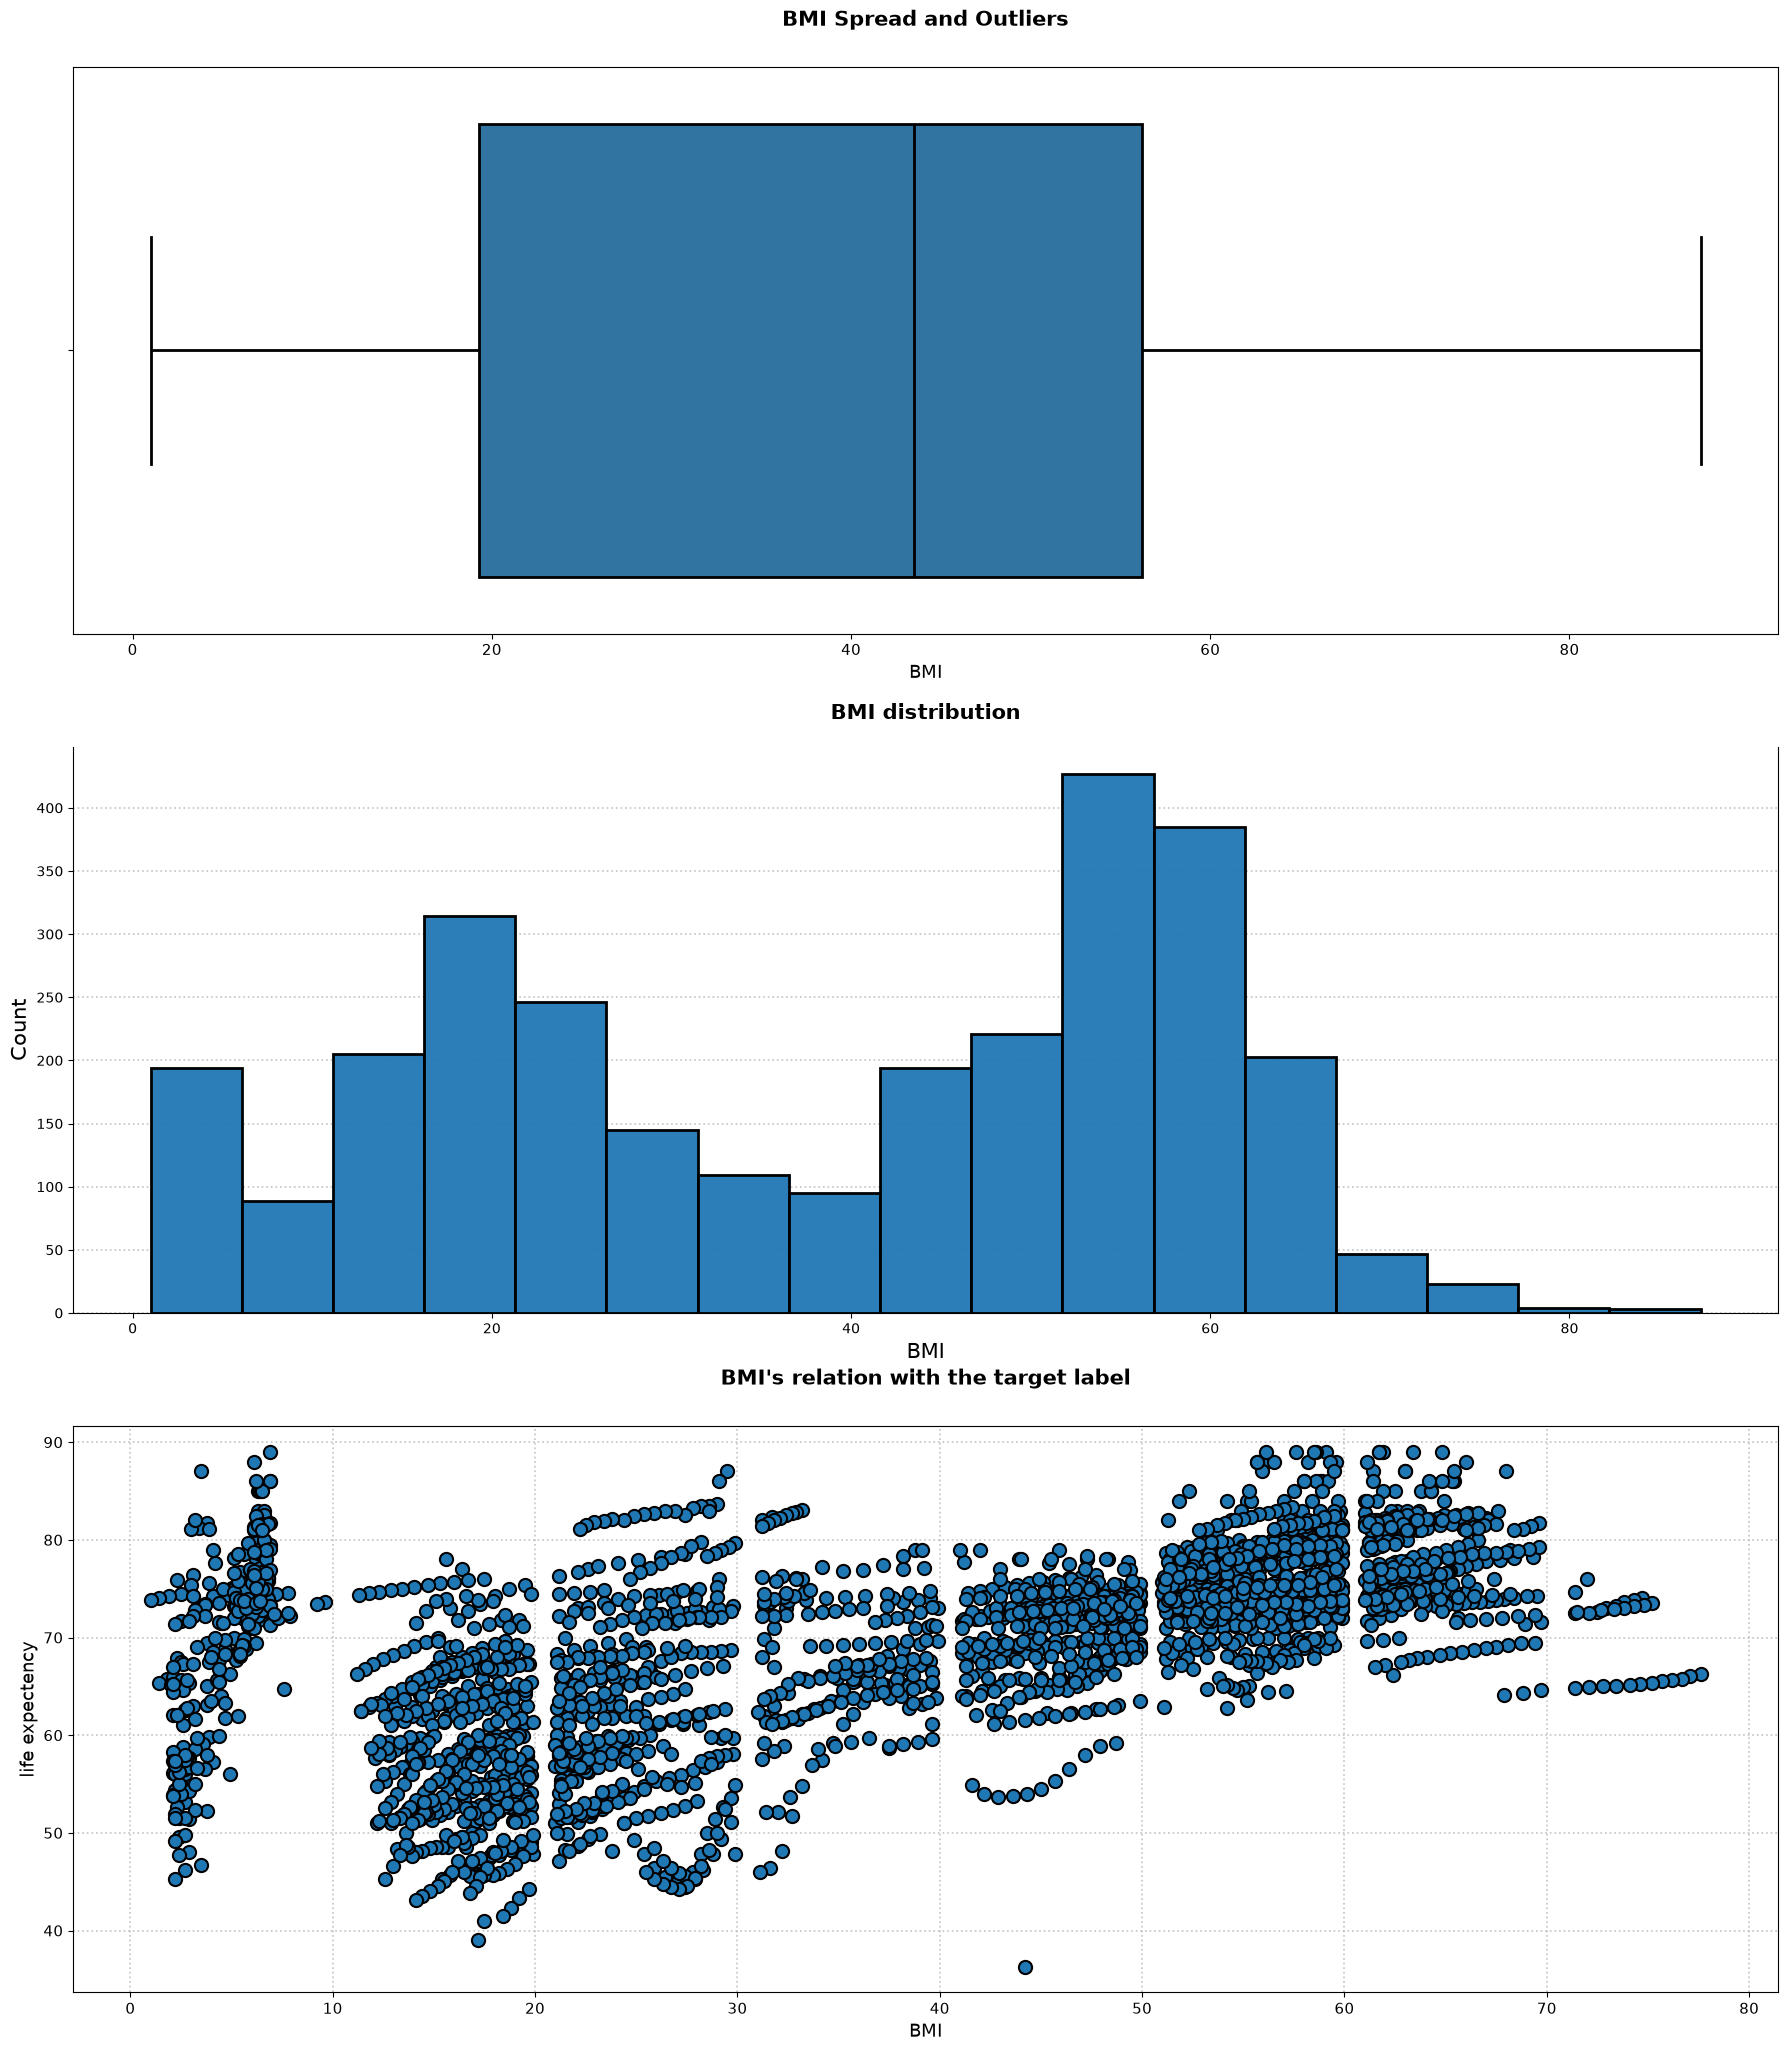


************************************************************************************************************************************



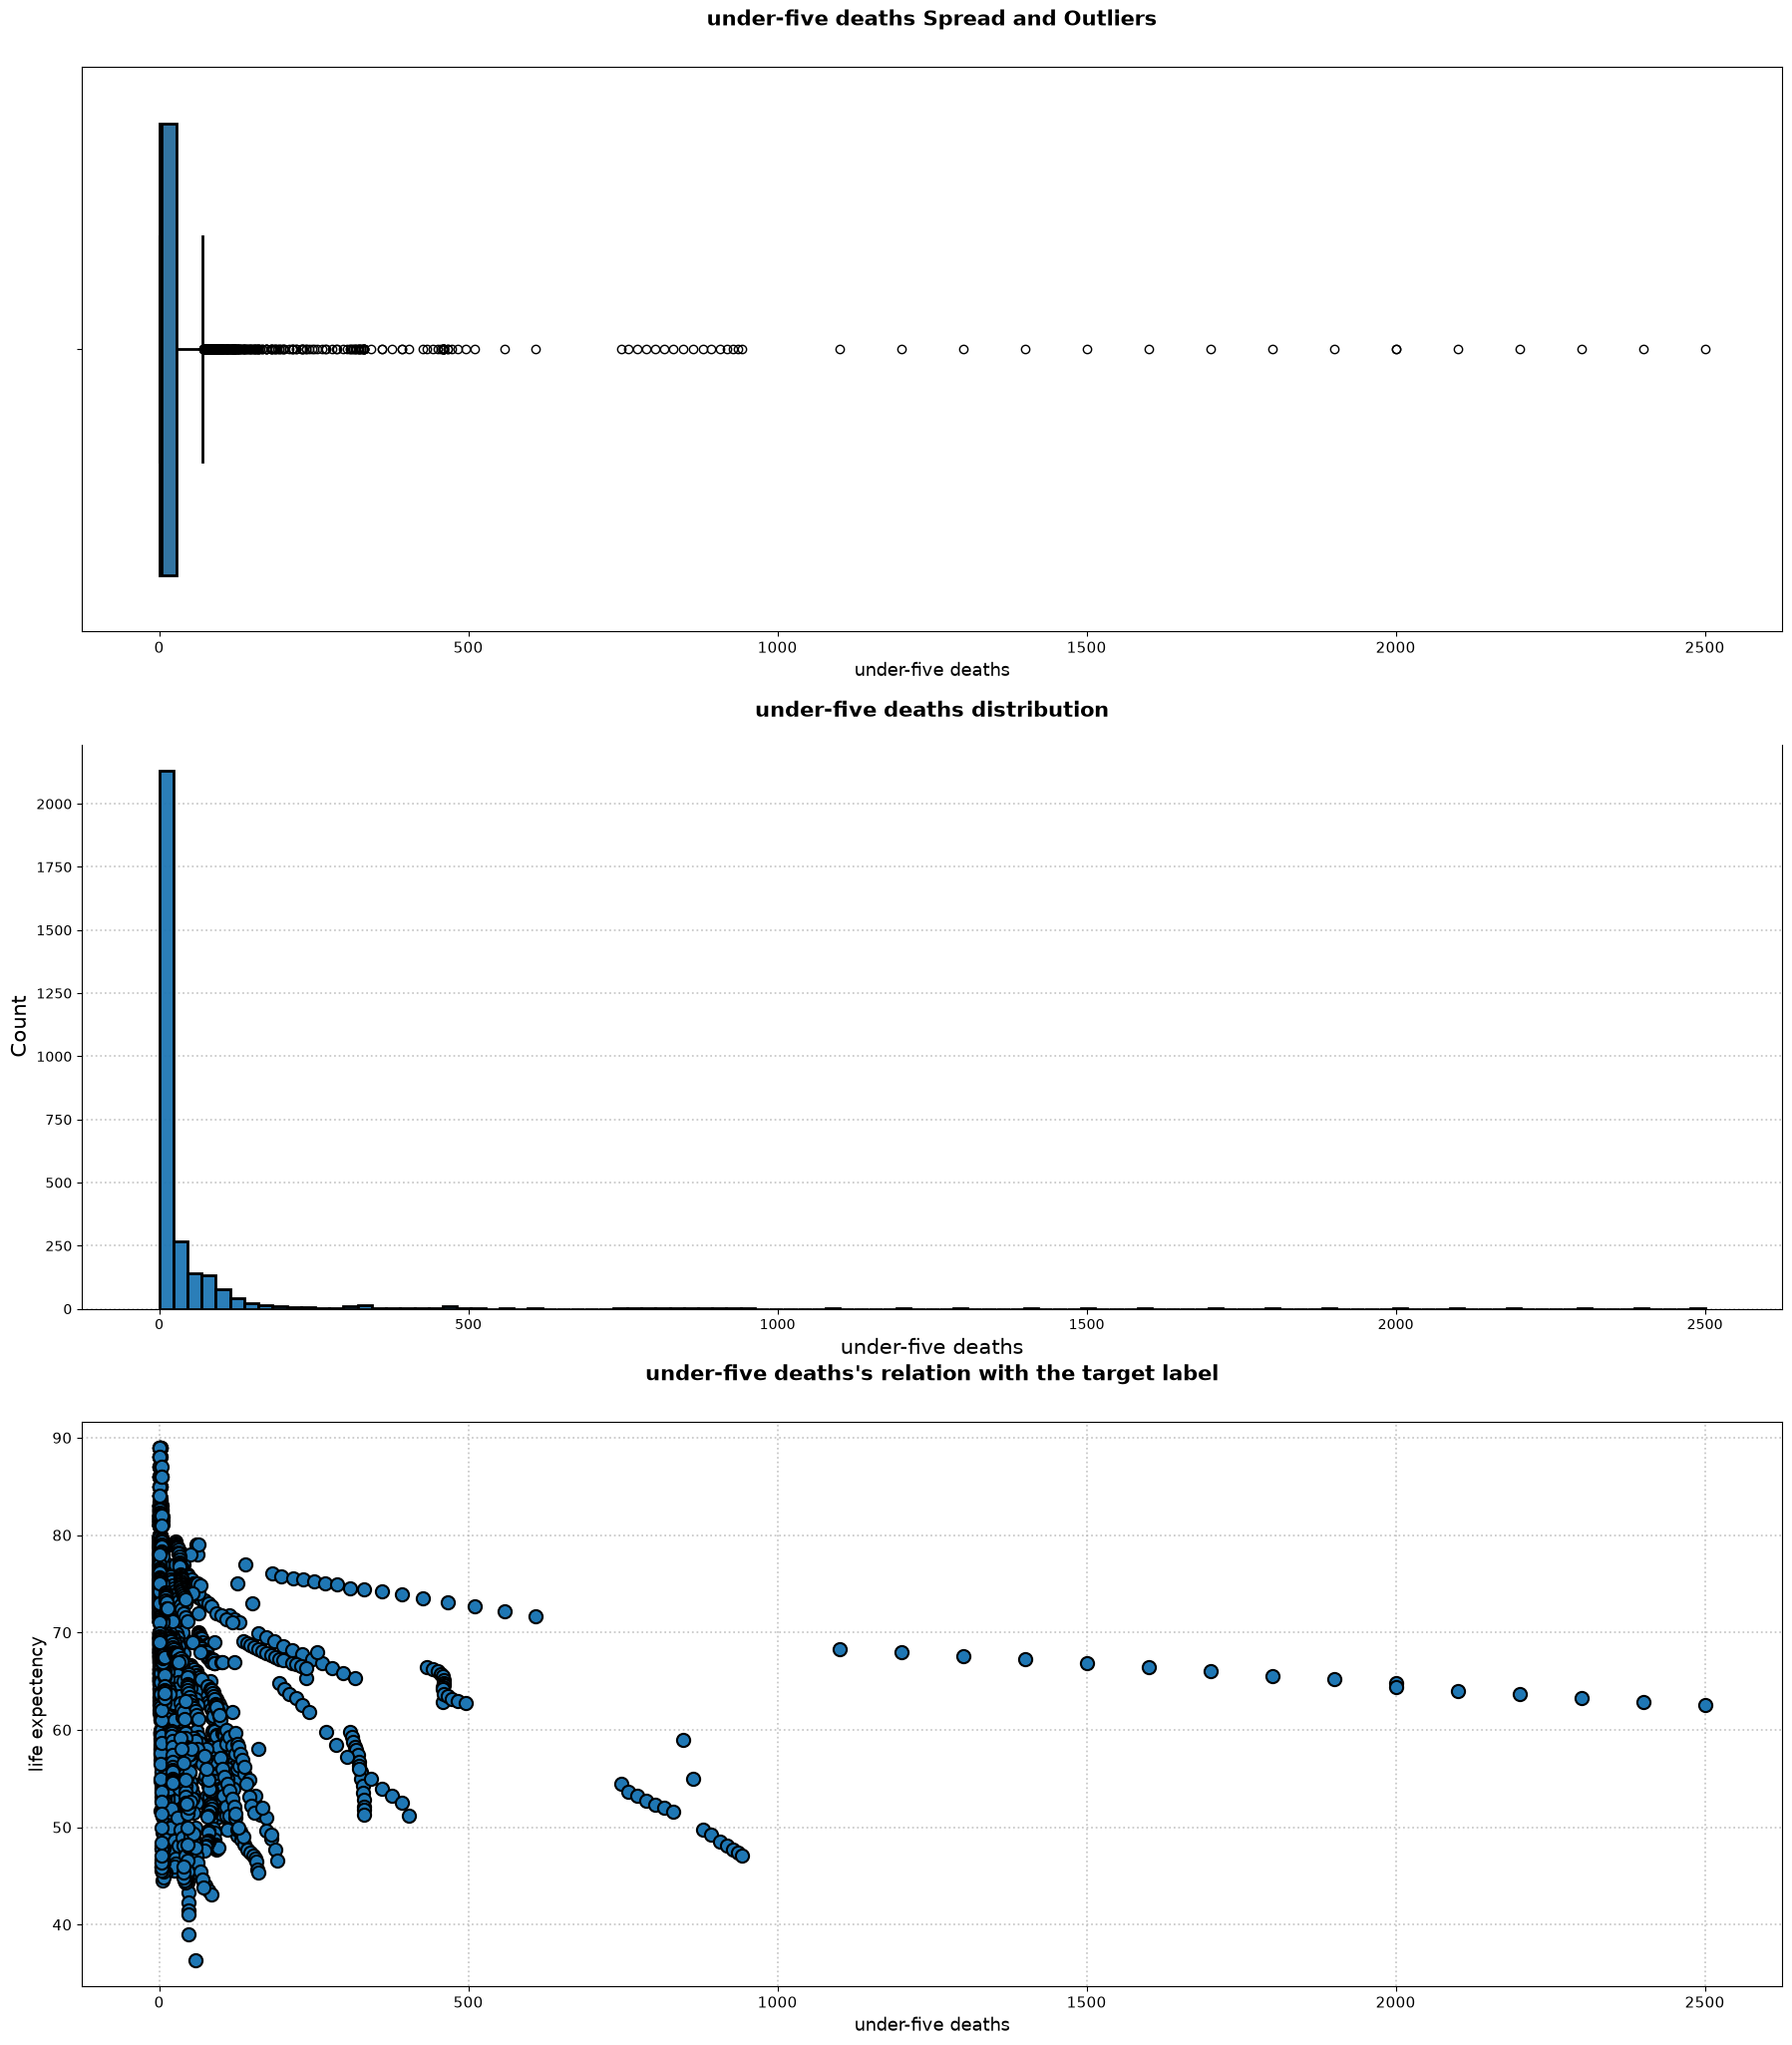


************************************************************************************************************************************



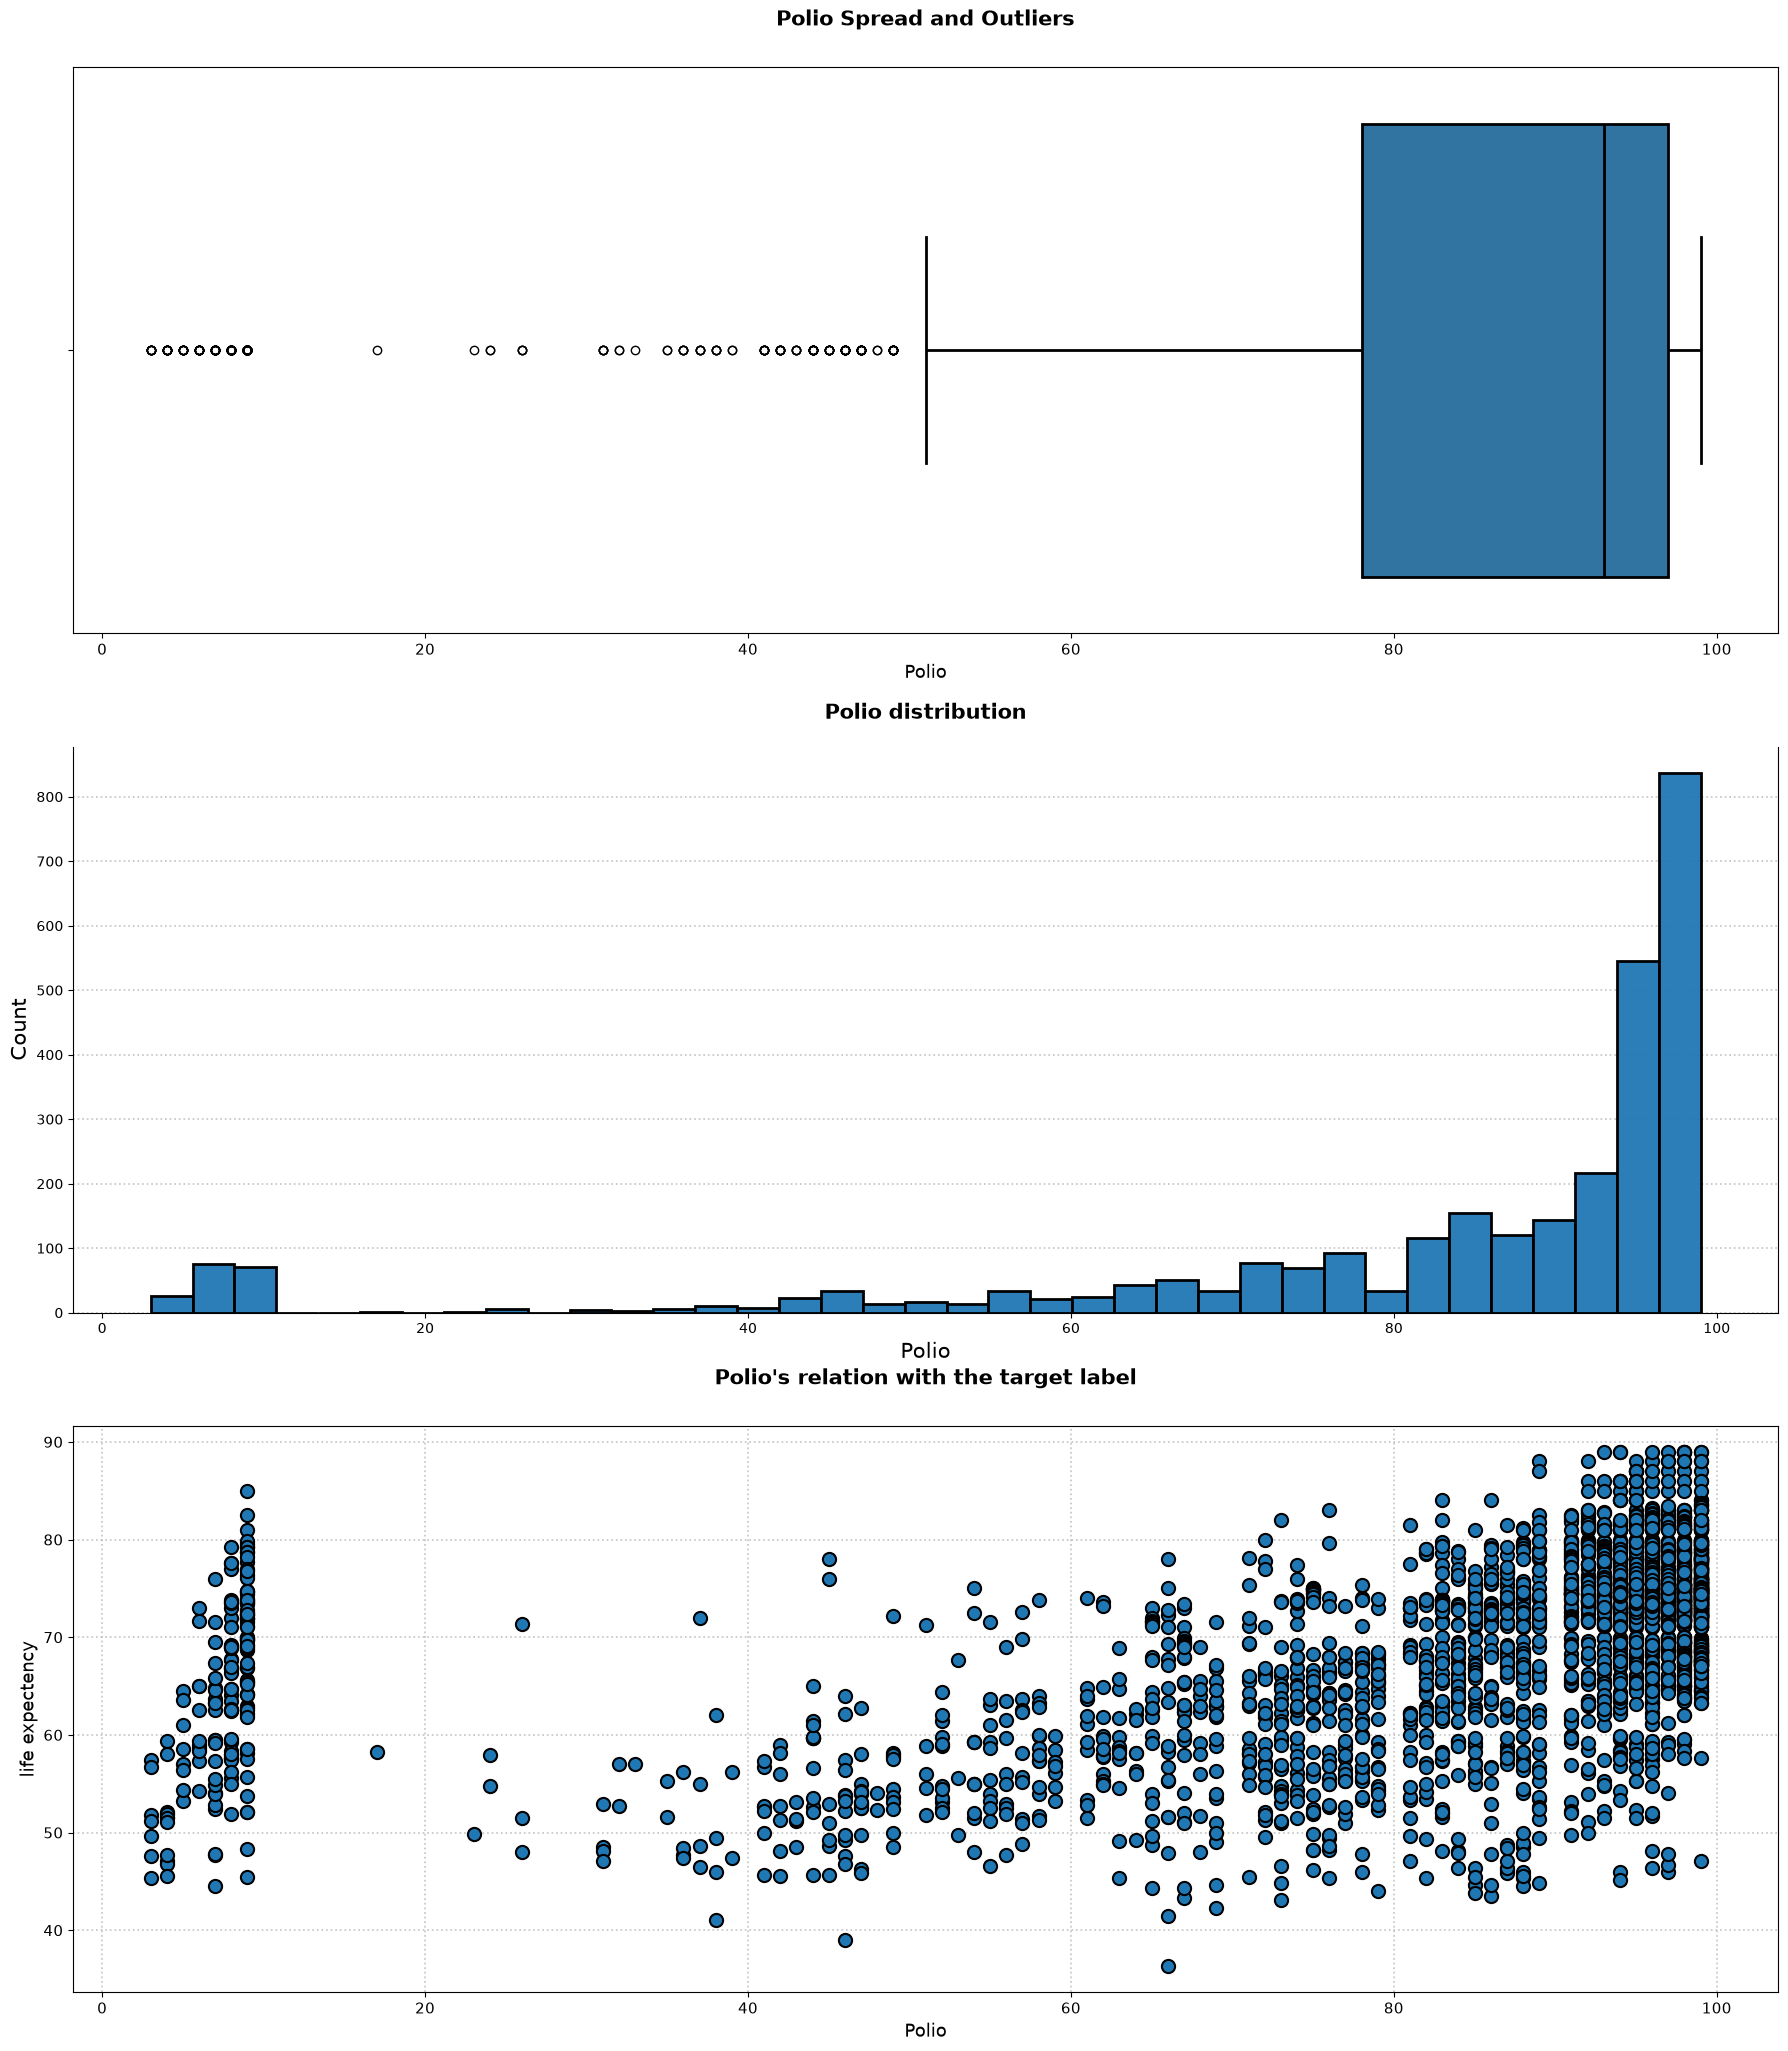


************************************************************************************************************************************



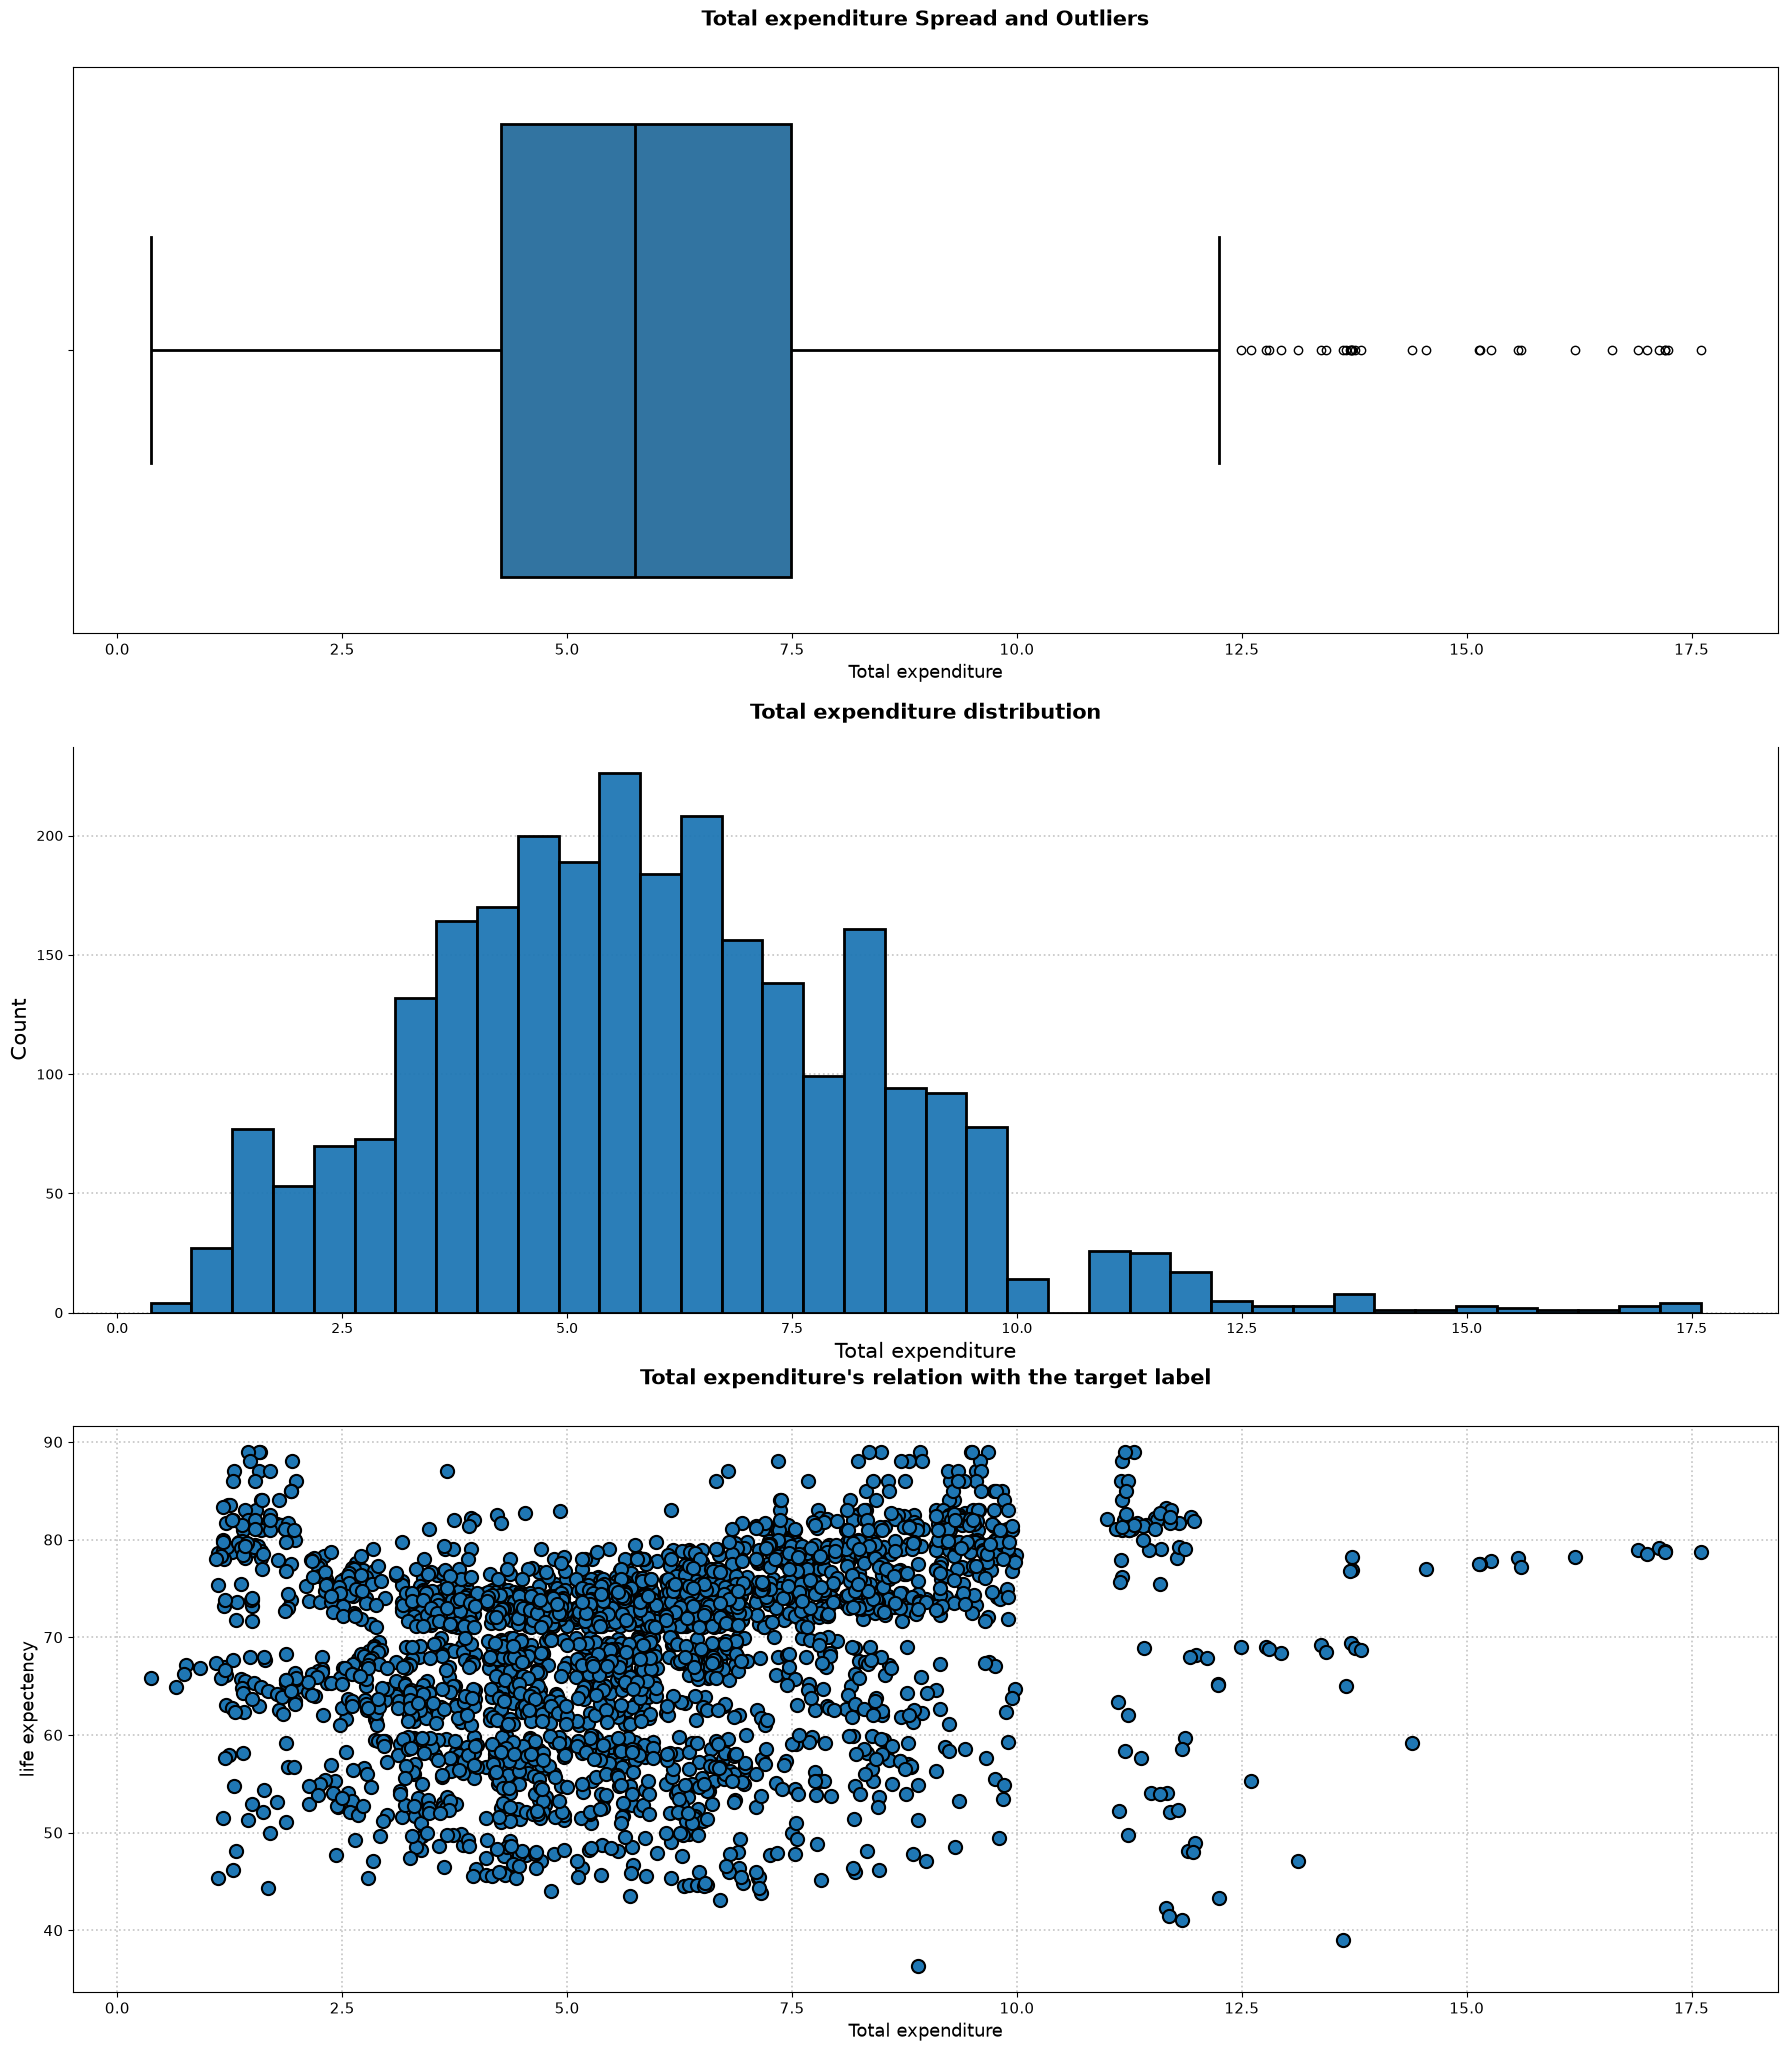


************************************************************************************************************************************



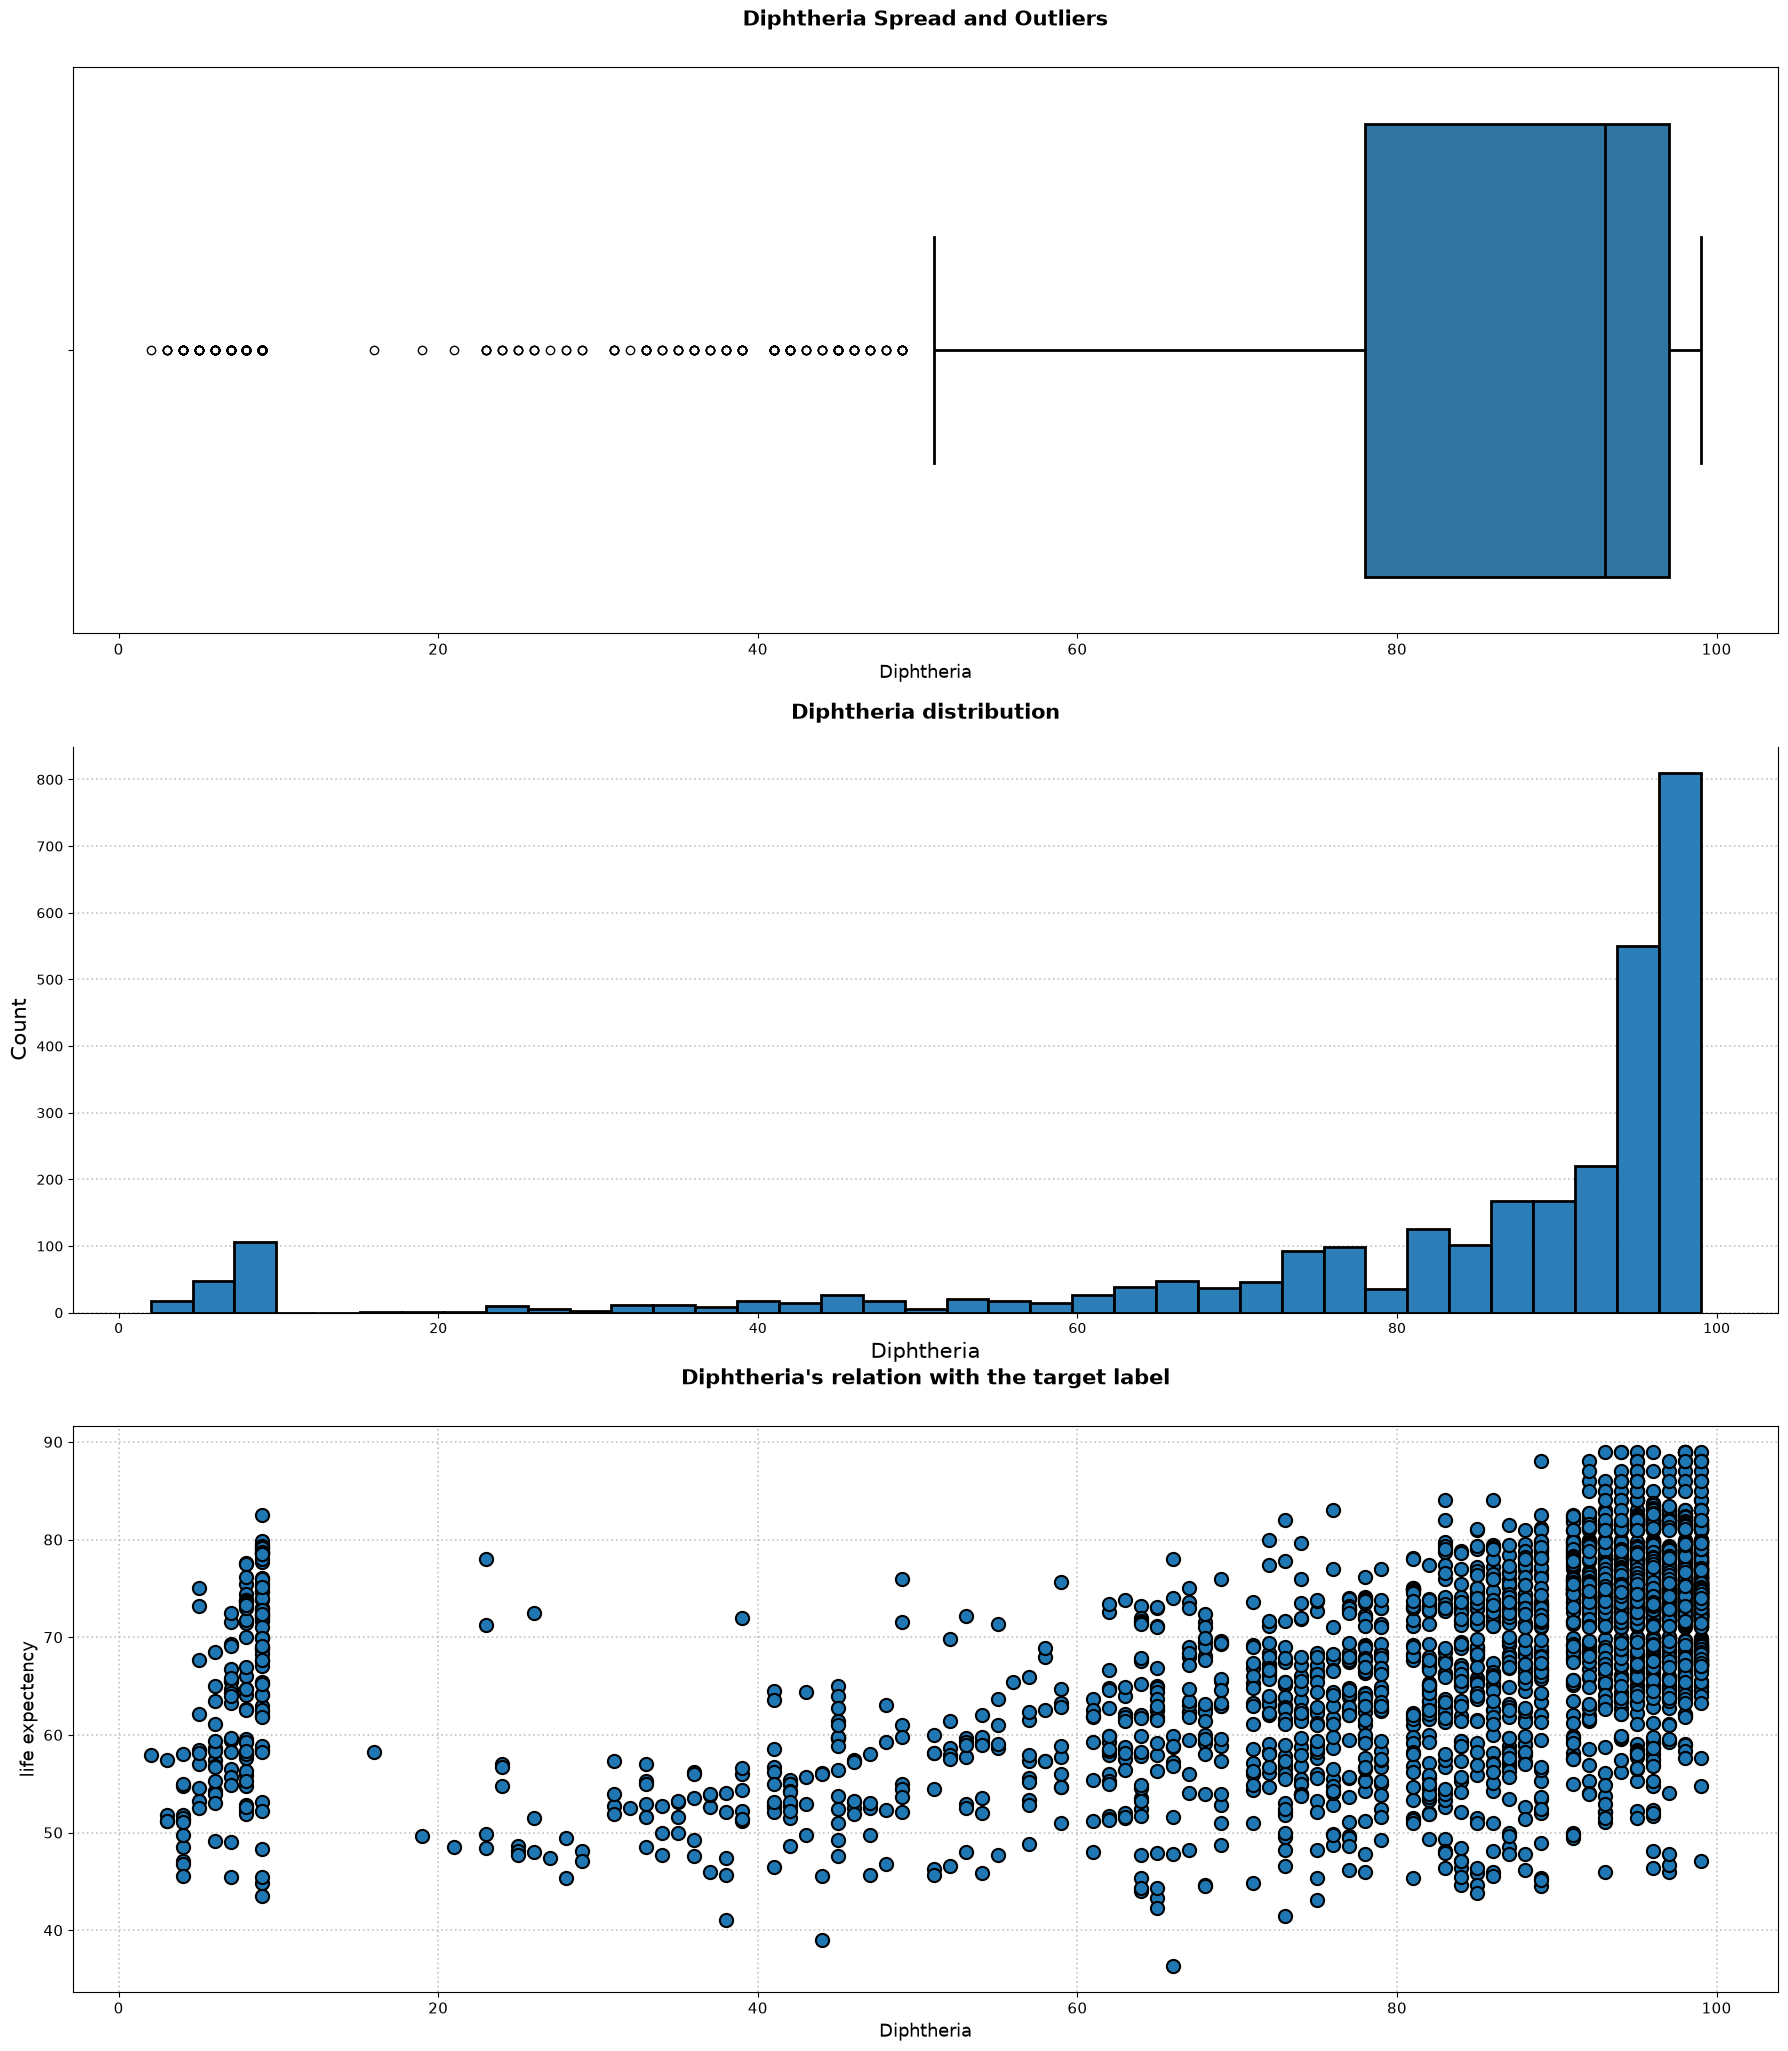


************************************************************************************************************************************



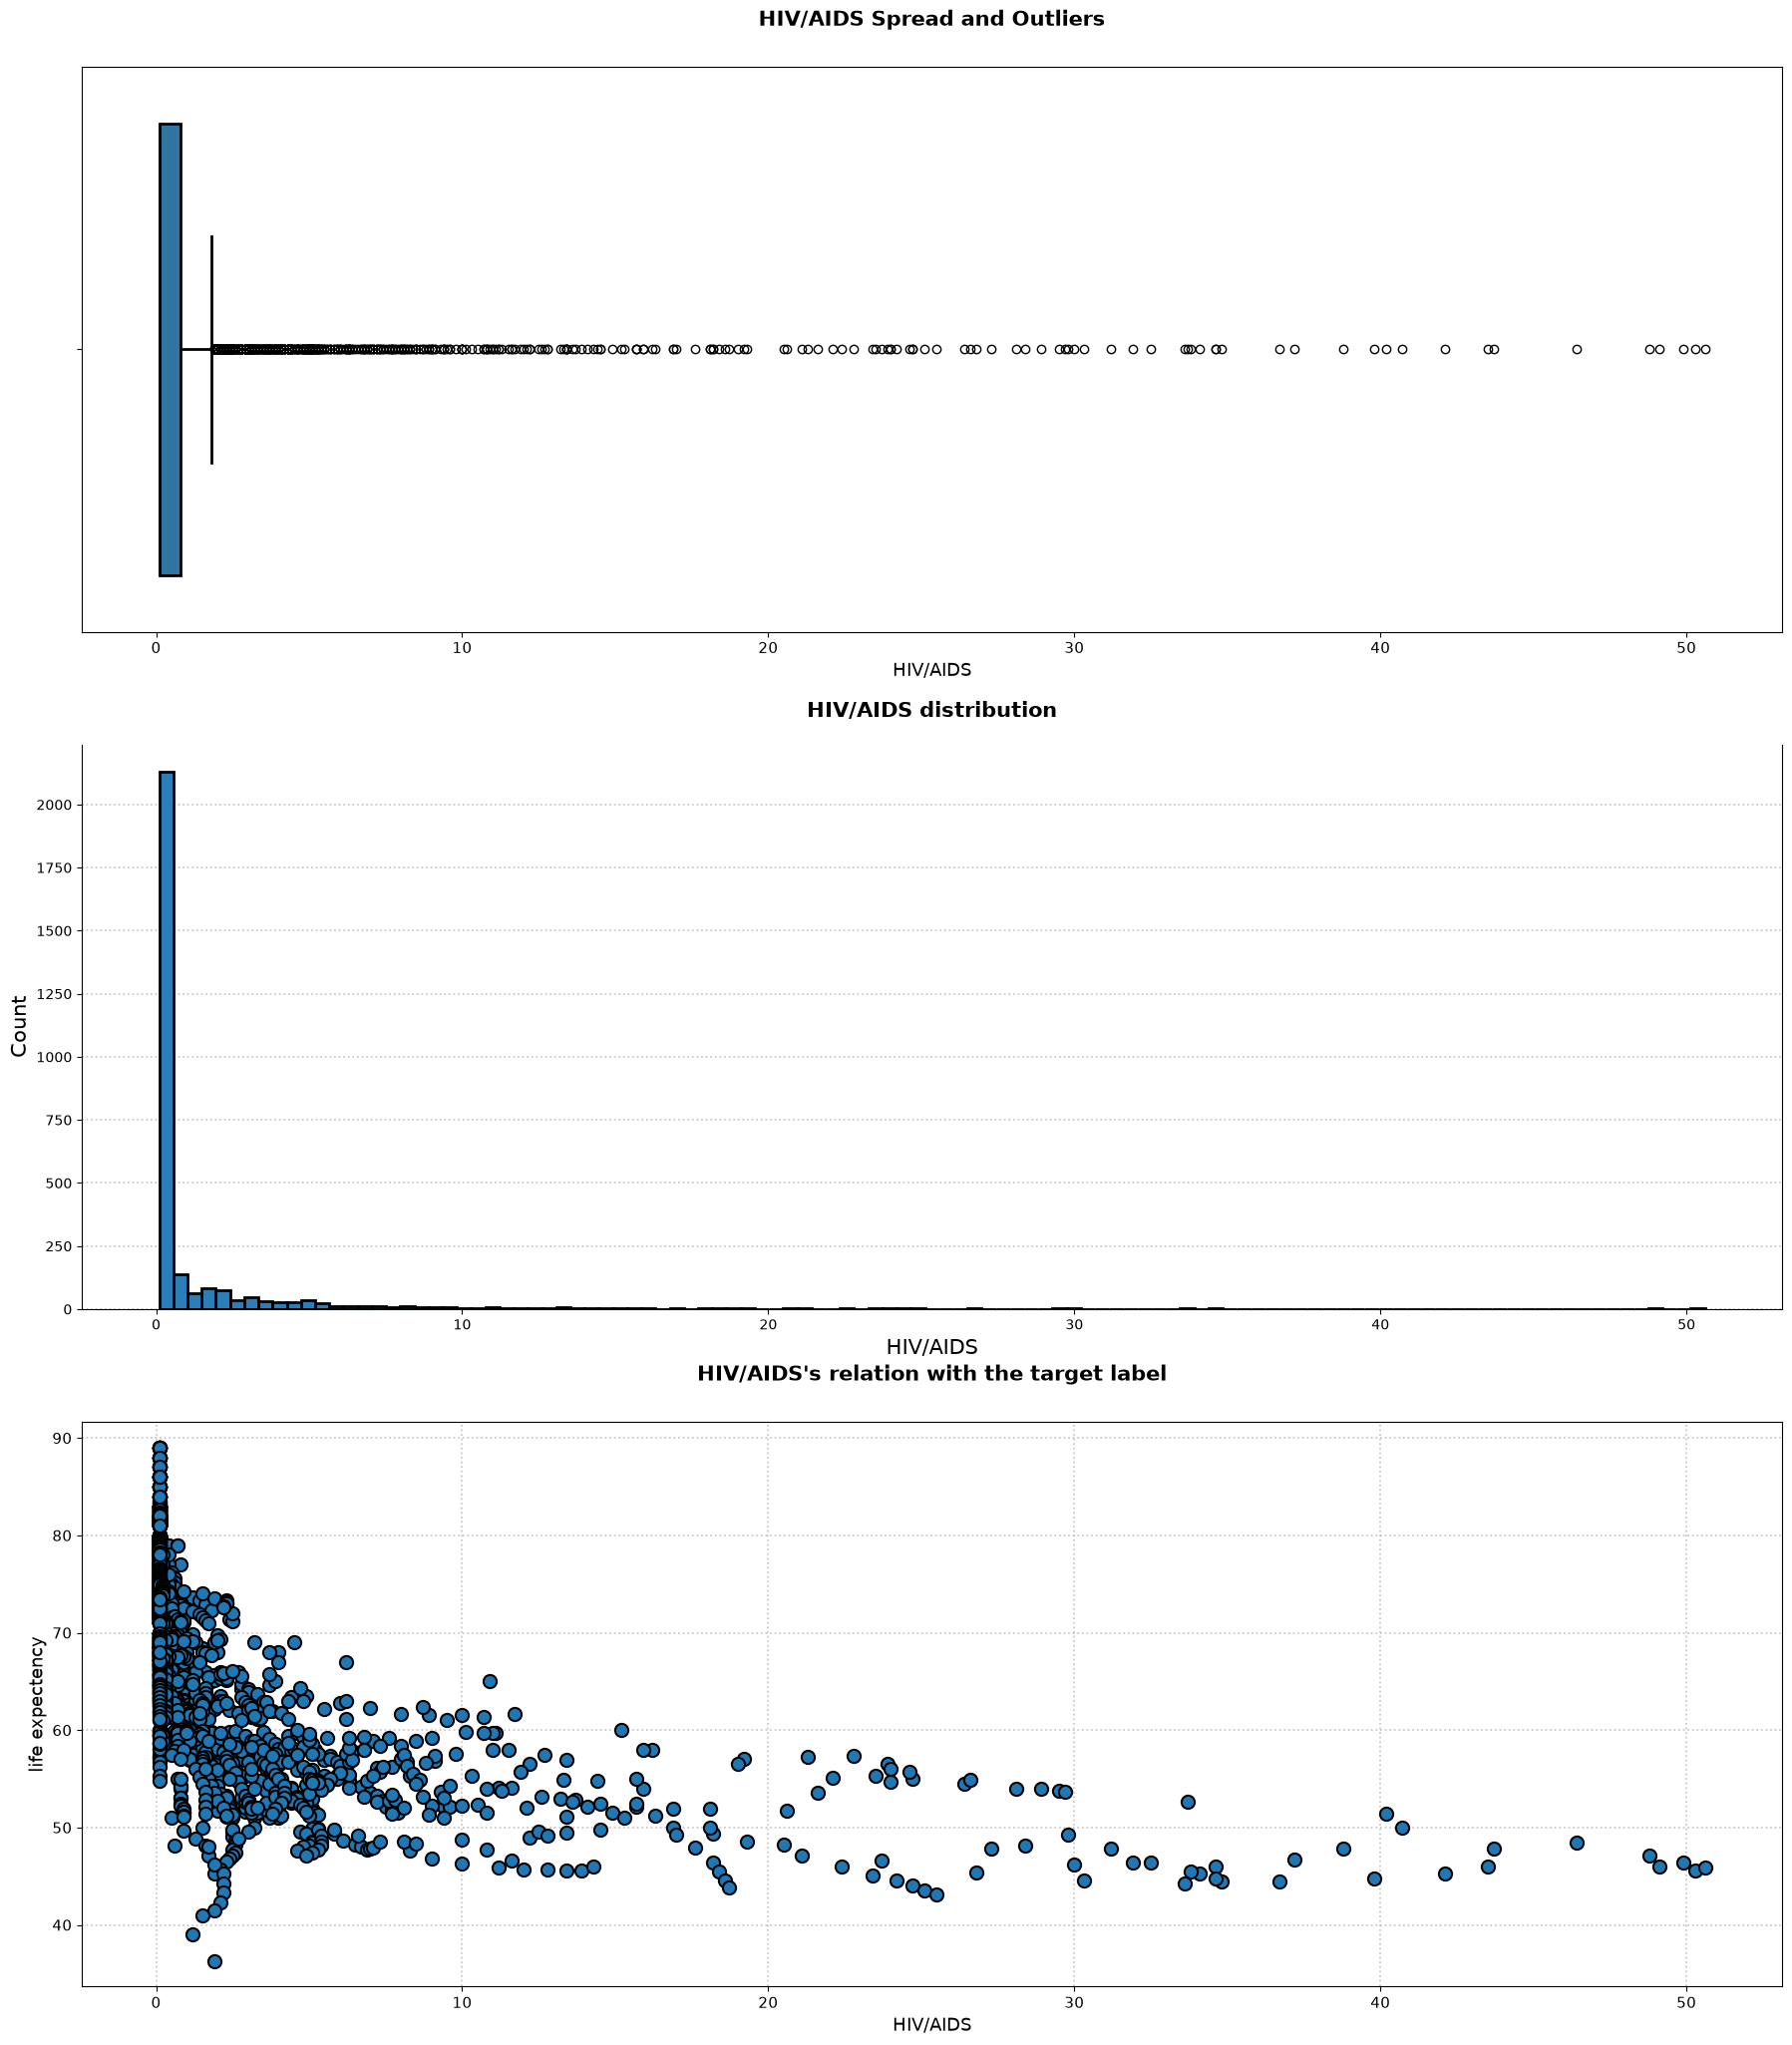


************************************************************************************************************************************



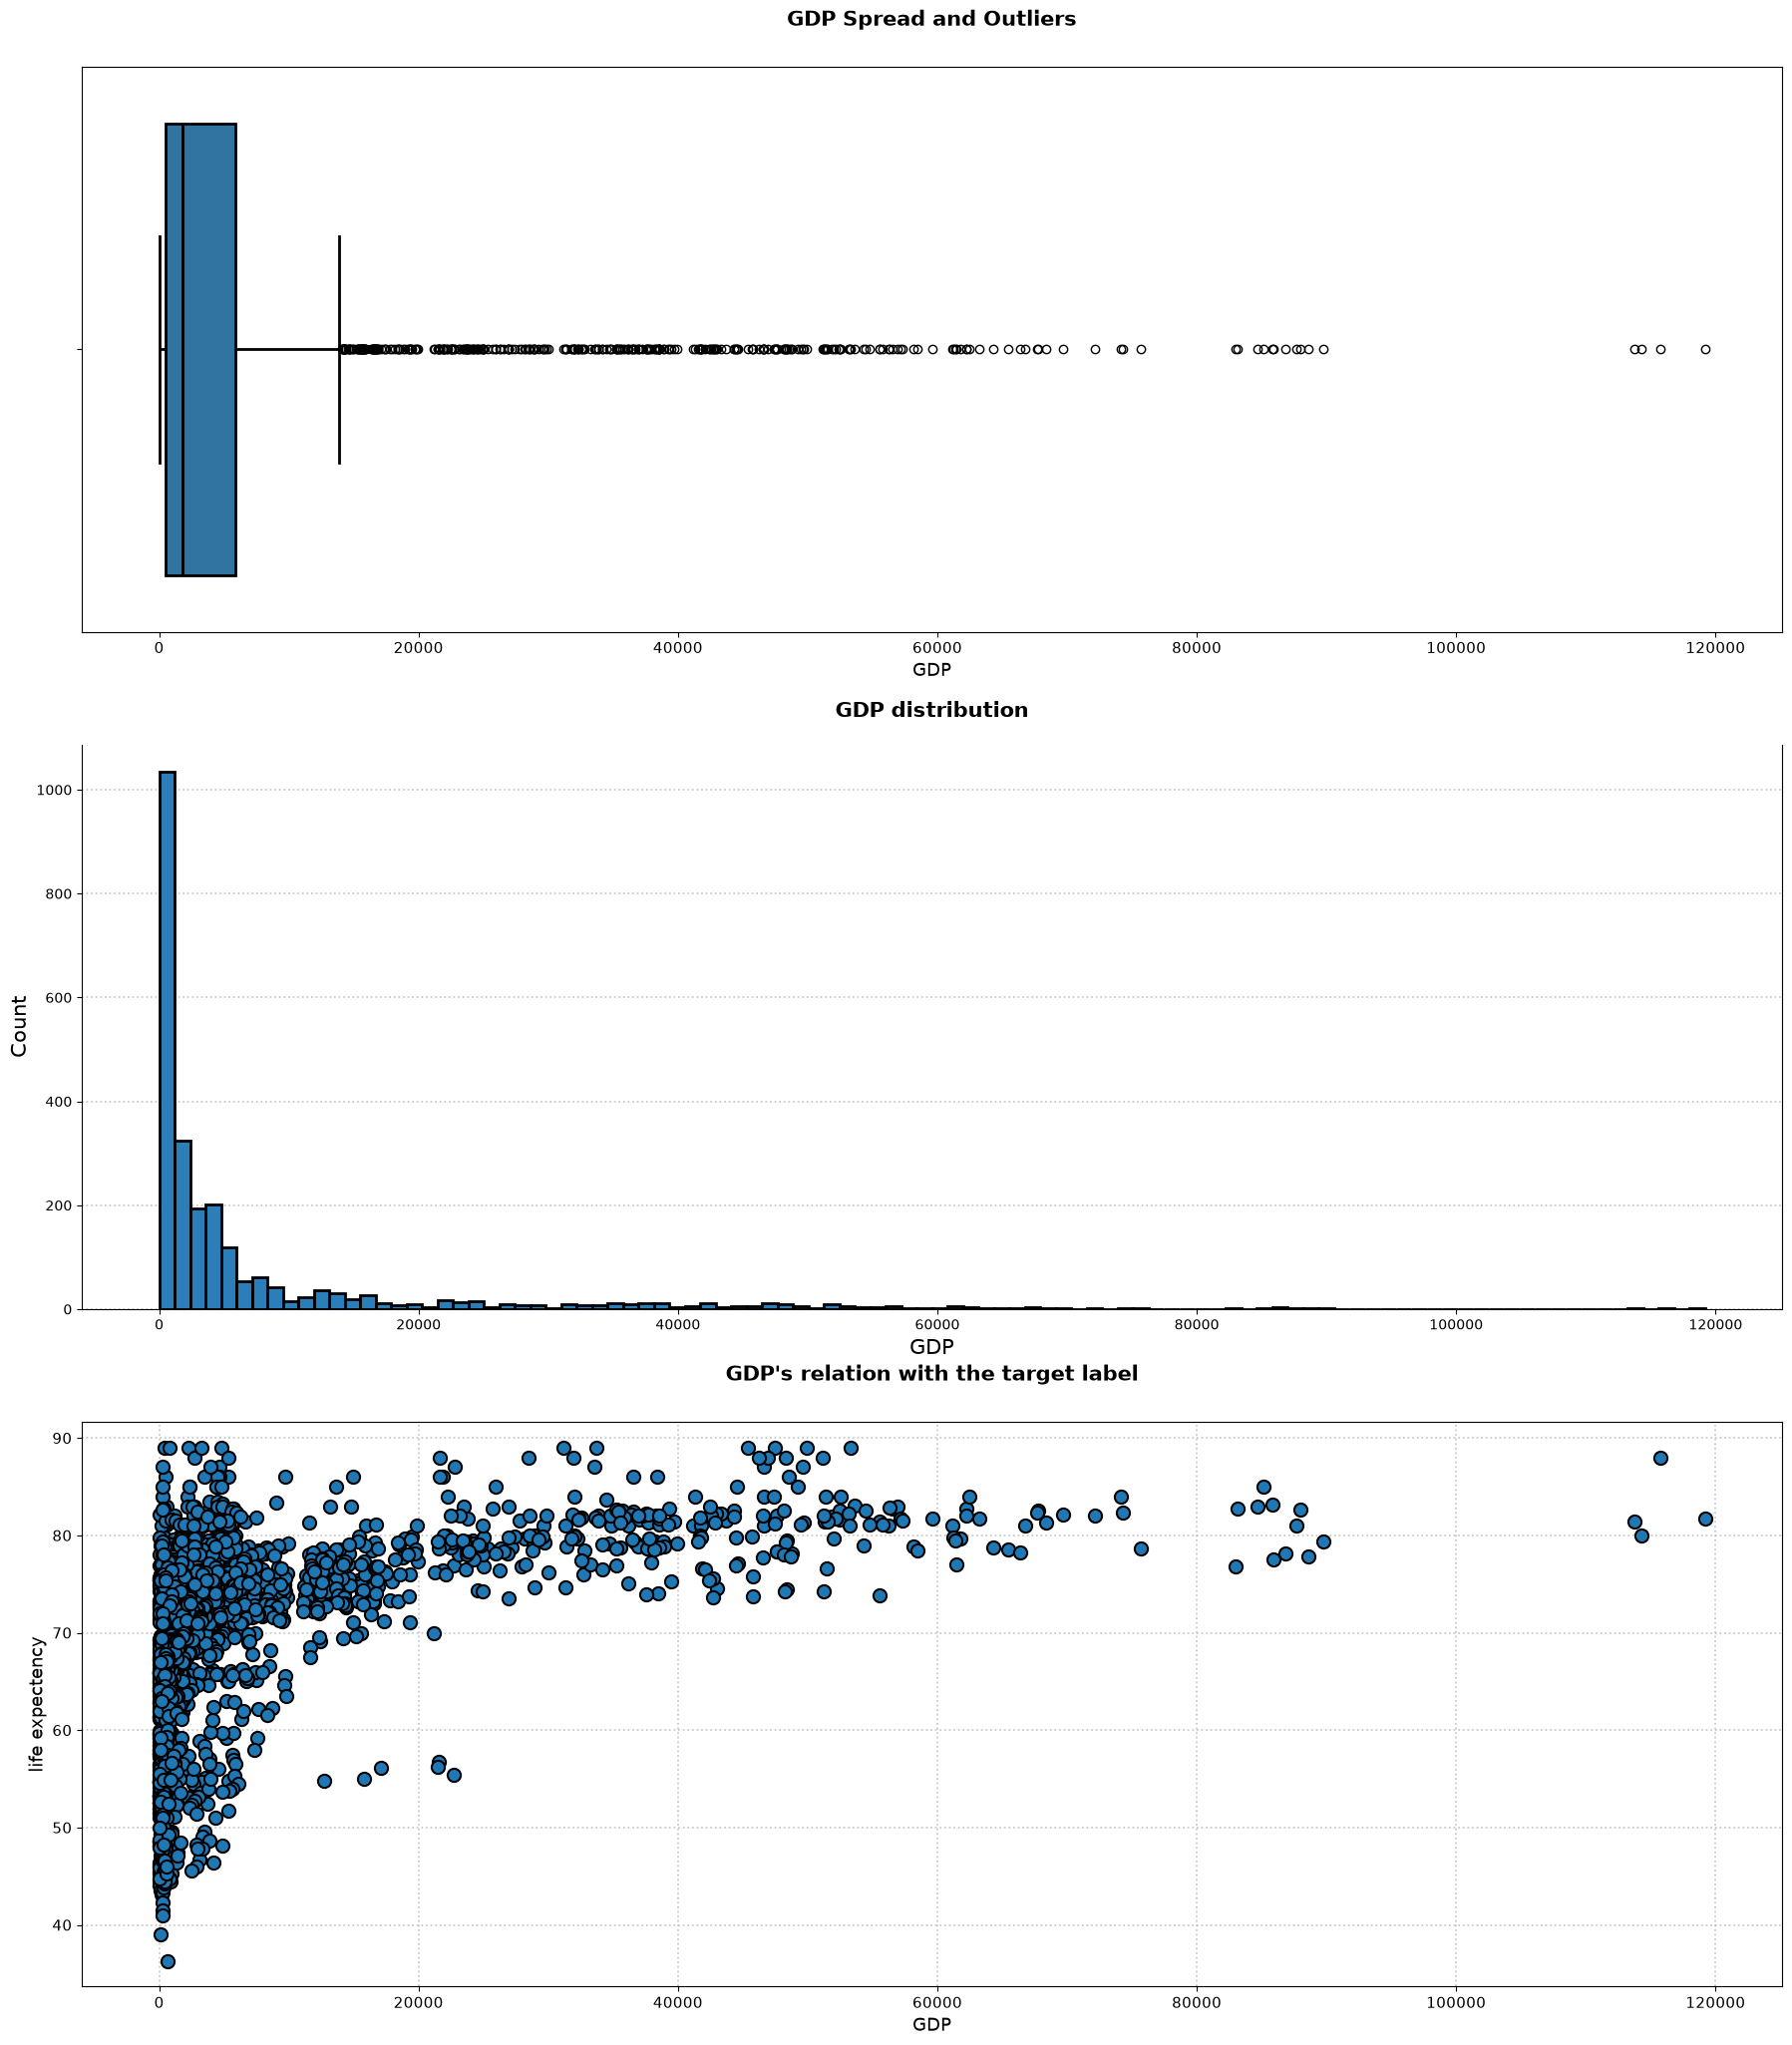


************************************************************************************************************************************



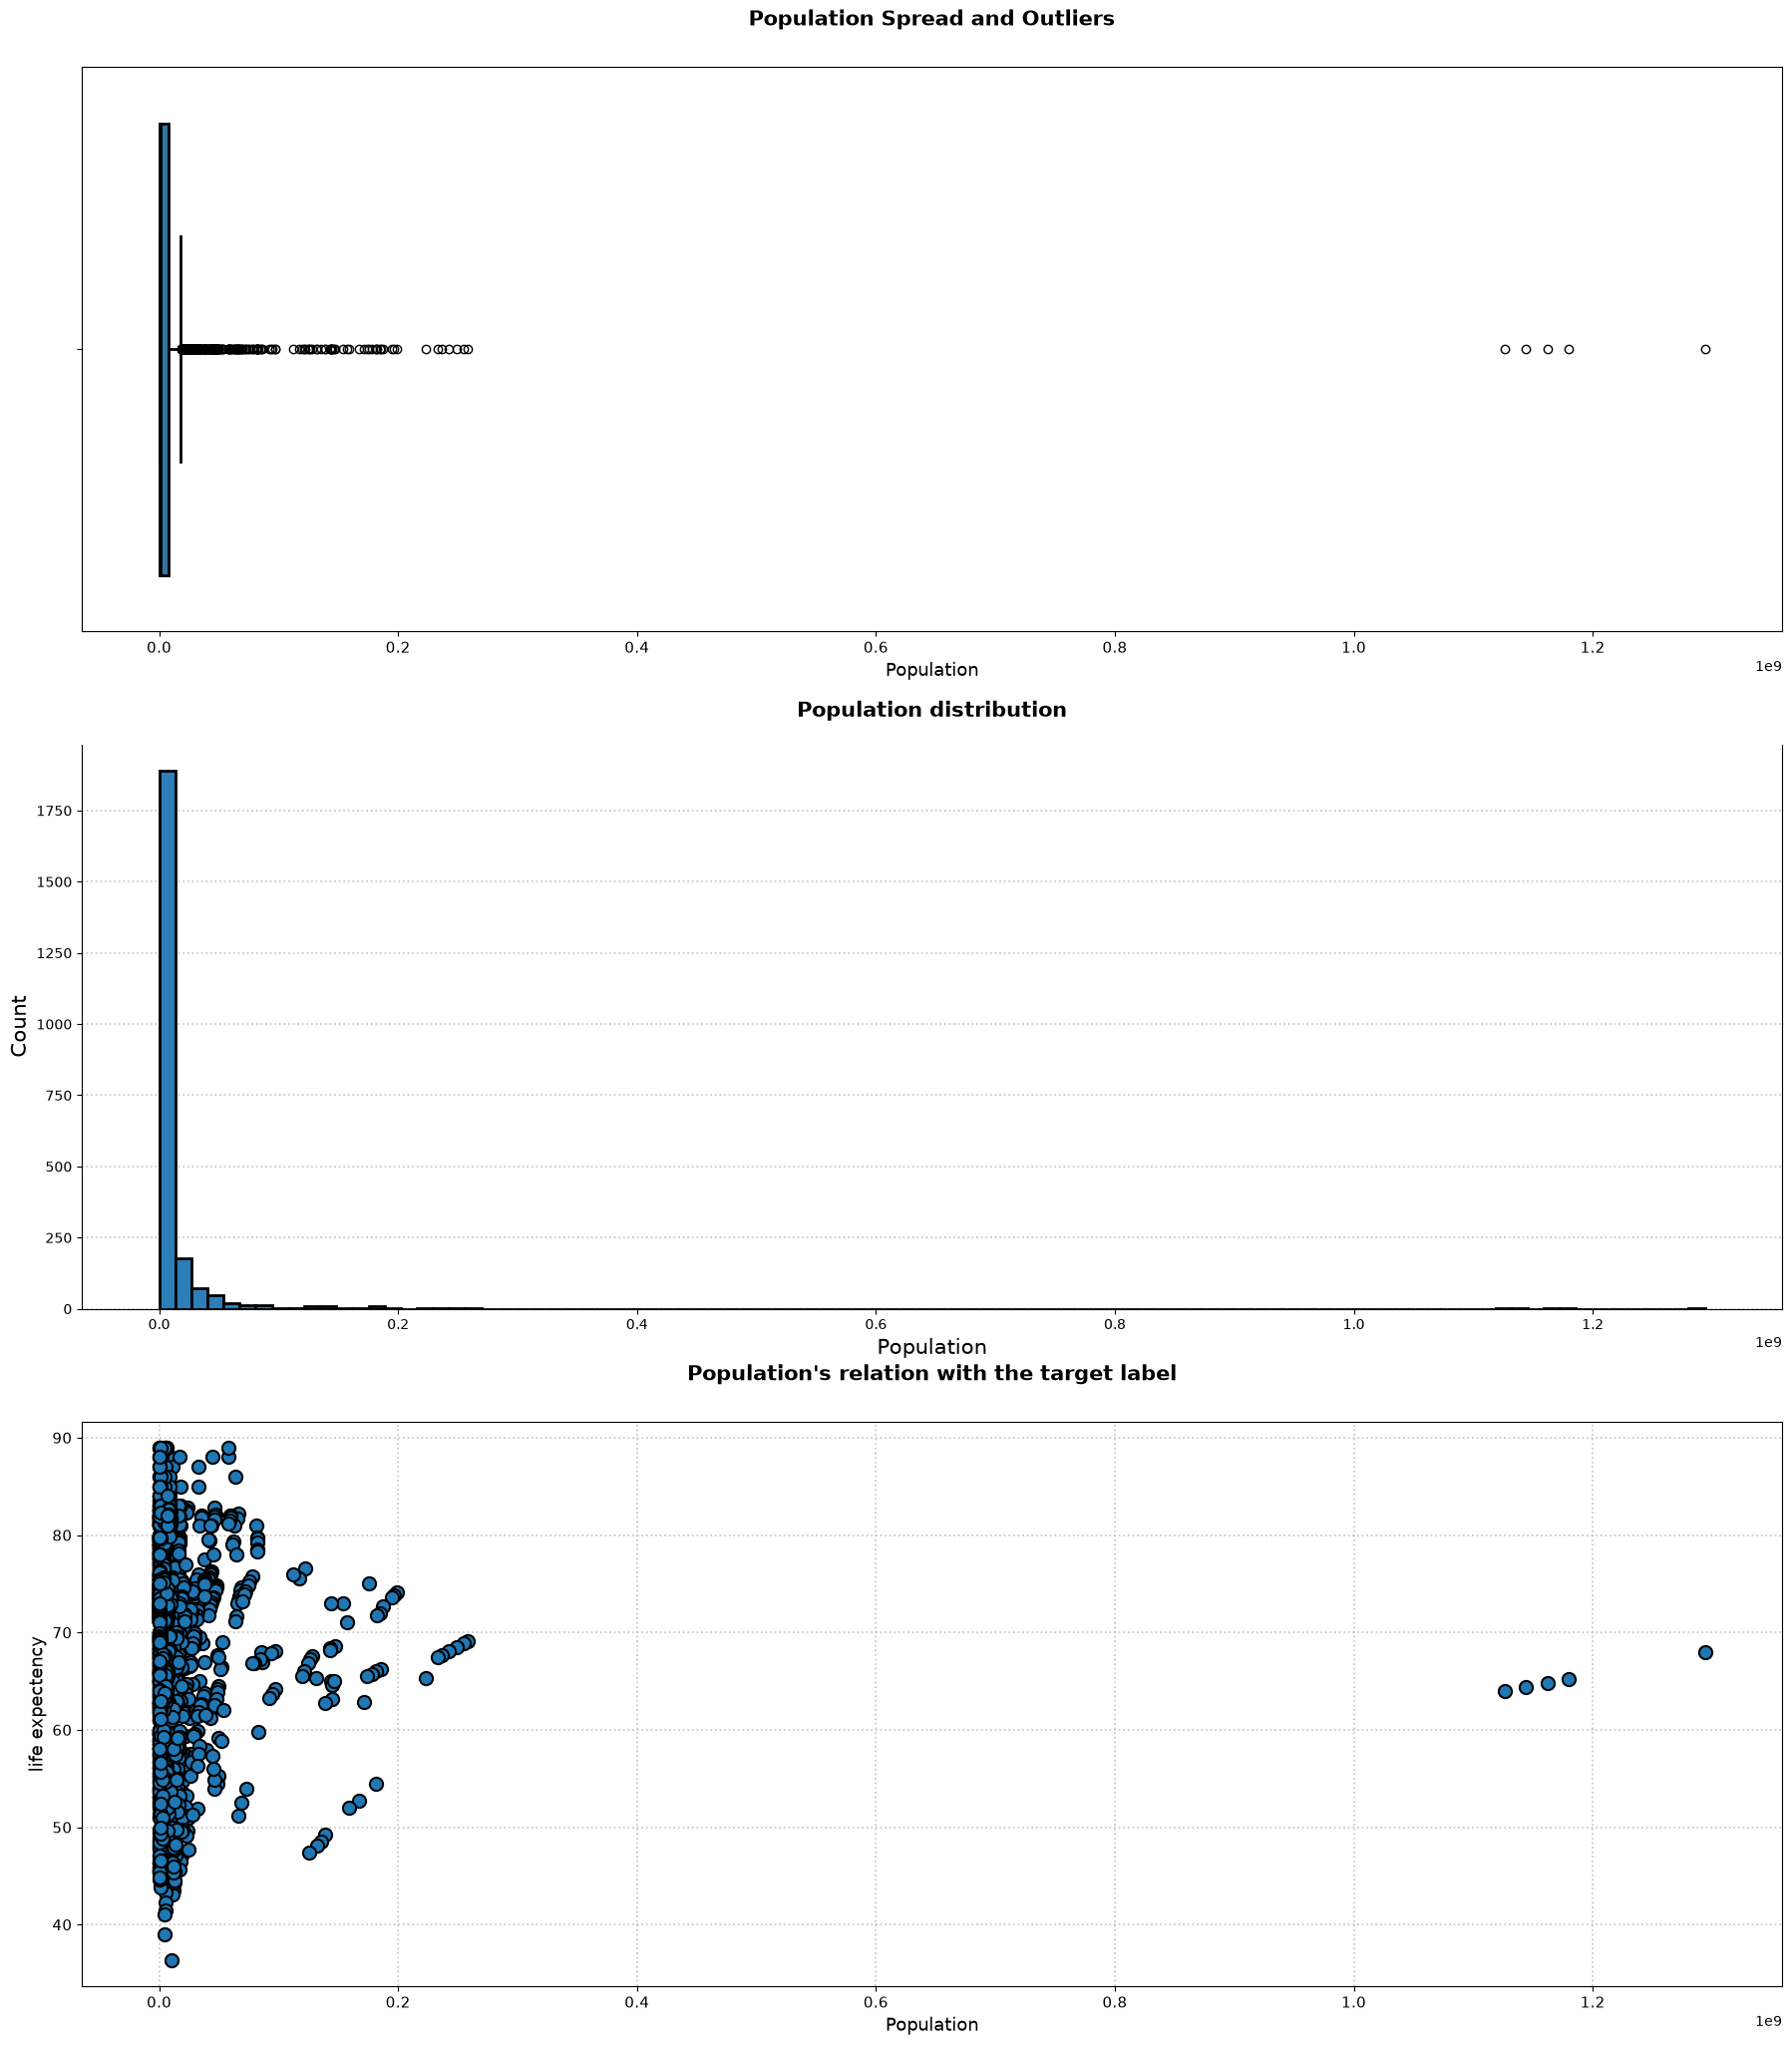


************************************************************************************************************************************



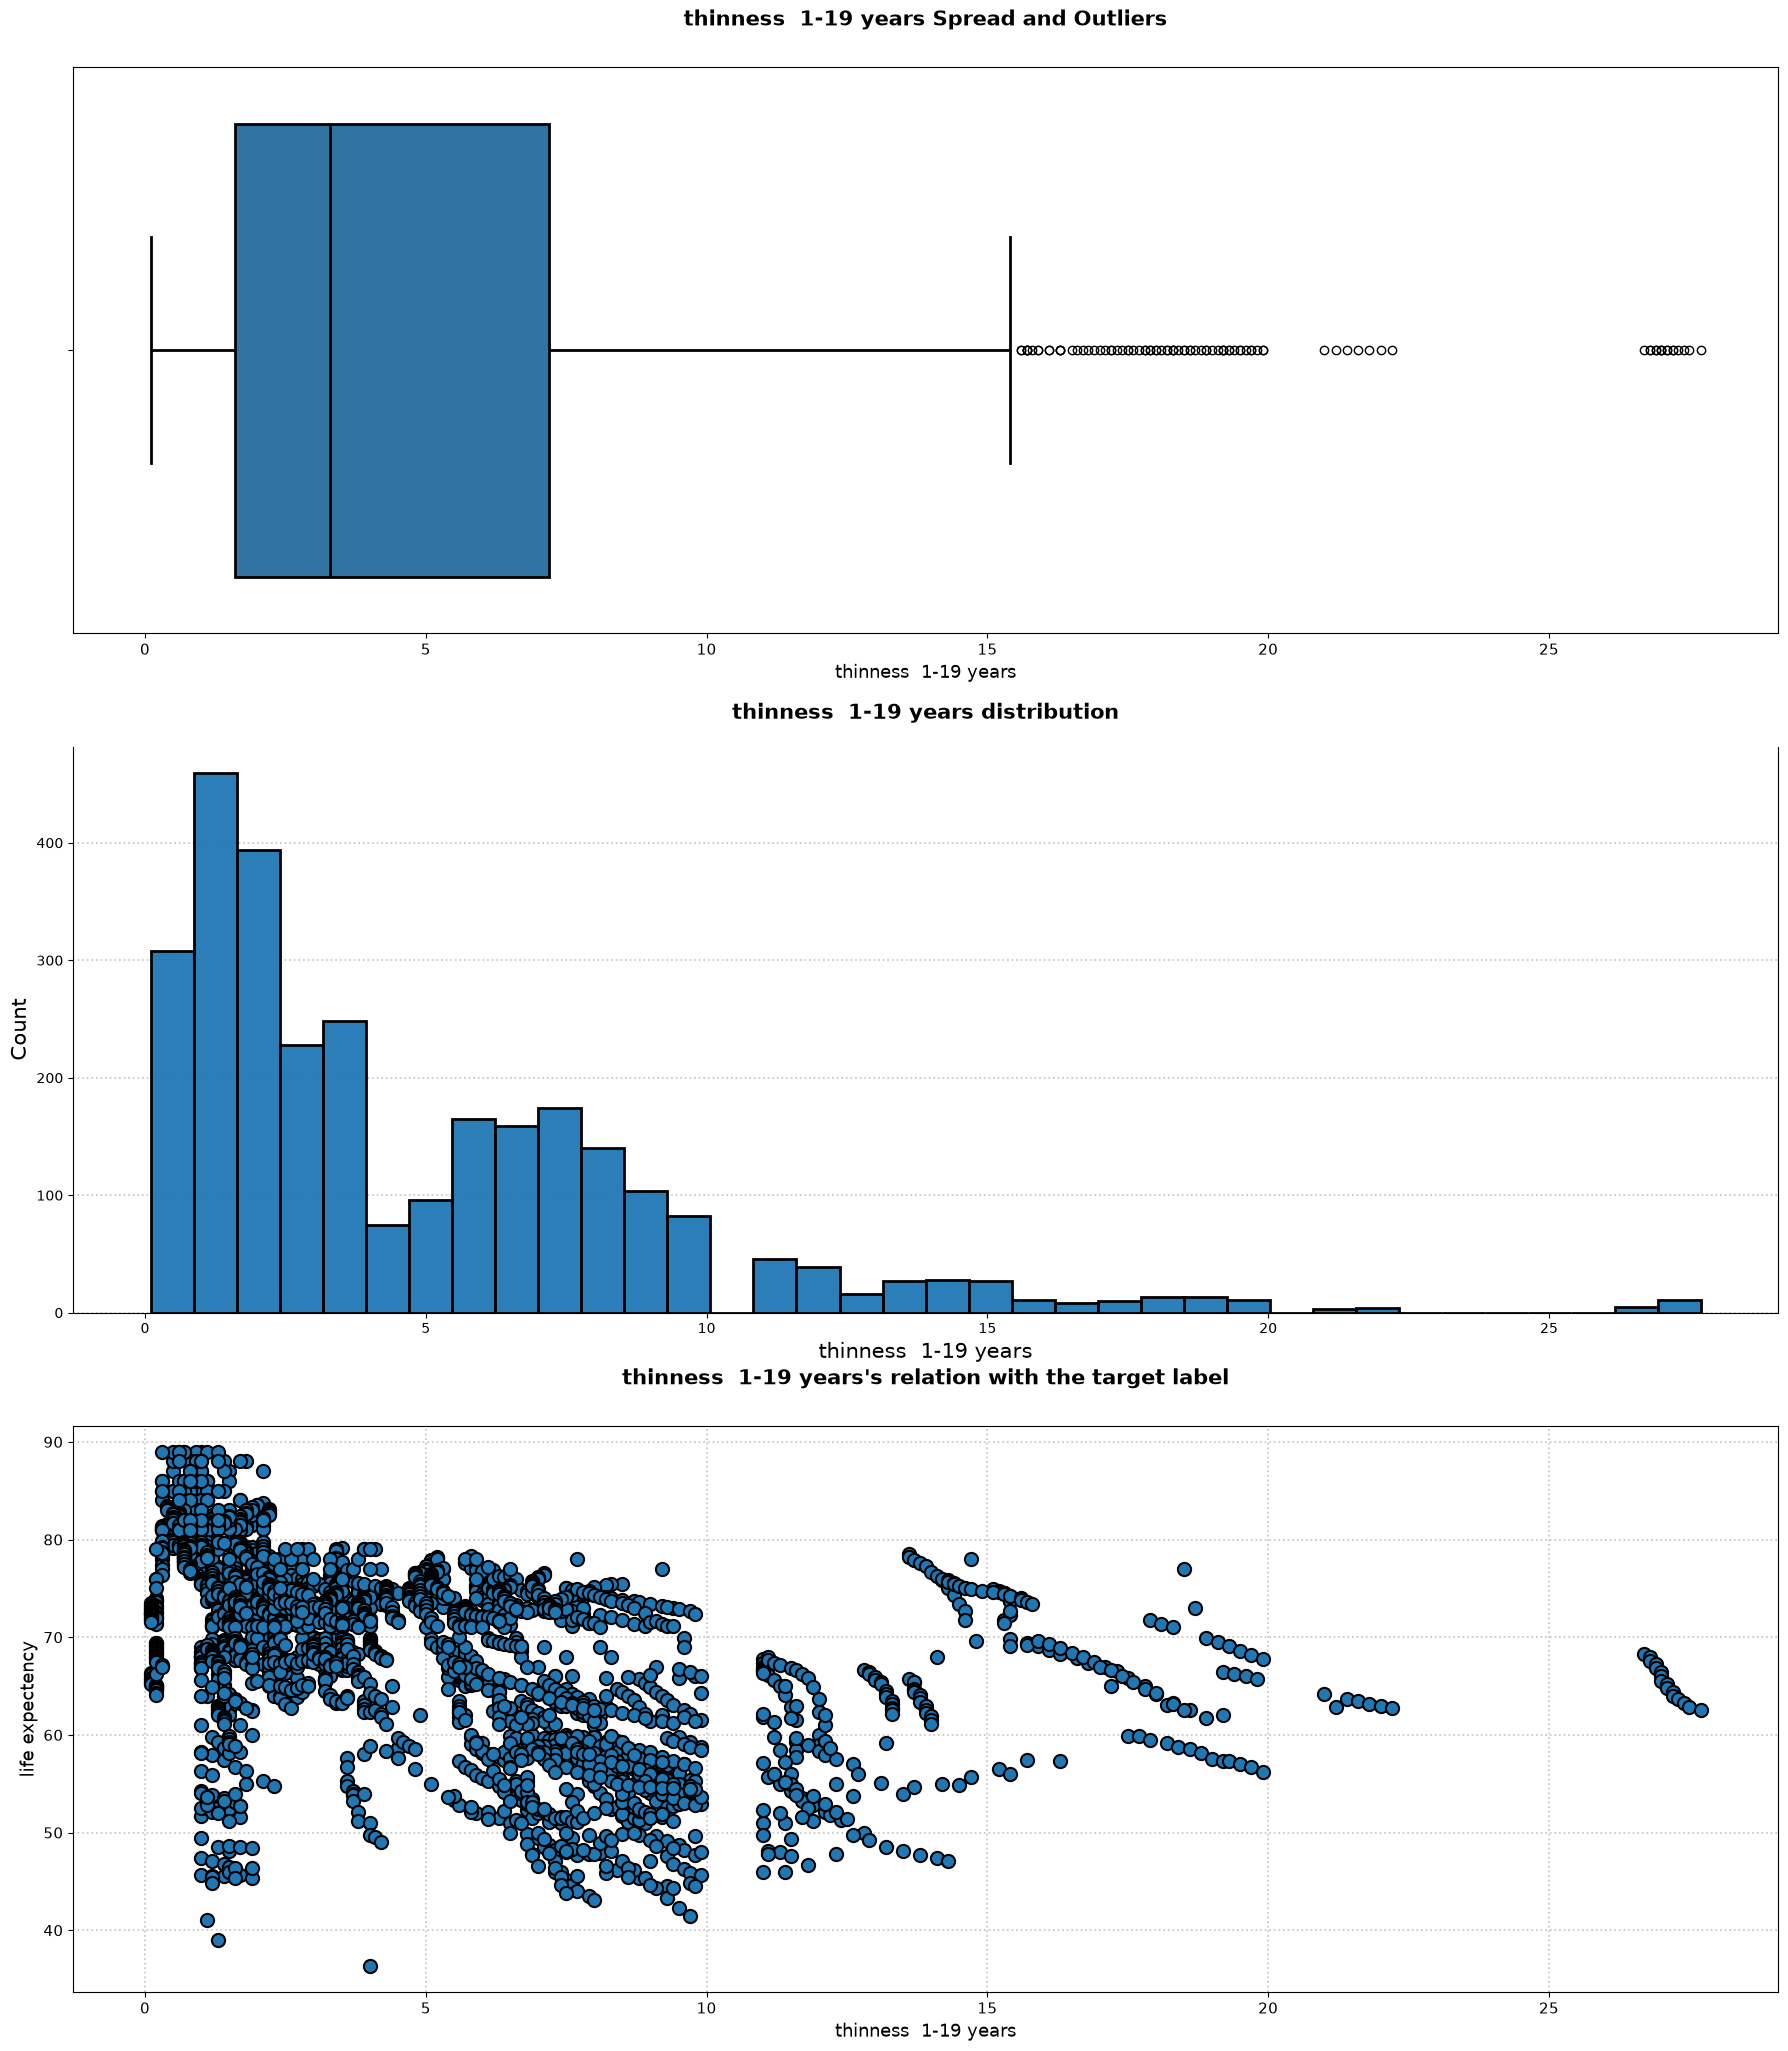


************************************************************************************************************************************



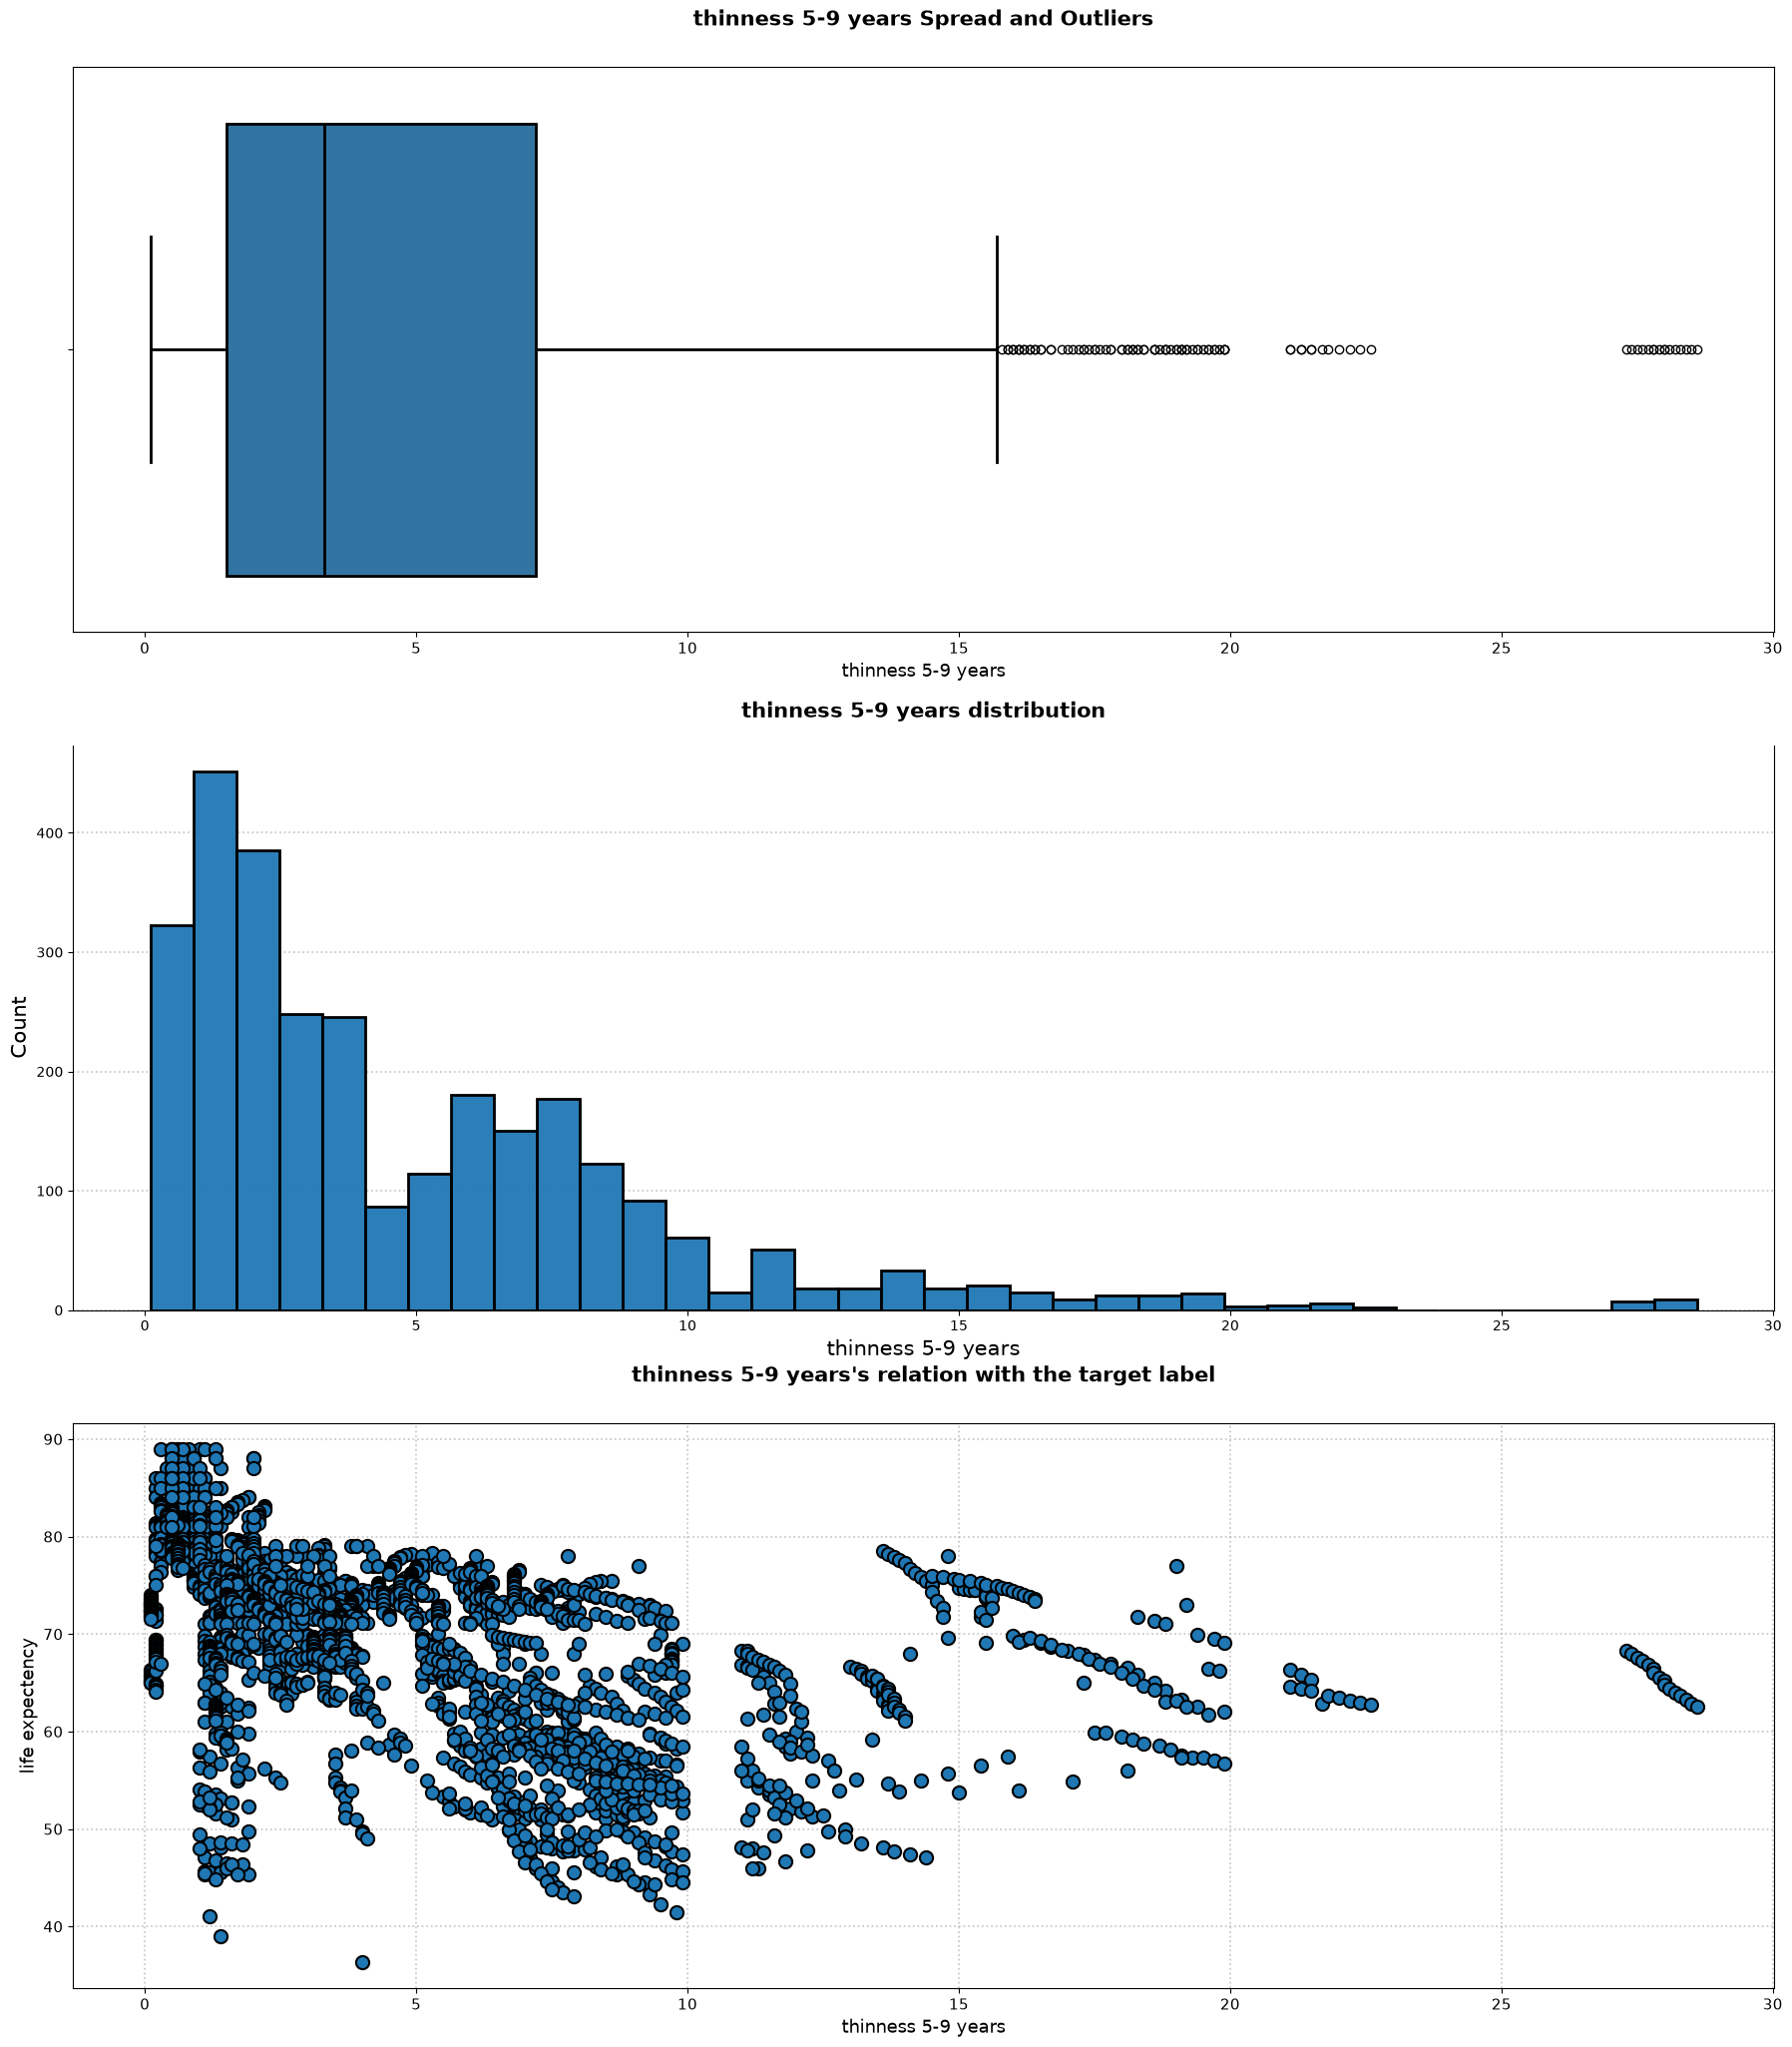


************************************************************************************************************************************



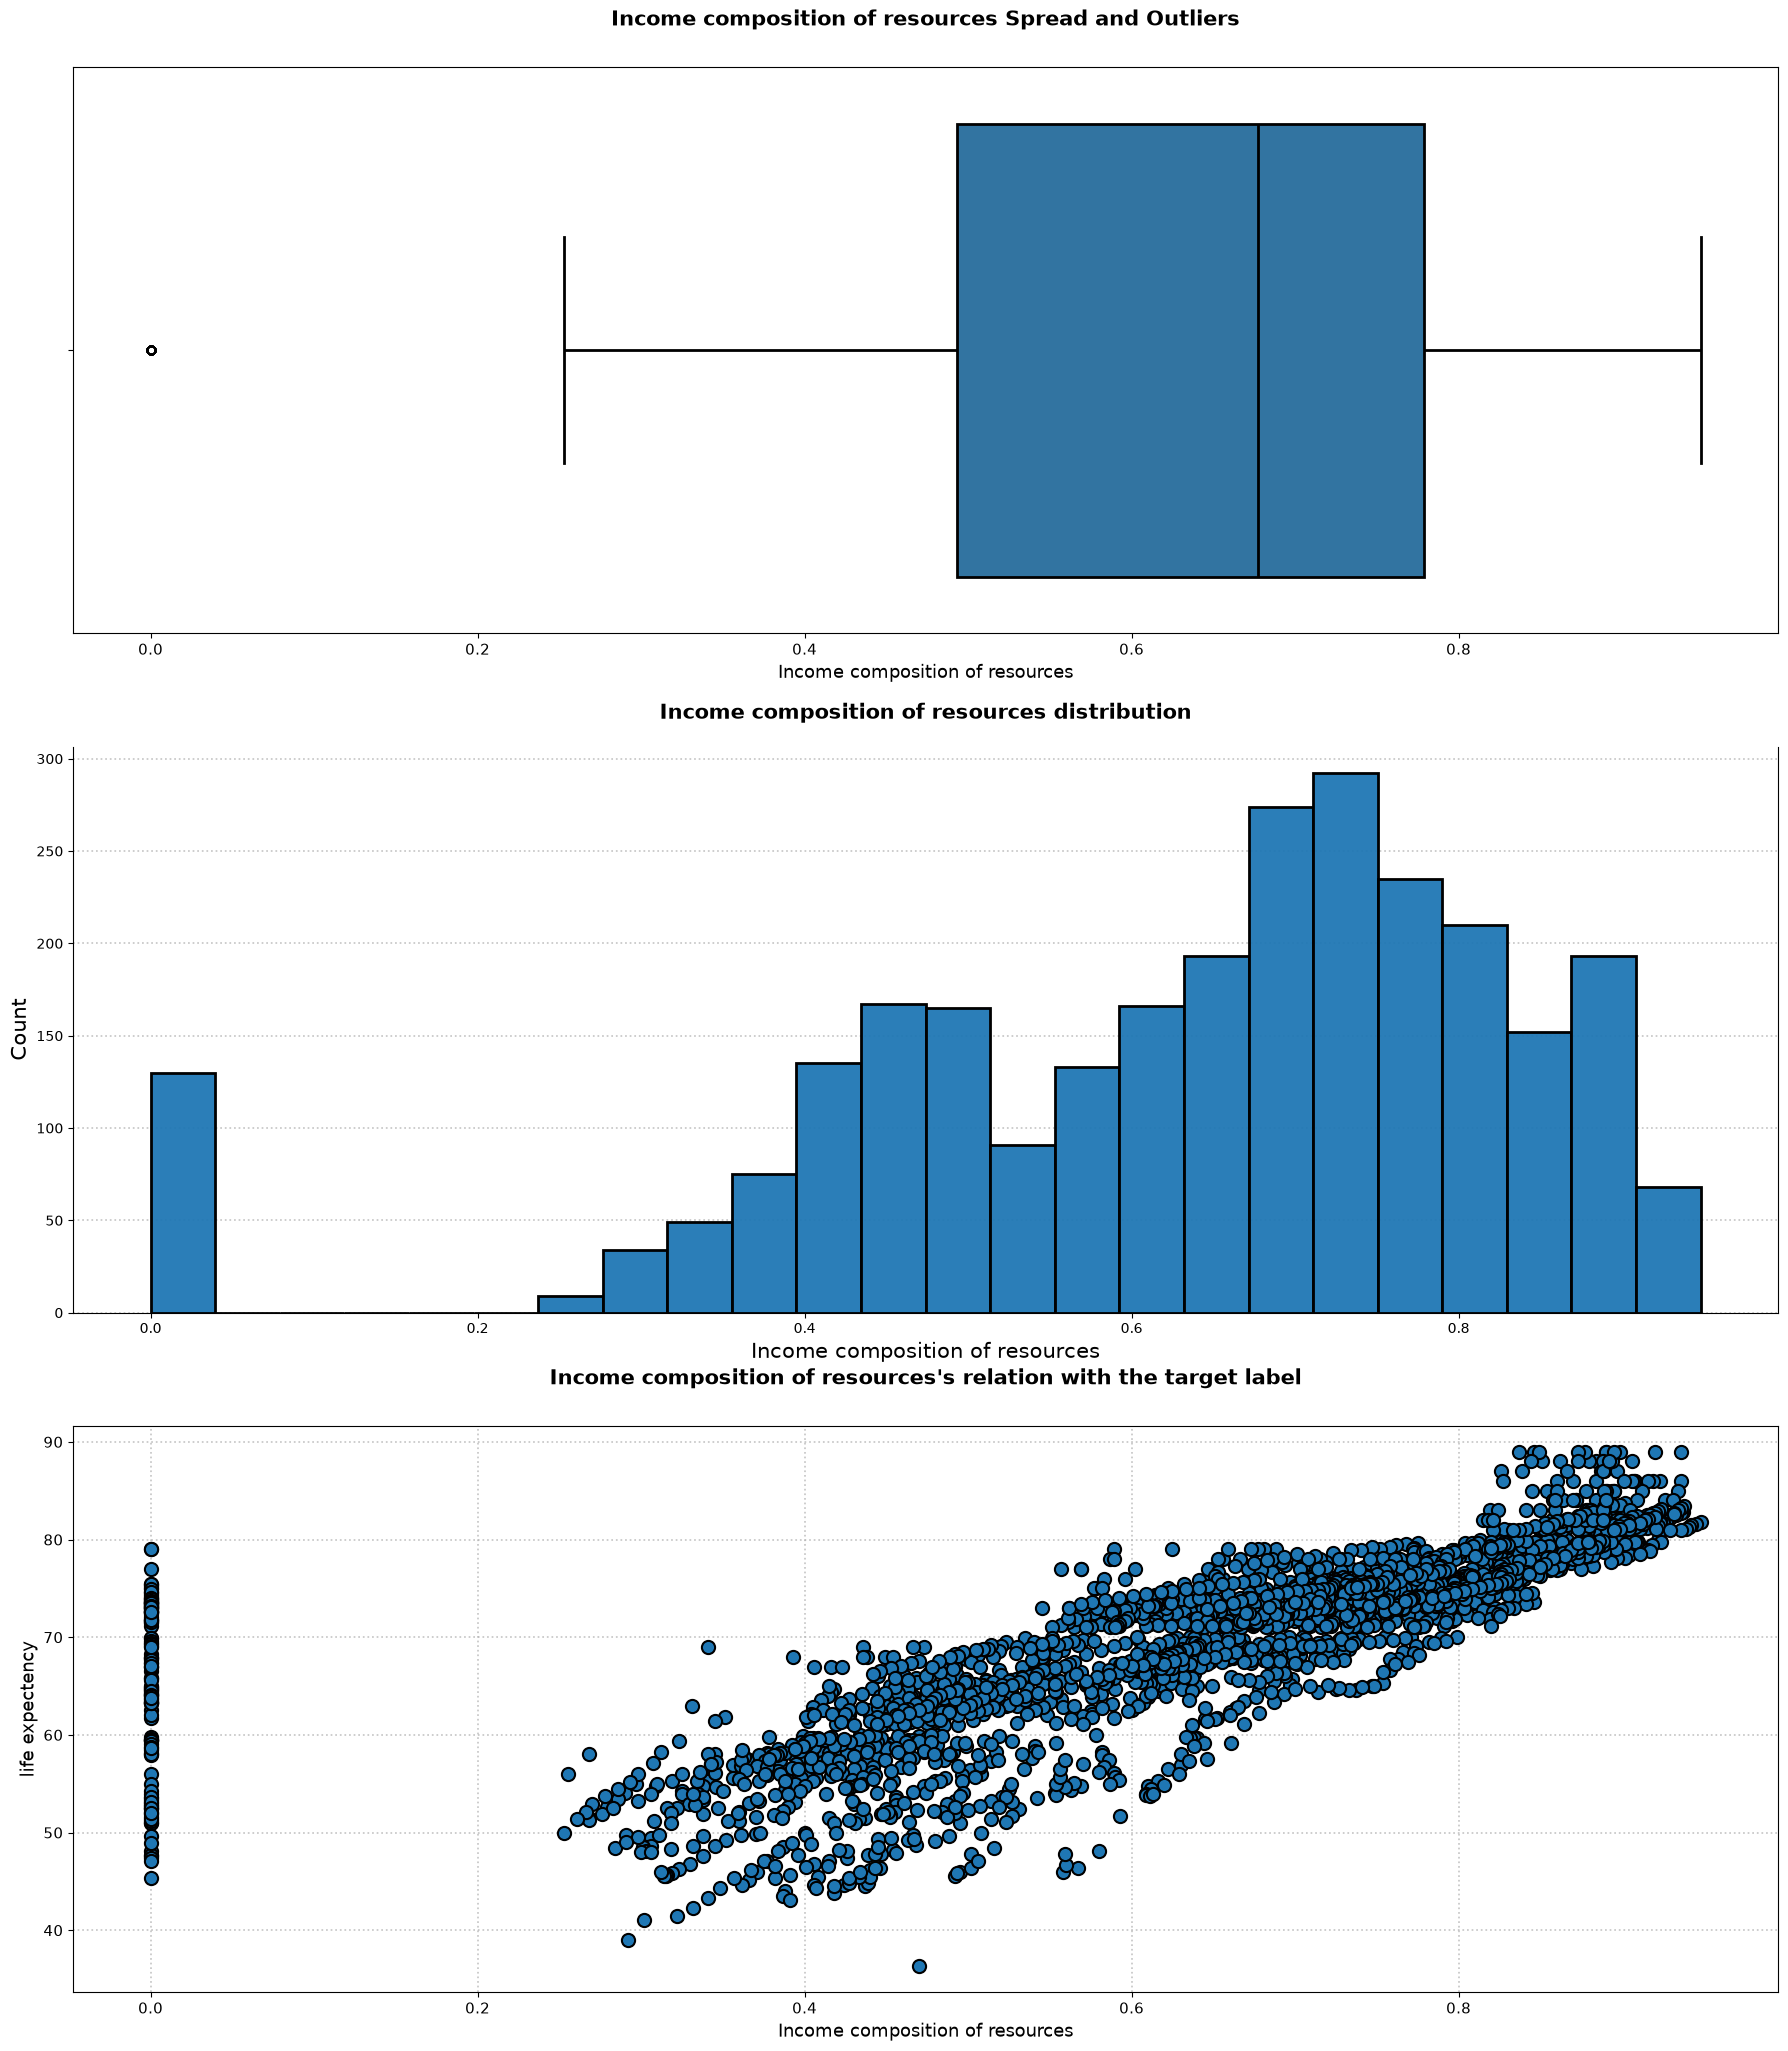


************************************************************************************************************************************



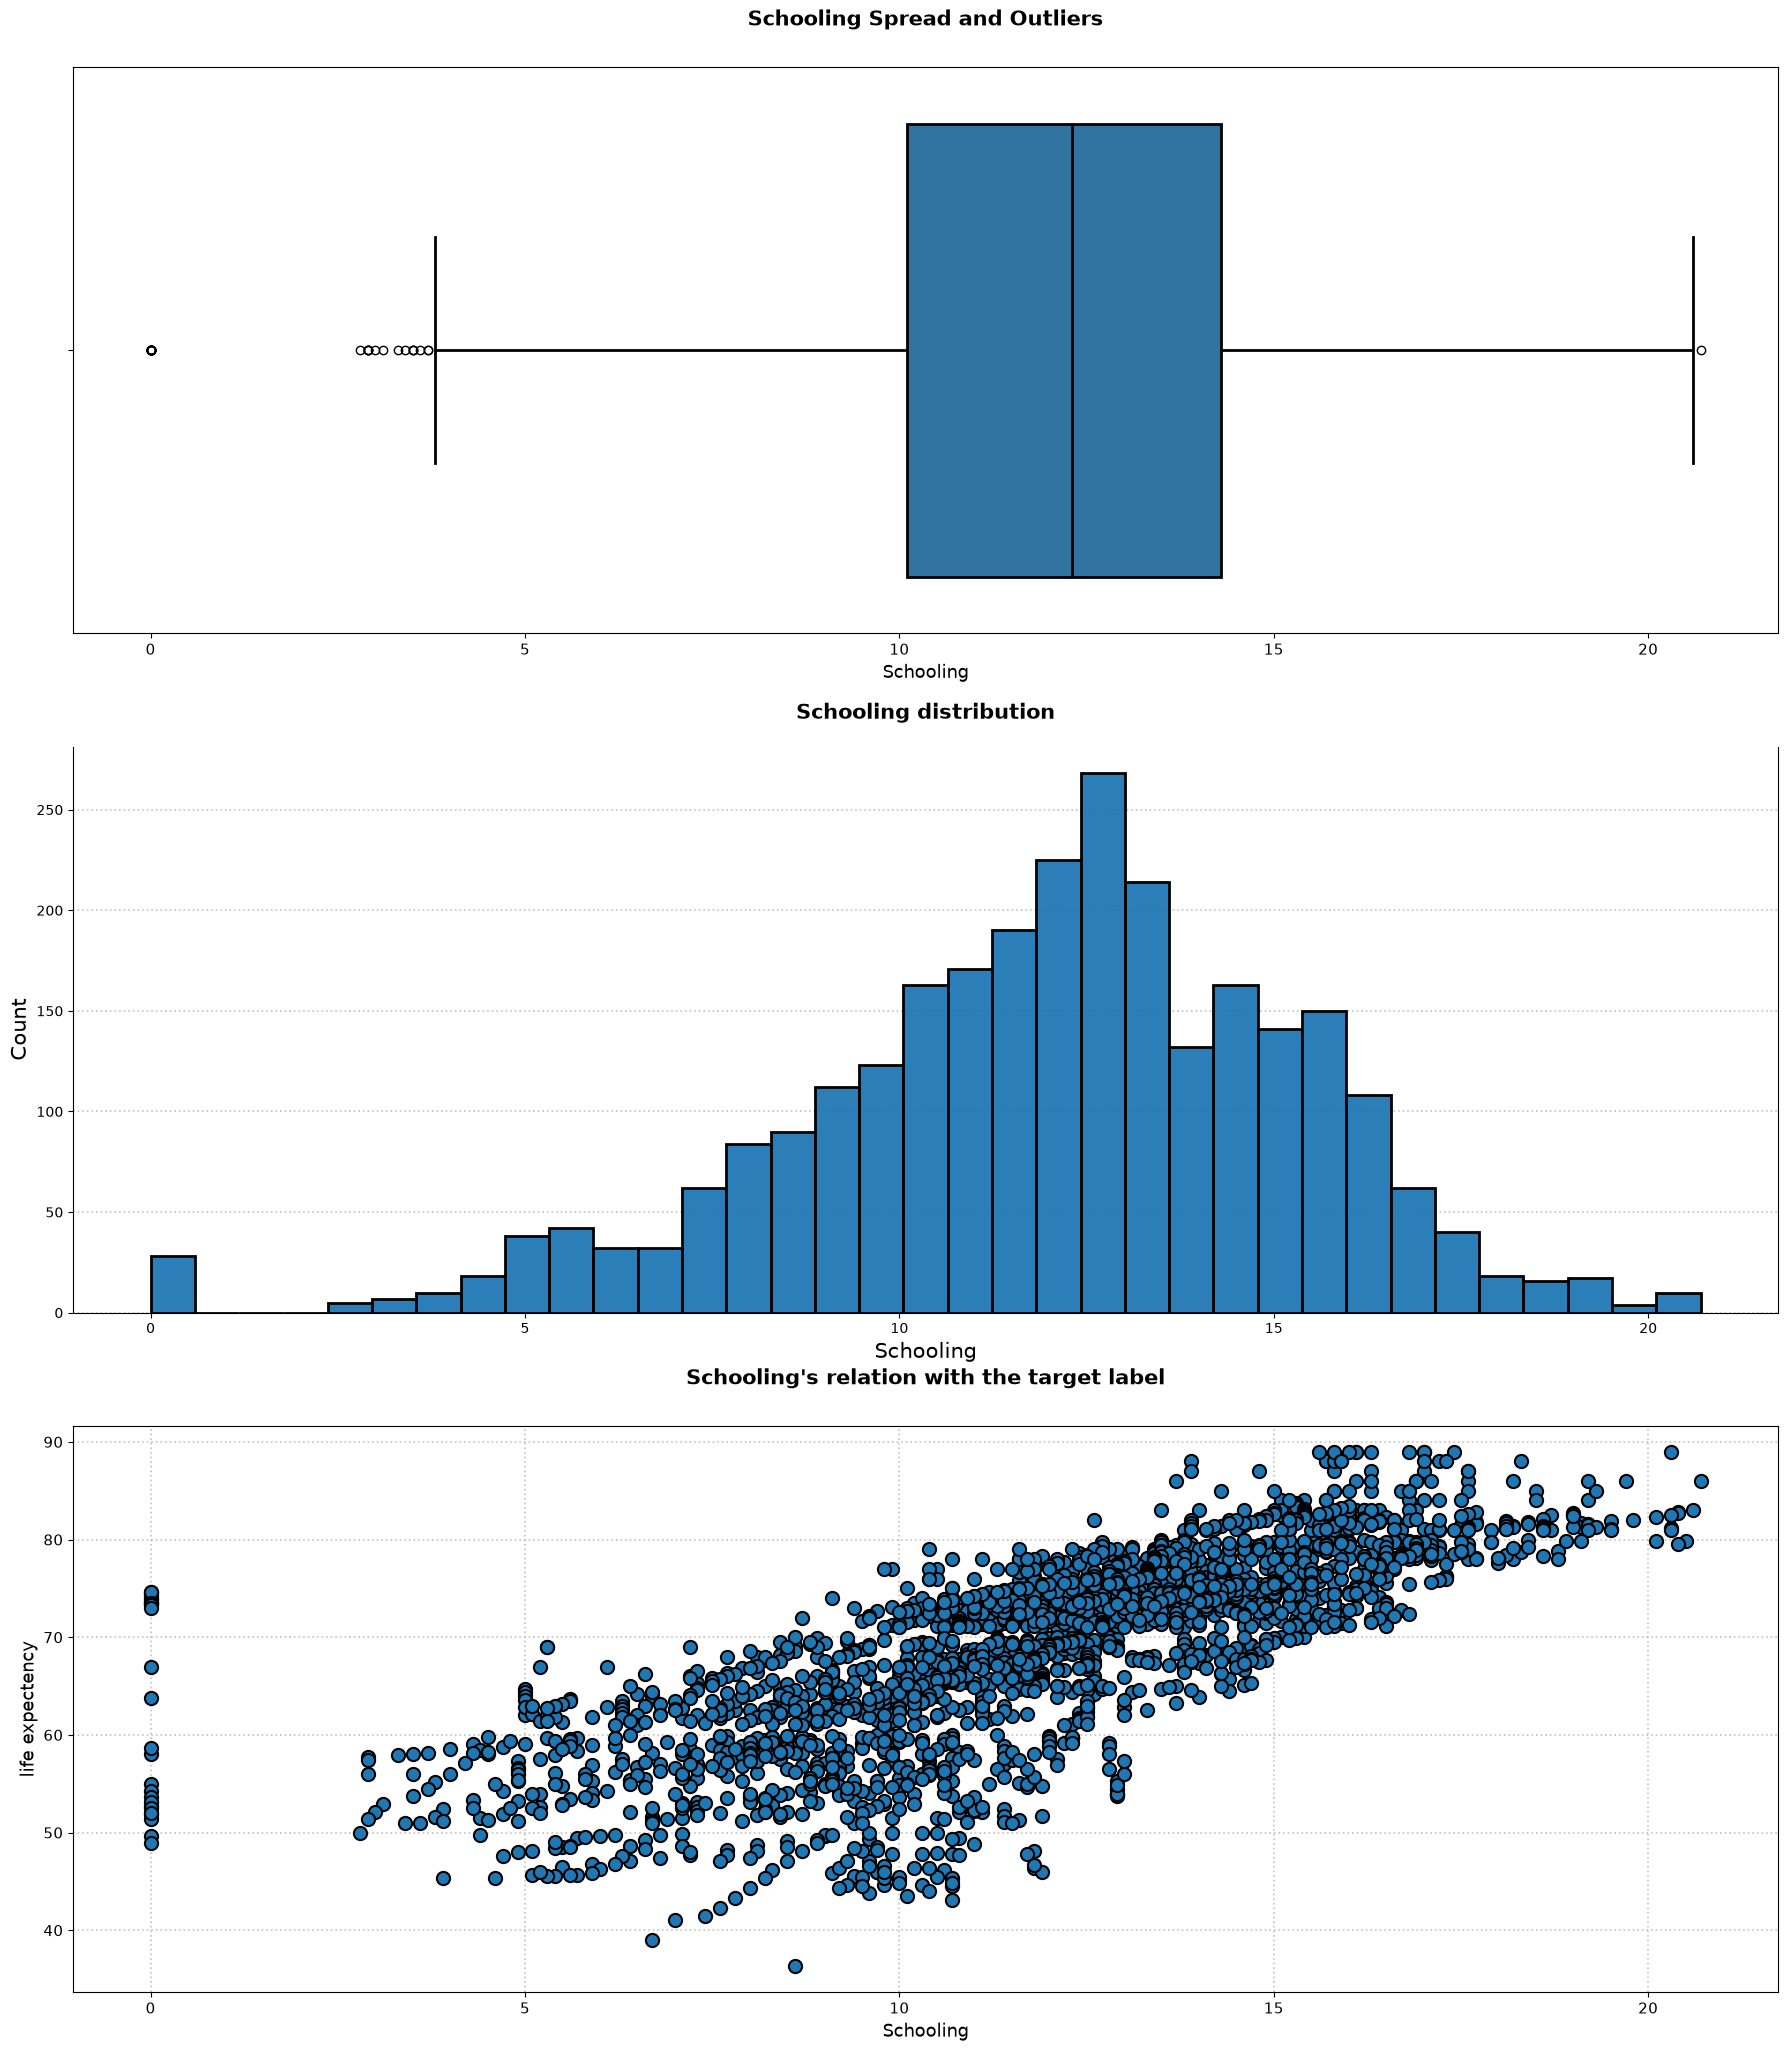


************************************************************************************************************************************



In [63]:
for column in numerical_columns:
    fig = plt.figure(figsize=(22,25))
    ax0 = fig.add_subplot(3,1,1)
    ax1 = fig.add_subplot(3,1,2)
    ax2 = fig.add_subplot(3,1,3)

    sns.boxplot(data=df, x=column,linewidth=2, linecolor='black',ax=ax0)
    ax0.set_title(f"{column} Spread and Outliers", fontsize=15, fontweight='bold', pad=30)
    ax0.tick_params(axis='x', labelsize=11, color='black')
    ax0.set_xlabel(column, fontsize=13)

    sns.histplot(data=df, x=column, linewidth=2, alpha=0.95, ax=ax1)
    ax1.set_title(f'{column} distribution', fontsize=15, fontweight='bold', pad=20)
    ax1.set_xlabel(column, fontsize=15)
    ax1.set_ylabel('Count', fontsize=15)
    ax1.set_axisbelow(True)
    ax1.grid(True, axis='y', linestyle=':', linewidth=1.25, alpha=0.7)
    ax1.spines['top'].set_visible(False)

    sns.scatterplot(data=df, x=column, y='Life expectancy',s=90, linewidth=1.5, edgecolor='black')
    ax2.set_title(f"{column}'s relation with the target label", fontsize=15, fontweight='bold', pad=30)
    ax2.tick_params(axis='both', labelsize=11, color='black')
    ax2.set_xlabel(column, fontsize=13)
    ax2.set_ylabel('life expectency', fontsize=13)
    ax2.set_axisbelow(True)
    ax2.grid(True, axis='both', linestyle=':', linewidth=1.25, alpha=0.7)

    plt.show()

    print('\n************************************************************************************************************************************\n')

    


### Numerical Feature Evaluation

The numerical features show a wide range of distribution shapes and relationships with `Life expectancy`.

Several health-related variables, including `Adult Mortality`, `HIV/AIDS`, and the two thinness measures, show noticeable negative relationships with Life Expectancy. In contrast, `BMI`, `Polio`, `Diphtheria`, `Income composition of resources`, and `Schooling` show positive relationships of varying strength, with `Income composition of resources` and `Schooling` displaying some of the clearest positive patterns.

Other variables, such as `Hepatitis B` and `Total expenditure`, do not show a strong standalone linear relationship from their current scatter plots. Several features also contain substantial skewness and numerous potential outliers, particularly among mortality, expenditure, disease-count, GDP, and population-related variables.

The following features require **further visual investigation** because extreme values compress most observations into a small region and make their behaviour difficult to interpret from the full-range scatter plots:

- `infant deaths`
- `percentage expenditure`
- `Measles`
- `under-five deaths`
- `GDP`
- `Population`

These features will be examined separately using focused x-axis ranges based on their individual distributions. The original observations will remain unchanged; the focused plots will only be used to better understand the dense regions of the data.